In [5]:
#!pip install control

In [37]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
from scipy.special import expit
import torch

from tqdm.notebook import tnrange
from scipy.optimize import basinhopping

In [5]:
from scipy.linalg import sqrtm
from scipy.stats import multivariate_normal
def white_noise(T,Q,dt=0,seed=None):
    """Generate a white noise signal with specified intensity.

    This function generates a (multi-variable) white noise signal of
    specified intensity as either a sampled continous time signal or a
    discrete time signal.  A white noise signal along a 1D array
    of linearly spaced set of times T can be computing using

        V = ct.white_noise(T, Q, dt)

    where Q is a positive definite matrix providing the noise intensity.

    In continuous time, the white noise signal is scaled such that the
    integral of the covariance over a sample period is Q, thus approximating
    a white noise signal.  In discrete time, the white noise signal has
    covariance Q at each point in time (without any scaling based on the
    sample time).

    """
    # Convert input arguments to arrays
    T = np.atleast_1d(T)
    Q = np.atleast_2d(Q)

    # Check the shape of the input arguments
    if len(T.shape) != 1:
        raise ValueError("Time vector T must be 1D")
    if len(Q.shape) != 2 or Q.shape[0] != Q.shape[1]:
        raise ValueError("Covariance matrix Q must be square")

    # Figure out the time increment
    #if dt != 0:
    #    # Discrete time system => white noise is not scaled
    #    dt = 1
    #else:
    #    dt = T[1] - T[0]

    # Make sure data points are equally spaced
    if not np.allclose(np.diff(T), T[1] - T[0]):
        raise ValueError("Time values must be equally spaced.")

    #np.random.seed(seed)
    # Generate independent white noise sources for each input
    #W = np.random.normal(0, 1/np.sqrt(dt), Q.shape[0]*1000).reshape((Q.shape[0],1000))

    # Return a linear combination of the noise sources
    #return sqrtm(Q) @ W[:,:T.size]
    ret =  np.random.default_rng(seed=seed).multivariate_normal(mean=np.zeros((Q.shape[0])), cov=Q, size=T.size)#multivariate_normal(np.zeros((Q.shape[0],)),Q,seed=seed,allow_singular=False).rvs(T.size)
    return ret.T

In [6]:
L = 60
lambda_true=0.01
Q = np.array([lambda_true**2])

In [7]:
def simulate_nonlinear0(U,Q,x0=0,seed=None,dt=1):
    N = len(U)
    T = np.arange(1,N+1,dt)
    def poly(t,x,u,params):
        alpha = params.get('alpha',[1,-0.5])
        degree = len(alpha)
        ut = [alpha[i]*(u**(i+1)) for i in range(degree)]
        return sum(ut)

    pol = ct.NonlinearIOSystem(None,poly,inputs=1, outputs=1, dt=dt)
    sys_tf = ct.tf([0.,0.5],[1,-0.8],dt=dt)
    sys_hem = ct.series(pol,sys_tf)
    
    _,ys_,x = ct.input_output_response(sys_hem,T,U,x0,return_x=True)
    ys = ys_+ white_noise(T, Q,dt,seed=seed).flatten().copy()
    return x[0],ys

def simulate_nonlinear3(U,Q,x0=0,seed=None,dt=1):
    #zt = (u_{t-1}*0.6+u_t*0.8+0.3*y_{t-1})
    #yt = zt*(1-0.2*zt)
    N = len(U)
    T = np.arange(1,N+1,dt)
    def poly(t,x,u,params):
        alpha = params.get('alpha',[1,-0.2])
        degree = len(alpha)
        ut = [alpha[i]*(u**(i+1)) for i in range(degree)]
        return sum(ut)

    def time_delay_system(coef,delay, dt, inputs=1, outputs=1, **kwargs):
        """
        creates a pure time delay discrete-time system.
        time delay is equal to nearest whole number of `dt`s."""
        assert delay >= 0, "delay must be greater than or equal to zero"
        n = int(round(delay/dt))
        ninputs = inputs if isinstance(inputs, (int, float)) else len(inputs)
        assert ninputs == 1, "only one input supported"
        A = np.eye(n, k=-1)
        B = np.eye(n, 1)*coef
        C = np.eye(1, n, k=n-1)
        D = np.zeros((1,1))
        return ct.ss(A, B, C, D, dt, inputs=inputs, outputs=outputs, **kwargs)


    delayer1 = time_delay_system(0.3,dt,dt,inputs='y',outputs='w')
    delayer2 = time_delay_system(1,dt,dt,inputs='y',outputs='yd')
    delayers = ct.parallel([delayer1,delayer2])
    Us = ct.tf([0.8,0.6],[1,0],dt=dt,inputs='u',outputs='v',name='U')
    u_y = ct.summing_junction(inputs=['v','w'],output='d',name='S')
    F7 = ct.NonlinearIOSystem(None,poly, inputs='d', outputs='y', dt=dt,name='F')
    sys_wiener = ct.interconnect([Us,u_y,F7,delayer1,delayer2],inplist='u', outlist='yd',dt=dt)
    _,ys_,x = ct.input_output_response(sys_wiener,T,U,x0,return_x=True)
    ys = ys_+ white_noise(T, Q,dt,seed=seed).flatten().copy()
    return x[0],ys

def simulate_nonlinear5(U,Q,x0=0,seed=None,dt=1):
    #non-linear arx-sigmoid
    N = len(U)
    T = np.arange(1,N+1,dt)
    
    def sigmoid_stauration2(t,x,u,params):
        offset = params.get('Offset',4)
        scale = params.get('Scale',0.2)
        return scale*expit(u-offset)

    def time_delay_system(coef,delay, dt, inputs=1, outputs=1, **kwargs):
        """
        creates a pure time delay discrete-time system.
        time delay is equal to nearest whole number of `dt`s."""
        assert delay >= 0, "delay must be greater than or equal to zero"
        n = int(round(delay/dt))
        ninputs = inputs if isinstance(inputs, (int, float)) else len(inputs)
        assert ninputs == 1, "only one input supported"
        A = np.eye(n, k=-1)
        B = np.eye(n, 1)*coef
        C = np.eye(1, n, k=n-1)
        D = np.zeros((1,1))
        return ct.ss(A, B, C, D, dt, inputs=inputs, outputs=outputs, **kwargs)
    #l=U[0]*0.8+U[1]*0.6-0.3*ys_[1]
    #expit(l-4)*0.2
    Us = ct.tf([0.6,0.8],[1,0.],dt=dt,inputs='u',outputs='v',name='U')
    delayer1 = time_delay_system(-0.3,dt,dt,inputs='y',outputs='w')
    delayer2 = time_delay_system(1,dt,dt,inputs='y',outputs='yd')
    u_y = ct.summing_junction(inputs=['v','w'],output='d',name='S',dt=dt)
    F3 = ct.NonlinearIOSystem(None,sigmoid_stauration2, inputs='d', outputs='y', dt=dt,name='F')
    sys_wiener3 = ct.interconnect([Us,delayer1,delayer2,u_y,F3],inplist='u', outlist='yd',dt=dt)
    _,ys_,x = ct.input_output_response(sys_wiener3,T,U,x0,return_x=True)
    ys = ys_+ white_noise(T, Q,dt,seed=seed).flatten().copy()
    return x[0],ys

def simulate_nonlinear6(U,Q,x0=0,seed=None,dt=1):
    #non-linear arx-sigmoid
    N = len(U)
    T = np.arange(1,N+1,dt)
    _,ys_,x = ct.input_output_response(sys_wiener4,T,U,x0,return_x=True)
    ys = ys_+ white_noise(T, Q,dt,seed=seed).flatten().copy()
    return x[0],ys

def simulate_nonlinear7(U,Q,x0=0,seed=None,dt=1):
    N = len(U)
    T = np.arange(0,1.*dt*(N+2),dt)[:N]

    def vehicle_update(t, x, u, params={}):
        # Set up the system parameters
        m = params.get('m', 1500.)              # vehicle mass, kg
        Cr = params.get('Cr', 0.32)             # resistance coefficient
        F = params.get('F', 2.4)             # frontal area
        rho = params.get('rho', 1.3)            # density of air, kg/m^3

        k = -rho*F*Cr/m/2
    
        return x+dt*u+dt*k*x*abs(x)

    vehicle = ct.NonlinearIOSystem(
        vehicle_update, None, name='vehicle',
        inputs = ('u'), outputs = ('v'), states=('v'),dt=dt)

    _,ys_,x=ct.input_output_response(vehicle,T,U,x0,return_x=True)
    ys = ys_+ white_noise(T, Q,dt,seed=seed).flatten().copy()
    
    return x[0],ys

def simulate_nonlinear9(U,Q,x0=0,seed=None,dt=1):
    N = len(U)
    T = np.arange(1,N+1,dt)
    def sigmoid3(t,x,u,params):
        offset = params.get('Offset',4)
        scale = params.get('Scale',0.3)
        return expit(scale*u-offset)
        #yhat = 0.5y_{t-1}+0.8*sigmoid(0.3u_{t-1}-4)
    sys_tf = ct.tf([0.,0.5],[1,-0.8],dt=dt)
    sys_hem3 = ct.series(ct.NonlinearIOSystem(None,sigmoid3,inputs=1, outputs=1, dt=dt),sys_tf)
    _,ys_,x = ct.input_output_response(sys_hem3,T,U,x0,return_x=True)
    ys = ys_+ white_noise(T, Q,dt).flatten().copy()
    return x[0],ys


def simulate_nonlinear10(U,Q,x0=[0,0],seed=None,dt=1):
    
    A = np.array([[0.8,1],[-0.1,0.5]])
    B = np.array([1,0])
    C = np.array([1,0])
    D = 0
    sys_ss = ct.ss(A,B,C,D,dt)

    def sigmoid4(t,x,u,params):
        offset = params.get('Offset',4)
        scale = params.get('Scale',0.1)
        return expit(scale*u-offset)
        #x_ = Ax+B*sigmoid(0.2u-4)
    sys_hem4 = ct.series(ct.NonlinearIOSystem(None,sigmoid4,inputs=1, outputs=1, dt=dt),sys_ss)
    
    N = len(U)
    T = np.arange(1,N+1,dt)
    _,ys_,x = ct.input_output_response(sys_hem4,T,U,x0,return_x=True)
    ys = ys_ + white_noise(T, Q,dt,seed=seed).flatten().copy()
    return x,ys

def simulate_nonlinear11(U,Q,x0=[1.,0.5],seed=None,dt=1):
    N = len(U)
    T = np.arange(0,1.*dt*(N+2),dt)[:N]

    def volterra_lodka(t, x, u, params={}):
        # Set up the system parameters
        #dx = 0.4x−0.4xy + u
        #dy = −0.1y+0.2xy
        dx1 = (0.4*x[0]-0.4*x[0]*x[1] + u[0])*dt
        dx2 = (-0.1*x[1]+0.2*x[0]*x[1])*dt
        dx = np.hstack([dx1,dx2])
        return np.maximum(x+dx,np.zeros(2))
    
    def observe(t,x,u,params={}):
        return x
    
    vl = ct.NonlinearIOSystem(
        volterra_lodka, outfcn =observe, name='vl',
        inputs = ('u'), outputs = ('y1','y2'), states=('x1','x2'),dt=dt)
    _,ys_,x=ct.input_output_response(vl,T,U,np.array(x0),return_x=True)
  
    ys = ys_+ white_noise(T, Q,dt,seed=seed).copy()
    return x,ys

def simulate_nonlinear12(U,Q,x0=[.01,.01,0.03],seed=None,dt=1):
    N = len(U)
    T = np.arange(0,1.*dt*(N+2),dt)[:N]

    def two_tanks(t, x, u, params={}):
        A1 = 0.1
        A2 = 0.1
        K = 1
        Cv1 = .2
        Cv2 = .2
        q12 = Cv1*np.sqrt(max(0,x[0]))
        x1 = x[0] + (K*u[0] - q12)*dt/A1
        x2 = x[1] + (q12-Cv2*np.sqrt((max(0,x[1]))))*dt/A2
        x3 = q12
        x_ = np.array([x1,x2,x3])
        return np.maximum(x_,np.zeros(3))
    
    def observe(t,x,u,params={}):
        return x
    
    tt = ct.NonlinearIOSystem(
        two_tanks,observe,name='twotanks',
        inputs = ('u'), outputs = ('y1','y2','y3'), states=('x1','x2','x3'),dt=dt)
    _,ys_,x=ct.input_output_response(tt,T,U,np.array(x0),return_x=True)
    eps = white_noise(T, Q,dt,seed=seed).copy()
    ys = ys_+ eps
    return x,ys

def simulate_nonlinear16(U,Q,x0=[.01,.01],seed=None,dt=1):
    N = len(U)
    T = np.arange(0,1.*dt*(N+2),dt)[:N]

    def two_tanks(t, x, u, params={}):
        A1 = 0.1
        A2 = 0.1
        K = 1
        Cv1 = .2
        Cv2 = .15
        q12 = Cv1*np.sqrt(max(0,x[0]))
        x1 = x[0] + (K*u[0] - q12)*dt/A1
        x2 = x[1] + (q12-Cv2*np.sqrt((max(0,x[1]))))*dt/A2
        x_ = np.array([x1,x2])
        return np.maximum(x_,np.zeros(2))
    
    def observe(t,x,u,params={}):
        return x
    
    tt = ct.NonlinearIOSystem(
        two_tanks,observe,name='twotanks',
        inputs = ('u'), outputs = ('y1','y2'), states=('x1','x2'),dt=dt)
    _,ys_,x=ct.input_output_response(tt,T,U,np.array(x0),return_x=True)
    eps = white_noise(T, Q,dt,seed=seed).copy()
    ys = ys_+ eps
    return x,ys

def simulate_nonlinear13(U,Q,x0=[np.pi,0],seed=None,dt=1):
    #dx1 = x2
    #dx2 = theta1*sin(x1)+theta2*u
    #y = x1
    
    #dx1 = d_angle
    #dx2 = -sin(angle)
    #y = x1
    N = len(U)
    T = np.arange(0,1.*dt*(N+2),dt)[:N]

    def pendulum(t, x, u, params={}):
        theta1 = -1.
        theta2 = 0.1
        dx1 = x[1]*dt
        dx2 = (theta1*np.sin(x[0])+theta2*u[0])*dt
        dx = np.array([dx1,dx2])
        return x+dx
    
    def observe(t,x,u,params={}):
        return x[0]
    
    tt = ct.NonlinearIOSystem(
        pendulum,observe,name='pendulum',
        inputs = ('u'), outputs = ('y'), states=('x1','x2'),dt=dt)
    _,ys_,x=ct.input_output_response(tt,T,U,np.array(x0),return_x=True)
    ys = ys_+ white_noise(T, Q,dt,seed=seed).copy()
    return x,ys

def simulate_linear0(U,Q,x0=0,seed=None,dt=1):
    A = 0.8
    B = 0.5
    C = 1
    D = 0
    sys_ss = ct.ss(A,B,C,D,dt,name='S',inputs='u',outputs='y',states='x')

    N = len(U)
    T = np.arange(1,N+1,dt)
    _,ys_,x = ct.input_output_response(sys_ss,T,U,x0,return_x=True)
    ys = ys_ + white_noise(T, Q,dt,seed=seed).flatten().copy()
    return x,ys

def simulate_linear1(U,Q,x0=0,seed=None,dt=1):
    N = len(U)
    T = np.arange(1,N+1,dt)
    _,ys_,x=ct.input_output_response(sys_fir,T,U,0,return_x=True)
    ys = ys_+ white_noise(T, Q,dt,seed=seed).flatten().copy()
    return x,ys

def simulate_linear2(U,Q,x0=0,seed=None,dt=1):
    num = [-2,-3.5,-1.1,-0.5,-1]
    denom = [1,1.76,1.84,1.2,0.46,0.11]
    sys_arx = ct.tf(num,denom,dt=dt,name='ARX')
    N = len(U)
    T = np.arange(1,N+1,dt)
    _,ys_,x=ct.input_output_response(ct.tf2io(sys_arx),T,U,0,return_x=True)
    ys = ys_+ white_noise(T, Q,dt,seed=seed).flatten().copy()
    return x,ys


def simulate_linear3(U,Q,x0=[0,0],seed=None,dt=1):
    
    A = np.array([[0.5,1],[-0.1,0.5]])
    B = np.array([1,0])
    C = np.array([1,0])
    D = 0
    sys_ss = ct.ss(A,B,C,D,dt)

    N = len(U)
    T = np.arange(1,N+1,dt)
    _,ys_,x = ct.input_output_response(sys_ss,T,U,x0,return_x=True)
    ys = ys_ + white_noise(T, Q,dt,seed=seed).flatten().copy()
    return x,ys

In [8]:
def simulate_nonlinear14(U,Q,x0=[0.01],seed=None,dt=1):
    N = len(U)
    T = np.arange(0,1.*dt*(N+2),dt)[:N]

    def vehicle_update(t, x, u, params={}):
        # Set up the system parameters
        m = params.get('m', 1500.)              # vehicle mass, kg
        Cr = params.get('Cr', 0.32)             # resistance coefficient
        F = params.get('F', 2.4)             # frontal area
        rho = params.get('rho', 1.3)            # density of air, kg/m^3

        k = -rho*F*Cr/m/2
    
        return x+dt*np.tanh(u-0.5)+dt*k*(x**2)

    vehicle = ct.NonlinearIOSystem(
        vehicle_update, None, name='vehicle',
        inputs = ('u'), outputs = ('v'), states=('v'),dt=dt)

    _,ys_,x=ct.input_output_response(vehicle,T,U,x0,return_x=True)
    ys = ys_+ white_noise(T, Q,dt,seed=seed).flatten().copy()
    
    return x[0],ys

def simulate_nonlinear15(U,Q,x0=[0,0],seed=None,dt=1):
    N = len(U)
    T = np.arange(0,1.*dt*(N+2),dt)[:N]

    def weird(t, x, u, params={}):
        # Set up the system parameters
        A = np.array([[0.3,0.5]])
        B = np.array([[0.8]])
        x_ = np.zeros(2)
        x_[:1] = A@x + B@u
        x_[1] = 0.1*np.tanh(x[0]-5)
        
        return x_
    def observe(t,x,u,params={}):
        return x[-1]
        
    sys = ct.NonlinearIOSystem(
        weird, observe, name='weird',
        inputs = ('u'), outputs = ('v'),states=('x1','x2'),dt=dt)

    _,ys_,x=ct.input_output_response(sys,T,U,x0,return_x=True)
    ys = ys_+ white_noise(T, Q,dt,seed=seed).flatten().copy()
    
    return x,ys

In [9]:
def repara_power_spectrum(var,c,freq_weights):
    N = len(var)
    dft = torch.fft.fft(var)
    dft_ = dft*c/torch.clamp(torch.real(dft@freq_weights@torch.conj(dft))/N,min=c)
    return torch.real(torch.fft.ifft(dft_))

def repara_frequency(var,c):
    dft = torch.fft.fft(var)

    dft_ = dft*c/torch.clamp(torch.real(dft*torch.conj(dft)),min=c)
    
    return torch.real(torch.fft.ifft(dft_))
     
def repara_ellipsoid(var,invC,q):
    return var*q/torch.clamp(var.T@invC@var,min=q)

def repara_sigmoid(var,lower,upper):
    return torch.sigmoid(var).mul(upper-lower)+lower

In [10]:
from abc import ABC,abstractmethod
import torch
class GModel(ABC):
    
    @abstractmethod
    def predict(self,theta,ys,us,**kparams):
        pass
    
    @abstractmethod
    def estimate_criterion(self,theta,ys,us,**kparams):
        pass
    
    @abstractmethod
    def control_criterion(self,theta,ys,us,**kparams):
        pass
    
    @abstractmethod
    def d_mu(self,theta,ys,us,**kparams):
        pass
    
    
class ScalarGaussianModel(GModel):
    
    def neg_log_likelihood(self,mu,gamma2):
        return (mu@mu.T)/gamma2 + mu.shape[0]*torch.log(gamma2)
    
    def neg_log_likelihood_batch(self,mu,gamma2):
        return (mu/gamma2@mu.T)/mu.shape[0] + torch.log(gamma2).mean()

In [11]:
def step(funs,opt,var,args):
    fun = funs[0]
    
    if len(funs)>1:
        fun_clipping = funs[1]
    
    opt.zero_grad()
    loss = fun(var,*args)
    loss.backward()
    
    if len(funs)>1:
        fun_clipping(var,*args)
    opt.step()
    with torch.no_grad():
        loss_val = loss.item()
    return loss_val

def step_minimax(funs,opt_desc,opt_asc,var_desc,var_asc,args):
    fun = funs[0]
        
    opt_desc.zero_grad()
    opt_asc.zero_grad()
    
    loss = fun(var_desc,var_asc,*args)
    loss.backward()
    
    opt_desc.step()
    opt_asc.step()
    
    with torch.no_grad():
        loss_val = loss.item()
    return loss_val


In [12]:
from torch.optim import AdamW,Adam,SGD
from scipy.stats import chi2

def early_stop(losses,tol=1e-7,minimum_steps = 5000):
    return False
    # if len(losses)>minimum_steps and np.std(losses[-minimum_steps:-1])<tol:
    #     return True
    # return False
    
def minimize(funs,init_val,kparams,n_iter=30000,tol=1e-7,lr=1e-4):
    torch.set_default_tensor_type(torch.DoubleTensor)
    losses = []
    
    #Descending optimizer
    var = torch.tensor(init_val).requires_grad_(True)
    opt = AdamW([var],lr = lr) 
    
    min_loss = step(funs,opt,var,kparams)
    bestvar = var.clone().detach()
    for i in range (n_iter):
        loss_val = step(funs,opt,var,kparams)
        if np.isnan(loss_val)==False and loss_val<min_loss:
            min_loss = loss_val
            bestvar = var.clone().detach()
            
        losses.append(loss_val)
        if np.isnan(loss_val)==True and early_stop(losses):
            break
    
    return bestvar,losses

def minimax(funs,init_val_desc,init_val_asc,kparams,n_iter=30000,tol=1e-7,lr_desc=1e-4,lr_asc=1e-5):
    torch.set_default_tensor_type(torch.DoubleTensor)
    losses = []
    
    #Descending optimizer
    var_desc = torch.tensor(init_val_desc).requires_grad_(True)
    opt_desc = AdamW([var_desc],lr = lr_desc) 
    
    #Ascending optimizer
    var_asc = torch.tensor(init_val_asc).requires_grad_(True)
    opt_asc = AdamW([var_asc],lr = lr_asc) 
    opt_asc.param_groups[0]['lr'] *= -1
    
    for i in range (n_iter):
        loss_val = step_minimax(fun,opt_desc,opt_asc,var_desc,var_asc,kparams)
        losses.append(loss_val)
        if early_stop(losses):
            break
            
    final_var_desc = var_desc.detach()
    return final_var_desc,losses

def q_alpha_d(dim,alpha=0.05):
    return chi2.ppf(1-alpha,dim)

In [13]:
def roll(x,shifts):
    N = x.shape[0]
    if x.shape[0]<=shifts:
        return torch.zeros(N)
    return torch.concat([torch.zeros(shifts),x[:N-shifts]])

# Linear Model

In [14]:
import scipy

def scaled_PRBS(N,scale=1,dt=1,seed=None):
    nbits = int(np.ceil(np.log(N)/np.log(2)))
    np.random.seed(14)
    seq = scipy.signal.max_len_seq(nbits=max(15,nbits),state=np.round(np.random.random(15)))[0]
    subseq = np.zeros(N)
    for i in range(N):
        idx=int(np.round(10*(i*dt)-0.5+1e-4))
        subseq[i] = seq[idx]
    return scale*2*(subseq-0.5)

def scaled_PRBS_RA(seed,N,scale=1,dt=1):
    seq = scaled_PRBS(N,scale,dt,14)
    np.random.seed(seed)
    amp = np.random.random(N)
    return seq*amp

def monte_carlo(U,U_test,model,simulator,repeat,true_theta,_rng,Q=Q,a=5,dt=1,is_linear=False,ignore_noise=True,n_iter_est=20000,lr_est=5e-4):
    
    def genderate_data(U,seed):
        try:
            u = np.array(U(seed+1))
        except:
            try:
                u = np.array(U(seed+1))
            except:
                print("?")
                u = np.array(U(seed+1))
        try:
            _,y = simulator(u,Q,seed=seed,dt=dt)
        except:
            _,y = simulator(u,Q,seed=seed,dt=dt)
        return u,y
    #results are in the form of repeat * len(_rng)
    #prediction error
    pred_errs = []
    
    #crb
    theta_crbs = []
    
    #theta_estimation error
    theta_mses = []
    powerss = []
    uss = []
    yss = []
    dim = len(true_theta)
    
    #u = np.array(U())
    for j in tqdm(range(repeat)):
        u,y = genderate_data(U,j)
        uss.append(u)
        yss.append(y)
        u_test,y_test = genderate_data(U_test,j)
        mses = []
        crbs = []
        thetaerrs = []
        powers = []
        for i in _rng:
            theta_a=None
            
            #Step 0. get previous i samples       
            ysn = torch.tensor(y[:i])
            usn = torch.tensor(u[:i])
            powers.append(np.mean(u[:i]**2)/(a**2))
            
            #Step 1. append CRB w.r.t true theta
            try:
                if i<dim:
                    fim = 1e-8*torch.eye(len(true_theta))+model.fim(torch.tensor(true_theta),ysn,usn)
                else:
                    fim = model.fim(torch.tensor(true_theta),ysn,usn)
                
                if ignore_noise:
                    tr_crb = torch.trace(torch.linalg.inv(fim)[:-1,:-1]).detach().item()
                else:
                    tr_crb = torch.trace(torch.linalg.inv(fim)).detach().item()
                
                
                if np.isnan(tr_crb):
                    crbs.append(1e14)
                else:
                    crbs.append(tr_crb)
            except:
                crbs.append(1e14)
            
            #Step 2. append estimation errors
            if i<dim or (not is_linear):
                np.random.seed(j*len(_rng)+i)
                theta0 = np.random.randn(len(true_theta))
                theta_a,losses = minimize([model.estimate_criterion],theta0,[ysn,usn],lr=lr_est,tol=1e-7,n_iter=n_iter_est)
            else:
                theta_a,_ = analytic_solution(model,ysn,usn)
                
            
            theta_est = theta_a.detach().numpy()
            
            #print(theta_est)
            
            if ignore_noise:
                thetaerr = ((theta_est[:-1]-np.array(true_theta)[:-1])**2).sum()
            else:
                theta_est[-1] = (theta_est[-1]**2)
                thetaerr = ((theta_est-np.array(true_theta))**2).sum()
                
            thetaerrs.append(thetaerr)
            
            #Step 3. append prediction errors
            yhat = model.predict(theta_a,torch.tensor(y_test),torch.tensor(u_test)).numpy()
            mse = ((y_test[1:]-yhat[:-1])**2).mean()
            #print(yhat,ysn,mse)
            mses.append(mse)
            
            
        pred_errs.append(mses)
        theta_crbs.append(crbs)
        theta_mses.append(thetaerrs)
        powerss.append(powers)
        
    return np.array(pred_errs),np.array(theta_crbs),np.array(theta_mses),np.array(powerss),np.array(uss),np.array(yss)

In [15]:
class LinearModel(ScalarGaussianModel):
    def __init__(self,order_a,order_b,u_range,v_norm):
        self.order_a = order_a
        self.order_b = order_b
        self.u_range = u_range
        self.v_norm = v_norm

    def phi(self,ys,us):#TODO, cache phi
        cols = []
        N = len(ys)
        for i in range(self.order_a):
            cols.append(roll(ys,i))
                
        for i in range(self.order_b):
            cols.append(roll(us,i))
           
        return torch.vstack(cols).T
    
    def predict(self,theta,ys,us):
        return self.phi(ys,us)@theta[:-1]
    
    def estimate_criterion(self,theta,ys,us):
        ps = self.predict(theta,ys[:-1],us[:-1])#can be cached
        errs = (ys[1:]-ps)
        gamma2 = theta[-1]**2
        return self.neg_log_likelihood(errs,gamma2)

    def d_mu(self,theta,ys,us):
        return self.phi(ys,us)
    
    def fim(self,theta,ys,us):
        dmu = self.d_mu(theta,ys,us)
        N = dmu.shape[0]
        gamma2 = theta[-1]
        I = torch.eye(len(theta))
        I[:-1,:-1] = (dmu.T@dmu)/gamma2
        I[-1,-1] = N/2/(gamma2**2)
        return I
    
    def recompute_u_range(self,theta,K,ys,us):
        return self.u_range
    
    def hess(self,theta,ys,us):
        return -2*self.fim(theta,ys,us)
    
    def jac(self,theta,ys,us):
        dmu = self.d_mu(theta,ys,us)[:-1,:]
        N = dmu.shape[0]
        J = torch.zeros(theta.shape)
        gamma2 = theta[-1]
        err = (ys[1:]-self.predict(theta,ys[:-1],us[:-1]))
        J[:-1] = -dmu.T@err/gamma2
        J[-1] = N/gamma2-(dmu.T@dmu)*N/(gamma2**2)
        return J
    
    def predict_yk(self,uk,theta,ys,us):
        K = uk.shape[0]
        yk = torch.zeros(K+1)
        for i in range(K+1):
            if i==0:
                if len(us)>0:
                    yk[i] = self.predict(theta,ys,us)[-1]
                else:
                    yk[i] = 0
            else:
                yk[i] = self.predict(theta,torch.concat([ys,yk[:i]]),torch.concat([us,uk[:i]]))[-1]
        return yk
    
    def fim_append(self,uk,theta,ys,us):
        yk = self.predict_yk(uk,theta,ys,us)
        
        #cache yk for output constraint
        self.yk = yk.clone().detach()
        
        return 1e-14*torch.eye(len(theta))+self.fim(theta,torch.concat([ys,yk[:-1]]),torch.concat([us,uk]))

    def control_criterion(self,uk,theta,ys,us,W=None):
        if W is None:
            return torch.logdet(torch.linalg.inv(self.fim_append(uk,theta,ys,us)))
        else:
            return torch.trace(W@torch.linalg.inv(self.fim_append(uk,theta,ys,us)))
    
    def control_step(self,uk,theta_delta,theta0,ys,us,inv_theta_cov=None,W=None):
        #print('u?',theta_delta)
        theta_ = self.repara_theta(theta0,theta_delta,inv_theta_cov)
        uk_ = self.repara_u(uk)
        return self.control_criterion(uk_,theta_,ys,us)
    
    def estimation_step(self,theta,ys,us):
        theta_ = theta.clone()
        if theta.requires_grad:
            theta_[-1] = theta[-1]**2
        return self.estimate_criterion(theta_,ys,us)
    
    def repara_theta(self,theta0,theta_delta,inv_theta_cov):
        if theta_delta.requires_grad:
            theta_ = theta0+repara_ellipsoid(theta_delta,inv_theta_cov,self.v_norm)
        else:
            theta_ = theta0
        return theta_
    
    def repara_u(self,u):
        return repara_sigmoid(u,*self.u_range)
    
    def clip_u_grad(self,uk,theta_delta,theta0,ys,us,inv_theta_cov=None,W=None):
        pass
    
    def initialize_active_uk(self,theta,ys,us,K,uk0=None):
        return 0.03*np.random.randn(K)

 - $\hat{y}_1 = h(x_1)$ 
     * $\frac{d \hat{y}_1}{d x_0} = h'(x)\frac{d x_1}{d x_0}$
     * $\frac{d \hat{y}_1}{d w} = h'(x)\frac{d x_1}{d w} =  h'(x)(\frac{d x_1}{d x_0} \frac{d x_0}{d w} +\frac{\partial x_1}{\partial w}) // \frac{d x_0}{d w} = 0$
     
  - $\hat{y}_{t-1} = h(x_{t-1})$ 
     * $\frac{d \hat{y}_{t-1}}{d x_0} = h'(x)\frac{d x_{t-1}}{d x_0} = h'(x) \frac{d x_{t-1}}{d x_{t-2}}\frac{d x_{t-2}}{d x_0}$
     * $\frac{d \hat{y}_{t-1}}{d w} = h'(x)\frac{d x_{t-1}}{d w} = h'(x)(\frac{d x_{t-1}}{d x_{t-2}}\frac{d x_{t-2}}{d_w} + \frac{d x_{t-1}}{d_w})$
     
  - $\hat{y}_{t} = h(x_{t})$ 
     * $\frac{d \hat{y}_{t}}{d x_0} = h'(x)\frac{d x_{t}}{d x_0} = h'(x) \frac{d x_{t}}{d x_{t-1}}\frac{d x_{t-1}}{d x_0}$
     * $\frac{d \hat{y}_{t}}{d w} = h'(x)\frac{d x_{t}}{d w} = h'(x)(\frac{d x_{t}}{d x_{t-1}}\frac{d x_{t-1}}{d_w} + \frac{d x_t}{d_w})$    

In [16]:
from scipy.optimize import minimize as sciminimize

class StateSpaceLinearModel:
    
    def __init__(self,u_range,gamma2,v_norm):
        self.u_range = u_range
        self.gamma2 = gamma2
        self.invGamma = torch.ones((1,1))/gamma2
        self.invGamma_np = np.ones((1,1))/gamma2
        
        self.v_norm = v_norm
        self.H = torch.tensor([[1.,0.]])
        self.H2 = np.array([[1.,0.]])
        self.H3 = np.array([[0.,0.,1.,0]])
        self.e1 = torch.tensor([[1.],[0]])
        self.A_ = torch.tensor([[0,1.],[-0.1,0.5]]) 
        
        self.e3 = torch.tensor([[0,1.],[0.,0.]])
        
        self.e4 = torch.tensor([[1.],[0]])
        self.e5 = torch.tensor([[0.,1]])
        self.CI = torch.eye(4)
        self.CI2 = np.eye(4)
    
    def transition(self,theta,x,u):
        A = self.A_ + (theta*self.e1)@self.e1.T
        B = self.e3@theta
        return A@x+B@u
    
    def transition_jac(self,theta,x,u):
        M1 = theta.shape[0]
        M2 = x.shape[0]
        F = torch.eye(M1+M2)      
        F[M1:,:M1] = self.dxtheta(theta,x,u)
        F[M1:,M1:] = self.dxx(theta,x,u)
        return F
        
    def transition_np(self,theta,x,u):
        A = self.A_.numpy() + (theta*self.e1.numpy())@self.e1.numpy().T
        B = self.e3.numpy()@theta
        return A@x+B@u
    
    def predict(self,x):
        return self.H@x
    
    def predict_series(self,theta,x0,uk):
        x_ = x0.clone()
        yk = []
        for i in range(uk.shape[1]):
            yk.append(self.predict(x_))
            x_ = self.transition(theta,x_,uk[:,[i]])
        return torch.hstack(yk)
    
    def dxx(self,theta,x,u):
        return self.A_ + (theta*self.e1)@self.e1.T
    
    def dxx_np(self,theta,x,u):
        pass
    
    def dxtheta(self,theta,x,u):
        return (x*self.e1)@self.e1.T+self.e4@u@self.e5
    
    def dxtheta_np(self,theta,x,u):
        pass
    
    def dmu(self,theta,x0,uk,x_=None,dx_theta=None,dx_x0=None):
        N = uk.shape[1]
        M1 = theta.shape[0]
        M2 = x0.shape[0]
        M3 = self.H.shape[0]
        d_mu = torch.zeros((N,M3,M1+M2))
        
        if dx_theta is None:
            dx_theta = torch.zeros((M2,M1))
            
        if dx_x0 is None:
            dx_x0 = torch.eye(M2)
            
        if x_ is None:
            x_ = x0.clone()
            
        for i in range(N):
            d_mu[i,:,:M1] = self.H@dx_theta
            d_mu[i,:,M1:] = self.H@dx_x0
            
            xx = self.dxx(theta,x_,uk[:,[i]])
            xw = self.dxtheta(theta,x_,uk[:,[i]])
            dx_theta = xx@dx_theta + xw
            dx_x0 = xx@dx_x0
            x_ = self.transition(theta,x_,uk[:,[i]])
        return d_mu,x_,dx_theta,dx_x0
    def fim2(self, theta, x0, uk,x_=None,dx_theta=None,dx_x0=None):
        d_mu,x_,dx_theta,dx_x0 = self.dmu(theta, x0, uk,x_,dx_theta,dx_x0)
        
        N,dim_y,M = d_mu.shape
        I = torch.zeros((M,M))
        for i in range(N):
            for j in range(M):
                for k in range(M):
                    I[j,k] += d_mu[i,:,j].T@self.invGamma@d_mu[i,:,k]
        return I,x_,dx_theta,dx_x0
    
    def fim(self, theta, x0, uk,x_=None,dx_theta=None,dx_x0=None):
        N = uk.shape[1]
        M1 = theta.shape[0]
        M2 = x0.shape[0]
        M3 = self.H.shape[0]
        
        if N==0:
            return torch.zeros((M1+M2,M1+M2))
        
        if dx_theta is None:
            dx_theta = torch.zeros((M2,M1))
            
        if dx_x0 is None:
            dx_x0 = torch.eye(M2)
            
        if x_ is None:
            x_ = x0.clone()
    
        I = []
        yk = []
        for i in range(N):
            d_mu = self.H@torch.hstack([dx_theta,dx_x0])
            I.append((d_mu.T@self.invGamma@d_mu).unsqueeze(0))
            
            xx = self.dxx(theta,x_,uk[:,[i]])
            xw = self.dxtheta(theta,x_,uk[:,[i]])
            dx_theta = xx@dx_theta + xw
            dx_x0 = xx@dx_x0
            x_ = self.transition(theta,x_,uk[:,[i]])
            yk.append(self.predict(x_))
            
        return torch.concatenate(I).sum(axis=0),x_,dx_theta,dx_x0,torch.hstack(yk)
    
    def fim_np(self, theta, x0, uk):
        N = uk.shape[1]
        M1 = theta.shape[0]
        M2 = x0.shape[0]
        M3 = self.H2.shape[0]
        
        
        dx_theta = np.zeros((M2,M1))
        dx_x0 = np.eye(M2)
        x_ = x0.copy()
    
        I = np.zeros((M1+M2,M1+M2))
        yk = []
        for i in range(N):
            d_mu = self.H2@np.hstack([dx_theta,dx_x0])
            I+=(d_mu.T@self.invGamma_np@d_mu)
            
            xx = self.dxx_np(theta,x_,uk[:,[i]])
            xw = self.dxtheta_np(theta,x_,uk[:,[i]])
            dx_theta = xx@dx_theta + xw
            dx_x0 = xx@dx_x0
            x_ = self.transition_np(theta,x_,uk[:,[i]])
            yk.append(self.H2@x_)
            
        return I,np.hstack(yk)
    
    def cache(self,theta,x0,us):
        if us is not None and us.shape[1]>0:
            I,x_,dx_theta,dx_x0,_ = self.fim(theta,x0,us)
            self.fim_prev = I.clone().detach()+ torch.eye(theta.shape[0]+x0.shape[0])*1e-8
            self.x_ = x_.clone().detach()
            self.dx_theta = dx_theta.clone().detach()
            self.dx_x0 = dx_x0.clone().detach()
        else:
            self.fim_prev = None
            self.x_ = None
            self.dx_theta = None
            self.dx_x0 = None
        
    def control_criterion(self, uk, theta, x0,fim_prev,C_prev):
        
        #if self.fim_prev is not None:
        #    I = self.fim(theta,x0,uk,self.x_,self.dx_theta,self.dx_x0)[0] 
        #    return -torch.logdet(I + self.fim_prev)
        M = theta.shape[0]
        I_ = self.fim(theta,x0,uk)[0]
        I = C_prev@(I_+fim_prev)
        
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        
        return -torch.logdet(A-B@torch.linalg.inv(D)@C)
    
    def control_criterion_np(self, uk, theta, x0,fim_prev,C_prev):
        I_ = self.fim_np(theta,x0,uk)[0]
        I = I_@C_prev+self.CI2
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        return -np.logdet(A-B@np.linalg.inv(D)@C)
    
    def control_step(self,uk,theta_delta,  theta, x0, fim_prev,C_prev):    
        theta_ = self.repara_theta(theta,theta_delta,fim_prev)
        uk_ = self.repara_u(uk)
        return self.control_criterion(uk_,theta_, x0, fim_prev,C_prev)
    
    def repara_u(self,u):
        return repara_sigmoid(u,*self.u_range)
    
    def repara_theta(self,theta0,theta_delta,inv_theta_cov):
        if theta_delta.requires_grad:
            theta_ = theta0+repara_ellipsoid(theta_delta,inv_theta_cov,self.v_norm)
        else:
            theta_ = theta0
        return theta_
    
    def recompute_u_range(self,theta,x_prev,K):
        return self.u_range
    
    def init_uk(self,theta,x_prev,K):
        return 0.03*np.random.randn(K).reshape((1,K))
    
    def compute_likelihood(self,theta,x_init,ys,us):
        x_ = x_init.clone()
        l = 0
        for i in range(us.shape[1]):
            muy = ys[:,[i]] - self.predict(x_)
            l+=(-0.5)*(muy.T@muy)/gamma2
            x_ = self.transition(theta,x_,us[:,[i]])
        return l
    
    def compute_lipchitz(self,theta,x_init,ys,us):
        def cl(v):
            w = v[:theta.shape[0],:]
            x = v[theta.shape[0]:,:]
            return self.compute_likelihood(w,x,ys,us)
        
        v_ = torch.vstack([theta,x_init])
        jac = torch.autograd.functional.jacobian(cl,v_)
        L = torch.abs(jac.flatten()).max()
        print(2./np.sqrt(L))
        return 2./np.sqrt(L)
    
    def hessian_of_criterion(self,theta,x_init,ys,us):
        def cl(v):
            w = v[:theta.shape[0],:]
            x = v[theta.shape[0]:,:]
            return self.compute_likelihood(w,x,ys,us)
        hess = torch.autograd.functional.hessian(cl,torch.vstack([theta,x_init]))
        return -hess.squeeze(1).squeeze(-1)

In [462]:
def propogate_analys(theta,x_init,f,F,us,C):
    J_ = C.clone()
    x_ = x_init.clone()
    for i in range(us.shape[1]):
        jac_prev = F(theta,x_,us[:,[i]])
        J_ = jac_prev@J_@jac_prev.T
        x_ = f(theta,x_,us[:,[i]])
        
    return torch.vstack([theta,x_]).detach().numpy(),J_.detach().numpy()
        

def generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,Q,T_min,block_size,weight='full',dt=1,seed=None,minmax=False,n_iter = 20000,lr_desc=8e-4):
    #warm-start
    us_ = us.copy()
    _,ys = simulator(us_,Q,seed=seed,dt=dt)
    if len(ys.shape)==1:
        ys = ys.reshape(1,-1)
    us_ = us_.reshape(1,-1)
    N0 = us_.shape[1]
    
    ysn = torch.tensor(np.array(ys))
    usn = torch.tensor(np.array(us_))
    
    theta = theta0.copy()
    M = theta.shape[0]
    x_init = x_init0.copy()
    invC = invC0.copy()
    uk0 = model.init_uk(torch.tensor(theta),torch.tensor(x_init),K)
    theta_delta0 = 0.01*np.random.randn(theta.shape[0]).reshape(theta.shape)
    gamma = gamma0.copy()
    invS = invS0.copy()
    
    t = 1
    for i in tnrange(T-N0):
        N = usn.shape[1]
        #estimate
        if N<=T_min or (N-T_min)%block_size==0:
            x_init,theta,invC,gamma,invS = estimator(x_init,theta,invC,gamma,invS,ys,us_,t)
            #update model gamma
            
            model.invGamma = torch.diag(1/torch.tensor(gamma).flatten())
            model.invGamma_np = np.diag(1/gamma.flatten())
            print(model.invGamma_np.shape)
            print(model.invGamma.shape)
            t+=1
            
        
        theta_torch = torch.tensor(theta)
        x_init_torch = torch.tensor(x_init)
        invC_torch = torch.tensor(invC)
        C_torch = torch.tensor(scipy.linalg.pinv(invC))
        
        if weight=='diag':
            W = torch.diag(torch.diag(C_torch))
        else:
            W = C_torch
            
        if N>T_min and (N-T_min)%block_size>0:
            # i.e. T_min = 4 N = 9 block_size = 2--> x_init == x[:,[4+2+2]]-> us[[4+2+2]:[4+2+2+1]]
            us_remains = usn[:,-((N-T_min)%block_size):]
            #model.cache(theta_torch,x_init_torch,us_remains)
            #print('cache',us_remains,'from',usn)
            
            wx,C_prop = propogate_x(theta,x_init,model.transition_np,us_remains.numpy(),np.linalg.pinv(invC))
            #wx,C_prop = propogate_analys(torch.tensor(theta),torch.tensor(x_init),model.transition,model.transition_jac,us_remains,torch.tensor(np.linalg.pinv(invC)))
            print('propogate N=',N,wx[theta.shape[0]:,:])#,C_prop,xw2[theta.shape[0]:,:],C_prop2)
            theta_torch = torch.tensor(wx[:theta.shape[0],:])
            x_init_torch = torch.tensor(wx[theta.shape[0]:,:])
            invC_torch = torch.linalg.pinv(torch.tensor(C_prop))
            
            
            if weight=='diag':
                W = torch.diag(torch.diag(torch.tensor(C_prop)))
            else:
                W = torch.tensor(C_prop)
                
            model.u_range = model.recompute_u_range(theta_torch,x_init_torch,K)  
        elif N<T_min:
            us_remains = usn
            #model.cache(theta_torch,x_init_torch,usn)
            xw,C_prop = propogate_x(theta,x_init,model.transition_np,us_remains.numpy(),C_torch)
            print('propogate N=',N,xw[theta.shape[0]:,:])
            theta_torch = torch.tensor(xw[:theta.shape[0],:])
            x_init_torch = torch.tensor(xw[theta.shape[0]:,:])#torch.maximum(torch.minimum(torch.tensor(xw[theta.shape[0]:,:]),torch.ones(x_init.shape)*1e3),-torch.ones(x_init.shape)*1e3)
            invC_torch = torch.linalg.pinv(torch.tensor(C_prop))
                           
            if weight=='diag':
                W = torch.diag(torch.diag(torch.tensor(C_prop)))
            else:
                W = torch.tensor(C_prop)
            
            model.u_range = model.recompute_u_range(theta_torch,x_init_torch,K)
        else:
            #model.cache(theta_torch,x_init_torch,None)
            model.u_range = model.recompute_u_range(theta_torch,x_init_torch,K) 
            

        if minmax:
            uk,losses = minimax([model.control_step],uk0,theta_delta0,[theta_torch,x_init_torch,invC_torch,W],lr_desc=1e-3,lr_asc=1e-3,tol=1e-10,n_iter=n_iter)
        else:  
            uk,losses = minimize([model.control_step],uk0,[torch.zeros(0),theta_torch,x_init_torch,invC_torch,W],lr=lr_desc,tol=1e-10,n_iter=n_iter)   
       
                    
                    
        print('control',uk,losses[0],losses[1],losses[-2],losses[-1])
            
        #get first u as control unit, reuse remains as u0
        us_= np.hstack([us_,model.repara_u(uk.detach()).numpy()[:,[0]]])
        usn = torch.tensor(us_)
        uk0[:,:-1] = uk.clone().detach().numpy()[:,1:]
        print('copy uk0',uk0,uk) 
            
        try:
            x_,ys = simulator(us_.flatten(),Q,seed=seed,dt=dt)
        except:
            try:
                x_,ys = simulator(us_.flatten(),Q,seed=seed,dt=dt)
            except:
                print('?',us_.flatten())
        if len(ys.shape)==1:
            ys = ys.reshape(1,-1)
        ysn = torch.tensor(ys)
            
    return us_.flatten()

def generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,Q,block_size,weight='full',dt=1,seed=None,n_iter = 200):
    #warm-start
    us_ = us.copy()
    _,ys = simulator(us_,Q,seed=seed,dt=dt)
    if len(ys.shape)==1:
        ys = ys.reshape(1,-1)
    us_ = us_.reshape(1,-1)
    N0 = us_.shape[1]
    
    
    theta = theta0.copy()
    M = theta.shape[0]
    x_init = x_init0.copy()
    gamma = gamma0.copy()
    invS = invS0.copy()
    invC = invC0.copy()
    uk0 = model.init_uk(torch.tensor(theta),torch.tensor(x_init),K) #TODO 
    bounds = [model.u_range for i in range(K)]
    
    t = 1
    for i in tnrange(T-N0):
        N = us_.shape[1]
        #estimate
        if N%block_size==0:
            x_init,theta,invC,gamma,invS = estimator(x_init,theta,invC,gamma,invS,ys,us_,t)
            model.gamma2 = gamma
            model.invGamma = torch.diag(1./torch.tensor(model.gamma2))
            model.invGamma_np = np.diag(1./model.gamma2.flatten())
            print(model.gamma2,model.invGamma,model.invGamma_np)
            t+=1
            
        
        theta_prop = theta.copy()
        x_init_prop = x_init.copy()
        fim_prop = invC.copy()
        
        if weight=='diag':
            W = np.diag(np.diag(scipy.linalg.pinv(invC)))
        else:
            W = scipy.linalg.pinv(invC).copy()
            
        
        if N%block_size>0:
            us_remains = us_[:,-(N%block_size):]

            wx,C_prop = propogate_x(theta,x_init,model.transition_np,us_remains,np.linalg.pinv(invC))
            fim_prop = scipy.linalg.pinv(C_prop).copy()
            
            if weight=='diag':
                W = np.diag(np.diag(C_prop))
            
            print('propogate N=',N,wx[theta.shape[0]:,:])
            
            theta_prop = wx[:theta.shape[0],:].copy()
            x_init_prop = wx[theta.shape[0]:,:].copy()
   

        def func(uk,theta,x0,fim_prev,W):
            return model.control_criterion_np(uk.reshape(1,-1),theta,x0,fim_prev,W)
        
        print('control loss before',func(uk0,theta_prop,x_init_prop,fim_prop,W))
        minimizer_kwargs = {"method": "L-BFGS-B","bounds":bounds,"args":(theta_prop,x_init_prop,fim_prop,W)}
        ret = basinhopping(func,uk0, minimizer_kwargs=minimizer_kwargs,niter=200)
        uk = ret.x.reshape(1,-1) 
        print('control loss after',uk,func(uk,theta_prop,x_init_prop,fim_prop,W))
            
        #get first u as control unit, reuse remains as u0
        us_= np.hstack([us_,uk[:,[0]]])
        
        uk0[:,:-1] = uk[:,1:]
        print('copy uk0',uk0) 
            
        try:
            x_,ys = simulator(us_.flatten(),Q,seed=seed,dt=dt)
        except:
            try:
                x_,ys = simulator(us_.flatten(),Q,seed=seed,dt=dt)
            except:
                print('?',us_.flatten())
        if len(ys.shape)==1:
            ys = ys.reshape(1,-1)
        
            
    return us_.flatten()



In [ ]:
def monte_carlo_ss(U,U_test,model,estimator,evaluator,simulator,repeat,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rng,Q=Q,a=5,dt=1):
   
    def generate_data(U,seed):
        u = np.array(U(seed))
        
        try:
            x,y = simulator(u,Q,seed=seed,dt=dt)
        except:
            x,y = simulator(u,Q,seed=seed,dt=dt)
        return x,u,y
    #results are in the form of repeat * len(_rng)
    #prediction error
    pred_errs = []
    
    #crb
    theta_crbs = []
    
    #theta_estimation error
    theta_mses = []
    powerss = []
    uss = []
    yss = []
    xss = []
    nss = []
    dim = len(true_theta)
    
    #u = np.array(U())
    for j in tnrange(repeat):
        x,u,y = generate_data(U,j+25)
        if len(y.shape)==1:
            y = y.reshape(1,-1)
        if len(x.shape)==1:
            x = x.reshape(1,-1)
        u = u.reshape(1,-1)
        
        uss.append(u)
        yss.append(y)
        xss.append(x)
        
        x_test,u_test,y_test = generate_data(U_test,j+12)
        
        if len(y_test.shape)==1:
            y_test = y_test.reshape(1,-1)
        if len(x_test.shape)==1:
            x_test = x_test.reshape(1,-1)
        u_test = u_test.reshape(1,-1)
        
        mses = []
        crbs = []
        thetaerrs = []
        stateerrs = []
    
        powers = []
        theta_est = theta0.copy()
        invC_est = invC0.copy()
        C_prev = np.linalg.inv(invC0)
        invS_est = invS0.copy()
        gamma_est = gamma0.copy()
        x_init_est = x_init0.copy()
        ns = []
        t = 1
        for i in tqdm(_rng):
            if i>T_min and (i-T_min)%block_size>0:
                continue
            ns.append(i)
            
            #Step 0. Powers
            powers.append(np.mean(u[:i]**2)/(a**2))
            
            #Step 1. Evaluate
            crb,mse,C_prev = evaluator(x[:,:i],true_theta,C_prev,y[:,:i],u[:,:i],u_test,y_test)
            crbs.append(crb)
            mses.append(mse)
            
            #Step 2. Append estimation errors
            x_init_est,theta_est,invC_est,gamma_est,invS_est = estimator(x_init_est,theta_est,invC_est,gamma_est,invS_est,y[:,:i],u[:,:i],t)
                
            t+=1
            if i<T_min:
                x_ = x[:,[0]]
            elif i==T_min:
                x_ = x[:,[T_min]]
            else:
                x_ = x[:,[i]]
            
            thetaerr = (((theta_est.flatten()-np.array(true_theta).flatten())**2)/(true_theta.flatten()**2)).sum()
            print(((theta_est.flatten()-np.array(true_theta).flatten())**2)/(true_theta.flatten()**2))
            thetaerrs.append(thetaerr)

            
        pred_errs.append(mses)
        theta_crbs.append(crbs)
        theta_mses.append(thetaerrs)
        powerss.append(powers)
        nss.append(ns)
        
    return np.array(pred_errs),np.array(theta_crbs),np.array(theta_mses),np.array(powerss),np.array(uss),np.array(yss),np.array(xss),np.array(nss)

In [19]:
class ReconstraintSSLinearModel(StateSpaceLinearModel):
    def __init__(self,u_range_const,u_range,gamma2,v_norm,y_range):
        self.u_range_const = u_range_const
        self.y_range = y_range
        super().__init__(u_range,gamma2,v_norm)
    
    def dxu(self,theta,x,u):
        return self.e3@theta
    
    def predict_yk_dyk(self,uk,x_prev,theta):
        K = uk.shape[1]
        dyk = torch.zeros((K,K))
        yk = torch.zeros((1,K))
        x_ = x_prev.clone().detach()
        
        B = self.dxu(theta,x_prev,uk[:,[0]]) #linear case dx/du constant
        A = self.dxx(theta,x_prev,uk[:,[0]]) #linear case dx/dx_prev constant
        for i in range(K):
            x_ = self.transition(theta,x_,uk[:,[i]])
            yk[:,[i]] = self.predict(x_)
            for j in range(i,K):
                dyk[i,j] = self.H@(torch.linalg.matrix_power(A,j-i))@B
                
        return yk,dyk
    
    def recompute_u_range(self,theta,x_prev,K):
        '''NO GRADIENT INCLUDE!'''
        uk = self.feasible_uk(theta,x_prev,K)
        
        yk,dyk = self.predict_yk_dyk(uk,x_prev,theta)
        
       
        #minimize u s.t. yk+dyk*(u-uk)<=A      =>    dyk@u<= A-yk+dyk@uk 
        bound0 = solve_linprog(dyk,self.y_range[1]-yk+uk@dyk,self.u_range_const,uk)
        bound1 = solve_linprog(-dyk,-self.y_range[0]+yk-uk@dyk,self.u_range_const,uk)
        
        U_range = np.zeros((K,2))
        U_range[:,0] = np.maximum(bound0[:,0],bound1[:,0])
        U_range[:,1] = np.minimum(bound0[:,1],bound1[:,1])
        for i in range(K):
            if U_range[i,0]>U_range[i,1]:
                U_range[i,0] = self.u_range_const[0]
                U_range[i,1] = self.u_range_const[1]
        print(U_range)
        return torch.tensor(U_range)
    
    def repara_u(self,u):
        return repara_sigmoid(u,self.u_range[:,0],self.u_range[:,1])
    
    def feasible_uk(self,theta,x_prev,K):
        return torch.tensor(self.init_uk(theta,x_prev,K))
    
    
class BarrierSSLinearModel(StateSpaceLinearModel):
    def __init__(self,u_range,gamma2,v_norm,y_range):
        self.y_range = y_range
        super().__init__(u_range,gamma2,v_norm)
        
    def barrier_term(self,yk):
        y_dim,K = yk.shape
        b = 0
        for i in range(y_dim):
            l =1+10*torch.minimum(torch.maximum(torch.zeros((y_dim,K)),torch.tensor(self.y_range[i,0])-yk[i,:]),torch.ones(yk.shape[1])*5)
            u =1+10*torch.minimum(torch.maximum(torch.zeros((y_dim,K)),yk[i,:]-torch.tensor(self.y_range[i,1])),torch.ones(yk.shape[1])*5)
            b+=(torch.exp(l).sum()+torch.exp(u).sum())
        return b
    
    def control_criterion(self, uk, theta, x0,fim_prev):
        #if self.fim_prev is not None:
        #    I_,_,_,_,yk = self.fim(theta,x0,uk,self.x_,self.dx_theta,self.dx_x0)
        #    I = I_ + self.fim_prev
        #else:
        
        I_,_,_,_,yk = self.fim(theta,x0,uk) 
        I = I_ + fim_prev
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        
        return -torch.logdet(A-B@torch.linalg.inv(D)@C)+self.barrier_term(yk)

In [20]:
def nearestPD(A):
    """Find the nearest positive-definite matrix to input

    A Python/Numpy port of John D'Errico's `nearestSPD` MATLAB code [1], which
    credits [2].

    [1] https://www.mathworks.com/matlabcentral/fileexchange/42885-nearestspd

    [2] N.J. Higham, "Computing a nearest symmetric positive semidefinite
    matrix" (1988): https://doi.org/10.1016/0024-3795(88)90223-6
    """
    B = (A + A.T) / 2
    _, s, V = np.linalg.svd(B)

    H = np.dot(V.T, np.dot(np.diag(s), V))

    A2 = (B + H) / 2

    A3 = (A2 + A2.T) / 2

    if isPD(A3):
        return A3

    spacing = np.spacing(np.linalg.norm(A))
    # The above is different from [1]. It appears that MATLAB's `chol` Cholesky
    # decomposition will accept matrixes with exactly 0-eigenvalue, whereas
    # Numpy's will not. So where [1] uses `eps(mineig)` (where `eps` is Matlab
    # for `np.spacing`), we use the above definition. CAVEAT: our `spacing`
    # will be much larger than [1]'s `eps(mineig)`, since `mineig` is usually on
    # the order of 1e-16, and `eps(1e-16)` is on the order of 1e-34, whereas
    # `spacing` will, for Gaussian random matrixes of small dimension, be on
    # othe order of 1e-16. In practice, both ways converge, as the unit test
    # below suggests.
    I = np.eye(A.shape[0])
    k = 1
    while not isPD(A3):
        mineig = np.min(np.real(np.linalg.eigvals(A3)))
        A3 += I * (-mineig * k**2 + spacing)
        k += 1

    return A3

def isPD(B):
    """Returns true when input is positive-definite, via Cholesky"""
    try:
        _ = scipy.linalg.cholesky(B)
        return True
    except np.linalg.LinAlgError:
        return False
    
def get_sigmoid_points(v,Pv,alpha,beta):
    dim = v.shape[0]
    Nx = 2*dim + 1
    kappa = 0#3-Nx#
    
    
    lambd = (alpha**2)*(dim+kappa) - dim
    radius = np.sqrt(dim+lambd)
    wm0 = lambd/(dim+lambd)
    wc0 = lambd/(dim+lambd) + (1-alpha**2+beta)
    wci = 0.5/(dim+lambd)
    
    vset = np.zeros((dim,Nx))
    vset[:,0] = v[:,0]
    if Pv.shape[0]>1:
        rv = radius*scipy.linalg.cholesky(nearestPD(Pv),lower=False) #cholesky?
    else:
        rv = radius*np.sqrt(Pv)
        
    for i in range(1,Nx):
        if (i-1)//dim==0:
            vset[:,i] = v[:,0] + rv[(i-1)%dim,:]
        else:
            vset[:,i] = v[:,0] - rv[(i-1)%dim,:]
            
    return vset,wm0,wc0,wci

def covariance_x_w(x,Px,w,Pw,f,u,alpha=1,beta=2):
    x_set,wmx0,wcx0,wcxi = get_sigmoid_points(x,Px,alpha,beta)#(x_dim,N)
    w_set,wmw0,wcw0,wcwi = get_sigmoid_points(w,Pw,alpha,beta)#(w_dim,M)
    dimx,N = x_set.shape
    dimw,M = w_set.shape
    x_pred_set = np.zeros((dimx,N*M))
    weights = np.zeros((N*M,1))
    for i in range(M):
        for j in range(N):
            x_pred_set[:,[i*N+j]] = f(w_set[:,[i]],x_set[:,[j]],u)
            if j==0:
                weightx = wmx0
            else:
                weightx = wcxi
                
            if i==0:
                weightw = wmw0
            else:
                weightw = wcwi
            
            weights[i*N+j] = weightx*weightw
    
    x_pred_mean = x_pred_set@weights
    
    Px_ = (x_pred_set-x_pred_mean)@np.diag(weights[:,0])@(x_pred_set-x_pred_mean).T
    return Px_



def covariance_x(x,Px,f,us,alpha=0.001,beta=2.5):
    
    x_set,wmx0,wcx0,wcxi = get_sigmoid_points(x,Px,alpha,beta)
    dimx,N = x_set.shape
    x_pred_set = np.zeros((dimx,N))
    weights_m = np.zeros((N,1))
    weights_c = np.zeros((N,1))
    for i in range(N):
        x_pred_set[:,[i]] = f(x_set[:,[i]],us)
        if i==0:
            weights_m[i] = wmx0
            weights_c[i] = wcx0
        else:
            weights_m[i] = wcxi
            weights_c[i] = wcxi
    x_pred_mean = x_pred_set@weights_m
    Px_ = (x_pred_set-x_pred_mean)@np.diag(weights_c[:,0])@(x_pred_set-x_pred_mean).T
    return x_pred_mean,Px_

def mle_x(y,u,f,H,x_prev,w,gamma2,Px_prev,Pw):
    dimx = x0.shape[0]
    C = covariance_x_w(x_prev,Px_prev,w,Pw,f,u)
    
    if C.shape[0]>1:
        invC = np.linalg.inv(C)
    else:
        invC = 1/C
        
    def negllx(var):
        x = var.reshape((dimx,1))
        mux = x-f(w,x_prev,u)
        ll =(y-H@x)**2/gamma2+mux.T@invC@mux
        return ll
    
    res = basinhopping(func = negllx,x0=x_prev.flatten())
    
    x_= res.x.reshape((dimx,1))
    Px_ = np.linalg.inv(H.T@H/gamma2+invC)
    return x_,Px_

def predict_x(x_prev,Px_prev,u,f,w,Pw):
    x_ = f(w,x_prev,u)
    Px_ = covariance_x_w(x_prev,Px_prev,w,Pw,f,u)
    return x_,Px_

In [21]:
def propogate_x(w,x_init,f,us,C):
    dim_w = w.shape[0]
    def pred(wx,u):
        w = wx[:dim_w,:]
        x_ = wx[dim_w:,:]
        x_next = f(w,x_,u)
        if np.isnan(x_next).any():
            return np.vstack([w,x_])
        return np.vstack([w,x_next])
    
    wx = np.vstack([w,x_init])
    for i in range(us.shape[1]):
        wx,C = covariance_x(wx,C,pred,us[:,[i]])
    return wx,C

In [22]:
def complete_mle(model,ys,us,w0,x_init0,Gamma0,lr,n_iter,nonneg_x = False):
    usn = torch.tensor(us)
    ysn = torch.tensor(ys)
    
    if Gamma0.shape[0]==1:
        invGamma2 = torch.tensor(1/Gamma0)
    else:
        invGamma2 = torch.linalg.inv(torch.tensor(Gamma0))
        
    #P(x0,w)P(y1|x0,w)P(y2|x0,w)...P(yt|x0,w)
    def negll(x_init,w):
        if nonneg_x:
            x_ = x_init**2
        else:
            x_ = x_init.clone()
        ll = 0
        
        #Gamma2 = Gamma**2
        #invGamma2 = torch.diag(1/torch.diagonal(Gamma2))
        
        for i in range(us.shape[1]):
            muy = ysn[:,[i]]-model.predict(x_)
            ll = ll + muy.T@invGamma2@muy# + torch.linalg.slogdet(Gamma2)[1]
            x_ = model.transition(w,x_,usn[:,[i]])
        return ll

    w = torch.tensor(w0,requires_grad=True)
    x_init = torch.tensor(x_init0,requires_grad=True)
    #Gamma = torch.tensor(np.sqrt(np.abs(Gamma0)),requires_grad=True)
    optw = AdamW([w,x_init],lr = lr)
    lossesw = []  
    
    min_loss = np.inf
    bestw = w.clone().detach()
    bestx = x_init.clone().detach()
    for i in range(n_iter):
        optw.zero_grad()
        lossw = negll(x_init,w)
        lossw.backward()
        optw.step()
        
        with torch.no_grad():
            if lossw<min_loss:
                min_loss = lossw
                bestw = w.clone().detach()
                bestx = x_init.clone().detach()
                
            lossesw.append(lossw.item())

    if nonneg_x:
        x_init1 =  bestx.detach().numpy()**2
    else:
        x_init1 =  bestx.detach().numpy()
    
    #Gamma1 = (Gamma.detach().numpy())**2
    w1 = bestw.detach().numpy()
    
    def loss(wx):
        w_ = wx[:w0.shape[0],:]
        x_ = wx[w0.shape[0]:,:]
        return -negll(x_,w_)
    
    FIM1 = -torch.autograd.functional.hessian(loss,torch.vstack([bestw,bestx])).squeeze(-1).squeeze(1).detach().numpy()
    #model.fim(w,x_init,usn[:,:])[0].detach().numpy()
    return x_init1,w1,FIM1,lossesw
from torch.optim import NAdam
def conditional_mle(model,ys,us,w0,x_init0,invC0,Gamma0,lr,n_iter,nonneg_x = False):
    block_size = ys.shape[1]
    usn = torch.tensor(us)
    ysn = torch.tensor(ys)
    
    wx_prev = torch.tensor(np.vstack([w0,x_init0]))
    invC = torch.tensor(invC0)
    
    if Gamma0.shape[0]==1:
        invGamma2 = torch.tensor(1/Gamma0)
    else:
        invGamma2 = torch.linalg.inv(torch.tensor(Gamma0))
    
    
    def negll(x_init_,w_):
        if nonneg_x:
            x_ = x_init_**2
        else:
            x_ = x_init_
            
        #prior
        mux = torch.vstack([w_,x_]) - wx_prev
        ll = 0.5*mux.T@invC@mux
        
        for i in range(usn.shape[1]):
            muy = ysn[:,[i]]-model.predict(x_)
            ll += (0.5*muy.T@invGamma2@muy)
            x_ = model.transition(w_,x_,usn[:,[i]])
        return ll
    
    def loss(wx):
        w_ = wx[:w0.shape[0],:]
        x_ = wx[w0.shape[0]:,:]
        
        mux = torch.vstack([w_,x_]) - wx_prev
        ll = 0.5*mux.T@invC@mux
        
        for i in range(usn.shape[1]):
            muy = ysn[:,[i]]-model.predict(x_)
            ll += (0.5*muy.T@invGamma2@muy)
            x_ = model.transition(w_,x_,usn[:,[i]])
            
        return ll
    
    w = torch.tensor(w0,requires_grad=True)
    if nonneg_x:
        x_init = torch.tensor(np.sqrt(np.maximum(np.zeros(x_init0.shape),x_init0)),requires_grad=True)
    else:
        x_init = torch.tensor(x_init0,requires_grad=True)
    optw = AdamW([w,x_init],lr = lr)
    
    lossesw = []  
    min_loss = negll(x_init,w).clone().detach()
    bestw = w.clone().detach()
    bestx = x_init.clone().detach()
    
    
    for i in range(n_iter):
        optw.zero_grad()
        lossw = negll(x_init,w)
        lossw.backward()
        optw.step()
        
        with torch.no_grad():
            if lossw<min_loss:
                min_loss = lossw
                bestw = w.clone().detach()
                bestx = x_init.clone().detach()
                
            lossesw.append(lossw.item())

    if nonneg_x:
        x_init1 =  bestx.detach().numpy()**2
    else:
        x_init1 =  bestx.detach().numpy()
    
    w1 = bestw.detach().numpy()
    
    
    
    FIM1 = torch.autograd.functional.hessian(loss,torch.tensor(np.vstack([w1,x_init1]))).squeeze(-1).squeeze(1).detach().numpy()
    FIM1 = (FIM1+FIM1.T)/2
    
    FIM2 = model.fim(torch.tensor(w1),torch.tensor(x_init1),usn.clone().detach())[0].detach().numpy()+invC0
   
    
    print('F1',FIM1,np.linalg.pinv(FIM1))

    print('F2',FIM2,np.linalg.pinv(FIM2))
        
    return x_init1,w1,FIM2,lossesw

def recursive_mle(model,ys,us,T_min,block_size,w0,x_init0,invC0,Gamma0,lr,n_iter,nonneg_x=False):
    N = ys.shape[1]
    print('N=',N)
    if N<=T_min:
        
        if N<=invC0.shape[0]:
            XW_sigma_set,_,_,_ = get_sigmoid_points(np.vstack([w0,x_init0]),np.linalg.inv(invC0),0.001,2)

            min_loss = 1e20
            for i in range(XW_sigma_set.shape[1]):
                w_sig = XW_sigma_set[:w0.shape[0],[i]]
                x_init_sig = XW_sigma_set[w0.shape[0]:,[i]]
                _,_,_,losses = complete_mle(model,ys,us,w_sig,x_init_sig,Gamma0,lr,n_iter//3,nonneg_x)
                if losses[-1] <min_loss:
                    min_loss = losses[-1]
                    x_init0 = x_init_sig
                    w0 = w_sig

            print('best try',x_init0,w0)
        
        x_init1,w1,invC1,losses = complete_mle(model,ys,us,w0,x_init0,Gamma0,lr,n_iter,nonneg_x)

    
        if N==T_min: #update prior
            print('propogate:',us)
            wx,C1 = propogate_x(w1,x_init1,model.transition_np,us,np.linalg.inv(invC1))
            w1 = wx[:w1.shape[0],:]
            x_init1 = wx[w1.shape[0]:,:]
            invC1 = scipy.linalg.inv(C1)
            
    elif (N-T_min)%block_size==0:
        
        #if (N-T_min)//block_size==1:
        #    XW_sigma_set,_,_,_ = get_sigmoid_points(np.vstack([w0,x_init0]),np.linalg.inv(invC0),1,2)

       #     min_loss = 1e20
       #     for i in range(XW_sigma_set.shape[1]):
       #         w_sig = XW_sigma_set[:w0.shape[0],[i]]
       #         x_init_sig = XW_sigma_set[w0.shape[0]:,[i]]
       #         _,_,_,losses = conditional_mle(model,ys[:,-block_size:],us[:,-block_size:],w0,x_init0,invC0,Gamma0,lr,n_iter//5,nonneg_x)
       #         if min(losses) <min_loss:
       #             min_loss = min(losses)
       #             x_init0 = x_init_sig
       #             w0 = w_sig

       #     print('best try',x_init0,w0)
        
        x_init1,w1,invC1,losses = conditional_mle(model,ys[:,-block_size:],us[:,-block_size:],w0,x_init0,invC0,Gamma0,lr,n_iter,nonneg_x)
         
            
        print('guess',x_init0,'est',x_init1,'y_init',ys[:,[-block_size]])
        print('update',us[:,-block_size:],'from',us)
       
        print('before propogate C',invC1,scipy.linalg.pinv(invC1))
        #wx,C = propogate_analys(torch.tensor(w1),torch.tensor(x_init1),model.transition,model.transition_jac,torch.tensor(us[:,-block_size:]),torch.tensor(scipy.linalg.pinv(invC1)))
        wx,C = propogate_x(w1,x_init1,model.transition_np,us[:,-block_size:],scipy.linalg.pinv(invC1))
        print('after propogate C',C)
        w1 = wx[:w1.shape[0],:]
        x1 = wx[w1.shape[0]:,:]
        x_init1 = x1.copy()
        invC1 = scipy.linalg.pinv(C)
    else:
        return x_init0,w0,invC0
    
    print('loss',losses[0],losses[n_iter//2],losses[-2],losses[-1])
    return x_init1,w1,invC1

def recursive_mle_opt(model,ys,us,block_size,w0,x_init0,invC0,lr,n_iter):
    N = ys.shape[1]
    print('N=',N)
    if N%block_size==0:
        def func(wx,wx_prev,invC_prev,invGamma,ys,us,H,H2,f,dim_theta):
                wx=wx.reshape(-1,1)
                mux = wx-wx_prev
                ll = 0.5*mux.T@invC_prev@mux
                w_ = wx[:dim_theta,:]
                x_ = wx[dim_theta:,:]

                for i in range(us.shape[1]):

                    muy = ys[:,[i]] - H@x_

                    ll+= 0.5*muy.T@invGamma@muy
                    x_ = f(w_,x_,us[:,[i]])
                return ll
            
            
        dim_theta = w0.shape[0]
        wx = np.vstack([w0,x_init0])
        minimizer_kwargs = {"method": "L-BFGS-B","args":(wx.copy(),invC0,model.invGamma_np,ys[:,-block_size:],us[:,-block_size:],model.H2,model.H3,model.transition_np,dim_theta)}
        ret = basinhopping(func, wx.copy(), minimizer_kwargs=minimizer_kwargs,niter=n_iter,stepsize=0.2)
        
        if ret.lowest_optimization_result.success == False and ret.lowest_optimization_result.nit<10:
            print('fail redo',ret.x,ret.fun)
            minimizer_kwargs = {"method": "L-BFGS-B","args":(wx.copy(),invC0,model.invGamma_np,ys[:,-block_size:],us[:,-block_size:],model.H2,model.H3,model.transition_np,dim_theta)}
            ret = basinhopping(func, wx.copy(), minimizer_kwargs=minimizer_kwargs,niter=5*n_iter,T=5,stepsize=0.1)
        
        print(ret)
        wx_ = ret.x
        w1 = wx_[:dim_theta].reshape(-1,1)
        x_init1 = wx_[dim_theta:].reshape(-1,1)
        invC1 = model.fim(torch.tensor(w1),torch.tensor(x_init1),torch.tensor(us[:,-block_size:]))[0].detach().numpy()+invC0
        print('guess',x_init0,'est',x_init1,'y_init',ys[:,[-block_size]])
    
        print('before propogate C',invC1,scipy.linalg.pinv(invC1))
        #wx,C = propogate_analys(torch.tensor(w1),torch.tensor(x_init1),model.transition,model.transition_jac,torch.tensor(us[:,-block_size:]),torch.tensor(scipy.linalg.pinv(invC1)))
        wx,C = propogate_x(w1,x_init1,model.transition_np,us[:,-block_size:],scipy.linalg.pinv(invC1))
        print('after propogate C',C)
        w1 = wx[:w1.shape[0],:]
        x1 = wx[w1.shape[0]:,:]
        x_init1 = x1.copy()
        invC1 = scipy.linalg.pinv(C)
    else:
        return x_init0,w0,invC0
    
    return x_init1,w1,invC1


def recursive_mle_sigma(model,ys,us,block_size,w0,x_init0,invC0,gamma0,invS0,n_iter):
    #Gamma suppose to be a vector
    
    N = ys.shape[1]
    if N%block_size==0:
        zs = np.zeros((ys.shape[0],block_size))
        x_ = x_init0
        for i in range(block_size):
            zs[:,[i]] = ys[:,[-block_size+i]] - model.H2@x_
            x_ = model.transition_np(w0,x_,us[:,[-block_size+i]])
        
        
        def func(gamma,gamma_prev,invS_prev,zs):
                gamma2 = (gamma**2)
                mu_sig = (gamma2.reshape(-1,1)-gamma_prev)
                ll = 0.5*mu_sig.T@invS_prev@mu_sig + 0.5*block_size*np.sum(np.log(gamma2))
                
                invGamma = np.diag(1/gamma2)
         
                for i in range(zs.shape[1]):
                    ll+= 0.5*zs[:,[i]].T@invGamma@zs[:,[i]]
                    
                return ll
            
        minimizer_kwargs = {"method": "L-BFGS-B","args":(gamma0,invS0,zs)}
        ret = basinhopping(func, gamma0.flatten(), minimizer_kwargs=minimizer_kwargs,niter=n_iter)
        
        if ret.lowest_optimization_result.success == False and ret.lowest_optimization_result.nit<10:
            print('fail redo')
            minimizer_kwargs = {"method": "L-BFGS-B","args":(gamma0,invS0,zs)}
            ret = basinhopping(func, gamma0, minimizer_kwargs=minimizer_kwargs,niter=2*n_iter,stepsize=0.3)
        
       
        
        gamma1 = (ret.x**2).reshape(-1,1)
        invS1 = invS0 + 0.5*block_size*np.diag(1/(gamma1**2))
    else:
        return gamma0,invS0
    
    return gamma1,invS1   

    
#Ljung&Soderstrom 1983 ch3.7,p127
def recursive_update(model,ys,us,w0,x_init0,R0,Gamma0,gain0):
    ysn = torch.tensor(ys)
    usn = torch.tensor(us)
    N = ysn.shape[1]
    w = torch.tensor(w0)
    x_init = torch.tensor(x_init0)
    Gamma = torch.tensor(Gamma0)
    R = torch.tensor(R0)
    
    yhat = model.predict_series(w,x_init,usn)[:,[-1]]
    grad = model.dmu(w,x_init,usn[:,:-1])[0][-1,:,:]
    err = ysn[:,[-1]]-yhat
    L = model.compute_lipchitz(w,x_init,ysn,usn)
    gain = 0.999*gain0+1-gain0#could change
    gain = N*gain/(N+100)
    Gamma1 = Gamma + gain*(err@err.T-Gamma)
    invGamma1 = torch.diag(1/torch.diagonal(Gamma1))

    R1 = R+gain*(grad.T@invGamma1@grad-R)
    wx0 = torch.vstack([w,x_init])
    wx1 = wx0 + gain*(torch.linalg.inv(R1)@grad.T@invGamma1@err)
    
    #if check_eig(wx1,wx0)==False:
    #    wx1 = wx0
        
    w1 = wx1[:w.shape[0],:].detach().numpy()
    x_init1 = wx1[w.shape[0]:,:].detach().numpy()
    R1 = R1.detach().numpy()
    Gamma1 = Gamma1.detach().numpy()
    return x_init1,w1,Gamma1,R1,gain
    
def recursive_estimate(model,ys,us,t_threshold,w0,x_init0,x0,R0,Gamma0,gain,lr,n_iter,nonneg_x=False):
    
    if ys.shape[1]<=t_threshold:
        x_init1,w1,Gamma1,R1,lossesw = complete_mle(model,ys,us,w0,x_init0,Gamma0,lr,n_iter,nonneg_x)
        print(lossesw[0],lossesw[n_iter//2],lossesw[-2],lossesw[-1])
    else:#just update
        #x1,w1,Gamma1,R1,lossesw = partial_mle(model,ys,us,w0,x0,Gamma0,R0,lr,n_iter,nonneg_x)
        #x_init1 = x_init0# TODO.
        
        x_init1,w1,Gamma1,R1,gain = recursive_update(model,ys,us,w0,x_init0,R0,Gamma0,gain)
    return x_init1,x0,w1,Gamma1,R1,gain

    

In [23]:
def evaluatorS100(xs,theta,C_prev,ys,us,u_test,y_test):
    amplitude = 1
    v_norm = q_alpha_d(4)
    model = StateSpaceLinearModel([-amplitude,amplitude],lambda_true**2,v_norm) 
    T_min = 0
    block_size = 5
    N = xs.shape[1]
    
    print('true x',xs,'true u',us,'theta',theta)
    
    
    if N<=T_min:#full mle
        C = np.linalg.inv(model.fim(torch.tensor(theta),torch.tensor(xs[:,[0]]),torch.tensor(us))[0].numpy()+np.eye(C_prev.shape[0])*1e-3)
        print(C)
        x_prop,C_prev = propogate_x(theta,xs[:,[0]],model.transition_np,us,C)
    else:
        C = scipy.linalg.pinv(model.fim(torch.tensor(theta),torch.tensor(xs[:,[-block_size]]),torch.tensor(us[:,-block_size:]))[0].numpy()+scipy.linalg.pinv(C_prev))
        
        #x_prop,C_prev2 = propogate_x(theta,xs[:,[-block_size]],model.transition_np,us[:,-block_size:],C)
        J_ = torch.tensor(C)
        x_ = torch.tensor(xs[:,[-block_size]])
        for i in range(block_size):
            j = -block_size+i
            u_curr = torch.tensor(us[:,[j]])
            wx_ = torch.vstack([torch.tensor(theta),x_])     
            jac_prev = torch.autograd.functional.jacobian(lambda wx_prev:torch.vstack([wx_prev[:theta.shape[0]],model.transition(wx_prev[:theta.shape[0]],wx_prev[theta.shape[0]:],u_curr)]),wx_).squeeze(1).squeeze(-1)
            J_ = jac_prev@J_@jac_prev.T
            x_ = model.transition(torch.tensor(theta),x_,u_curr).clone().detach()
        C_prev =J_.detach().numpy()
        
   
    #print('C_prev',C_prev,C_prev2)
    print('supposed C',C)
    
    #I = scipy.linalg.pinv(C)
    M = theta.shape[0]
    #Ia = I[:M,:M]
    #Ib = I[:M,M:]
    #Ic = I[M:,:M]
    #Id = I[M:,M:]
    C_theta = C[:M,:M]#np.linalg.inv(Ia-Ib@scipy.linalg.pinv(Id)@Ic)  #
    tr_crb = np.abs(np.trace(C_theta))
    
    
                     
    mse = 0
    x_ = xs[:,[0]]
    Hn = model.H.numpy()
    for i in range(u_test.shape[0]):
        mse += ((y_test[i]-Hn@x_)**2)
        x_ = model.transition_np(theta,x_,u_test[i].reshape(1,-1))
                
    mse/= u_test.shape[0]
    return tr_crb,mse,C_prev      
   


def estimatorS100(x_init0,theta0,invC0,gamma0,invS0,ys,us,t):
    print(us)
    amplitude = 1
    v_norm = q_alpha_d(4)
    model = StateSpaceLinearModel([-amplitude,amplitude],gamma0,v_norm) 
    
    T_min = 0
    block_size = 5
    
    N = ys.shape[1]
    
    if t==1:
        lr = 1e-2
        n_iter = 80000
    elif t==2:
        lr = 1e-2
        n_iter = 50000
    else:
        lr = np.sqrt(np.diag(np.linalg.inv(invC0)).max())#*model.compute_lipchitz(torch.tensor(theta0),torch.tensor(x_init0),torch.tensor(ys),torch.tensor(us))
        print(lr)
        n_iter = 10000
    
    Gamma = np.eye(1)*gamma0
    print('Gamma0',Gamma)
    x_init,theta,invC = recursive_mle_opt(model,ys,us,block_size,theta0,x_init0,invC0,0.1,600)
    print('x_init',x_init,'theta',theta,'C',np.linalg.inv(invC))
    gamma1,invS1 = recursive_mle_sigma(model,ys,us,block_size,theta,x_init,invC,gamma0,invS0,n_iter=100)
    print('gamma',gamma1,'invS1',invS1)
    return x_init,theta,invC,gamma1,invS1

In [24]:
torch.set_grad_enabled(True)
torch.set_default_dtype(torch.double)

In [25]:
T = 50
amplitude = 1
simulator = simulate_linear3
v_norm = q_alpha_d(4)
model = StateSpaceLinearModel([-amplitude,amplitude],lambda_true**2,v_norm)  
evaluator = evaluatorS100
estimator = estimatorS100
repeat = 1
dt = 1
true_theta = np.array([[0.5],[1.]])
theta0 = np.ones((2,1))*1e1
invC0 = np.eye(4)*1e-18
invS0 = np.eye(1)*1e-18
gamma0 = np.ones((1,1))*0.01
x_init0 = np.ones((2,1))
T_min = 0
block_size = 5
_rngS100 = list(range(block_size,T,block_size))

US100_T = lambda seed:np.roll(scaled_PRBS_RA(seed,T,scale=amplitude),T//3)
US102 = lambda seed:np.roll(scaled_PRBS_RA(seed,T,scale=amplitude),T//3)
US101 = lambda seed:np.roll(scaled_PRBS(T,scale=amplitude),T//3)
def US100(seed):
    K = 5
    v_norm = q_alpha_d(4)
    theta0 = np.ones((2,1))*1e1
    invC0 = np.eye(4)*1e-18
    x0 = np.ones((2,1))*1e2
    x_init0 = np.ones((2,1))*1e2
    model = StateSpaceLinearModel([-amplitude,amplitude],gamma0,v_norm)    
    simulator = simulate_linear3
    estimator = estimatorS100
    dt = 1
    us = US101(seed)[:block_size]#warm-start
    return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,Q,block_size,dt=dt,seed=seed,n_iter=200)


def US103(seed):
    K = 5
    v_norm = q_alpha_d(4)
    theta0 = np.ones((2,1))*1e2
    invC0 = np.eye(4)*1e-18
    x0 = np.ones((2,1))*1e2
    x_init0 = np.ones((2,1))*1e2
    u_bound = torch.vstack([-torch.ones(K)*amplitude,torch.ones(K)*amplitude]).T
    model = ReconstraintSSLinearModel([-amplitude,amplitude],u_bound,gamma0,v_norm,[-1.,1.])    
    simulator = simulate_linear3
    estimator = estimatorS100
    dt = 1
    us = US101(seed)[:block_size]#warm-start
    return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,Q,block_size,dt=dt,seed=seed,n_iter=200)

def US104(seed):
    K = 5
    v_norm = q_alpha_d(4)
    theta0 = np.ones((2,1))*1e2
    invC0 = np.eye(4)*1e-18
    x0 = np.ones((2,1))*1e2
    x_init0 = np.ones((2,1))*1e2
    model = BarrierSSLinearModel([-amplitude,amplitude],gamma0,v_norm,np.array([[-1.,1.]]))    
    simulator = simulate_linear3
    estimator = estimatorS100
    dt = 1
    us = US101(seed)[:block_size]#warm-start
    return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,Q,block_size,dt=dt,seed=seed,n_iter=200)


In [ ]:
presd101,theta_crbs101,theta_msesS101,powerS101,usS101,ysS101,xsS101,nsS101 = monte_carlo_ss(US101,US100_T,model,estimator,evaluator,simulator,repeat,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS100,Q=Q,a=amplitude,dt=dt)

In [ ]:
presdS100,theta_crbsS100,theta_msesS100,powerS100,usS100,ysS100,xsS101,nsS100 = monte_carlo_ss(US100,US100_T,model,estimator,evaluator,simulator,repeat,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS100,Q=Q,a=amplitude,dt=dt)

In [ ]:
presdS103,theta_crbsS103,theta_msesS103,powerS103,usS103,ysS103,nsS103 = monte_carlo_ss(US103,US100_T,model,estimator,evaluator,simulator,repeat,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS100,Q=Q,a=amplitude,dt=dt)

In [ ]:
presdS104,theta_crbsS104,theta_msesS104,powerS104,usS104,ysS104,nsS104 = monte_carlo_ss(US104,US100_T,model,estimator,evaluator,simulator,repeat,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS100,Q=Q,a=amplitude,dt=dt)

In [79]:
class StateSpaceCruiseControlModel(StateSpaceLinearModel):
    #state x velocity
    def __init__(self,u_range,gamma2,v_norm,dt):
        self.u_range = u_range
        self.gamma2 = gamma2
        self.invGamma = torch.ones((1,1))/gamma2
        self.invGamma_np = np.ones((1,1))/gamma2
        
        self.v_norm = v_norm
        self.dt = dt 
        self.H = torch.tensor([[1.]])
        self.H2 = np.array([[1.]])
        self.H3 = np.array([[0.,0.,1.]])
        self.CI = torch.eye(3)
        self.CI2 = np.eye(3)
        
    # x_{t+1} = x_{t} + u*dt + kx_{t}^2*dt
    def transition(self,theta,x,u):
        return x + theta[0,0]*u*self.dt+theta[1,0]*x*torch.abs(x)*self.dt
    
    def transition_np(self,theta,x,u):
        return x + theta[0,0]*u*self.dt+theta[1,0]*x*np.abs(x)*self.dt
    
    def dxx(self,theta,x,u):
         #x*sign(x) + |x|
        return 1 + self.dt*theta[1,0]*(x+torch.sign(x)+torch.abs(x))
    
    def dxx_np(self,theta,x,u):
         #x*sign(x) + |x|
        return 1 + self.dt*theta[1,0]*(x+np.sign(x)+np.abs(x))
    
    def dxtheta(self,theta,x,u):
        xw1 = u*self.dt
        xw2 = x*torch.abs(x)*self.dt
        return torch.hstack([xw1,xw2])
    
    def dxtheta_np(self,theta,x,u):
        xw1 = u*self.dt
        xw2 = x*np.abs(x)*self.dt
        return np.hstack([xw1,xw2])
    
    def control_criterion(self, uk, theta, x0,fim_prev,C_prev):
        #if self.fim_prev is not None:
        #    I_,_,_,_,yk = self.fim(theta,x0,uk,self.x_,self.dx_theta,self.dx_x0)
        #    I = I_ + self.fim_prev
        #else:
        I_,_,_,_,yk = self.fim(theta,x0,uk)
        I = I_@C_prev+self.CI
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        I2 =  (A-B@torch.linalg.inv(D)@C)
        return torch.trace(torch.linalg.inv(I2))
    
    def control_criterion_np(self, uk, theta, x0,fim_prev,C_prev):
        I_ = self.fim_np(theta,x0,uk)[0]
        I = I_@C_prev+self.CI2
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        I2 =  (A-B@np.linalg.pinv(D)@C)
        return np.trace(np.linalg.pinv(I2))
    
class StateSpaceCruiseControlModel2(StateSpaceCruiseControlModel):
    def control_criterion_np(self, uk, theta, x0,fim_prev,C_prev):
        I_ = self.fim_np(theta,x0,uk)[0]
        M = theta.shape[0]
        I =  I_ + fim_prev
        J_inv = np.linalg.inv(I)[:M,:M]
        return np.trace(fim_prev[:M,:M]@J_inv)
    
    def control_criterion(self, uk, theta, x0,fim_prev,C_prev):
        I_ = self.fim(theta,x0,uk)[0]
        M = theta.shape[0]
        I =  I_ + fim_prev
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        J_inv = torch.linalg.inv((A-B@torch.linalg.inv(D)@C))
        return torch.trace(fim_prev[:M,:M]@J_inv)

class BarrierSSCruiseControlModel(StateSpaceCruiseControlModel):
    def __init__(self,u_range,gamma2,v_norm,dt,y_range):
        self.y_range = y_range
        self.yfac = 5
        super().__init__(u_range,gamma2,v_norm,dt)
        
    def barrier_term(self,yk):
        y_dim,K = yk.shape
        b = 0
        for i in range(y_dim):
            l =self.yfac*torch.maximum(torch.zeros((y_dim,K)),torch.tensor(self.y_range[i,0])-yk[i,:])
            u =self.yfac*torch.maximum(torch.zeros((y_dim,K)),yk[i,:]-torch.tensor(self.y_range[i,1]))
            b+=(torch.exp((l+u)**2).sum())
        return b
    def barrier_term_np(self,yk):
        y_dim,K = yk.shape
        b = 0
        for i in range(y_dim):
            l = self.yfac*np.maximum(np.zeros((y_dim,K)),self.y_range[i,0]-yk[i,:])
            u = self.yfac*np.maximum(np.zeros((y_dim,K)),yk[i,:]-self.y_range[i,1])
            b+=(np.exp((l+u)**2).sum())
        return b
    
    def control_criterion(self, uk, theta, x0,fim_prev,C_prev):
        #if self.fim_prev is not None:
        #    I_,_,_,_,yk = self.fim(theta,x0,uk,self.x_,self.dx_theta,self.dx_x0)
        #    I = I_ + self.fim_prev
        #else:
        I_,_,_,_,yk = self.fim(theta,x0,uk)
        I = I_@C_prev+self.CI
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        I2 =  (A-B@torch.linalg.inv(D)@C)
        return torch.trace(torch.linalg.inv(I2)) + self.barrier_term(yk)
    
    def control_criterion_np(self, uk, theta, x0,fim_prev,C_prev):
        #if self.fim_prev is not None:
        #    I_,_,_,_,yk = self.fim(theta,x0,uk,self.x_,self.dx_theta,self.dx_x0)
        #    I = I_ + self.fim_prev
        #else:
        I_,yk = self.fim_np(theta,x0,uk)
        I = I_@C_prev+self.CI2
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        I2 =  (A-B@np.linalg.inv(D)@C)
        return np.trace(np.linalg.inv(I2)) + self.barrier_term_np(yk)
    
class BarrierSSCruiseControlModel2(StateSpaceCruiseControlModel):
    def __init__(self,u_range,gamma2,v_norm,dt,y_range):
        self.y_range = y_range
        self.yfac = 5
        super().__init__(u_range,gamma2,v_norm,dt)
        
    def barrier_term(self,yk):
        y_dim,K = yk.shape
        b = 0
        for i in range(y_dim):
            l =self.yfac*torch.maximum(torch.zeros((y_dim,K)),torch.tensor(self.y_range[i,0])-yk[i,:])
            u =self.yfac*torch.maximum(torch.zeros((y_dim,K)),yk[i,:]-torch.tensor(self.y_range[i,1]))
            b+=(torch.exp((l+u)**2).sum())
        return b
    def barrier_term_np(self,yk):
        y_dim,K = yk.shape
        b = 0
        for i in range(y_dim):
            l = self.yfac*np.maximum(np.zeros((y_dim,K)),self.y_range[i,0]-yk[i,:])
            u = self.yfac*np.maximum(np.zeros((y_dim,K)),yk[i,:]-self.y_range[i,1])
            b+=(np.exp((l+u)**2).sum())
        return b
    
    def control_criterion(self, uk, theta, x0,fim_prev,C_prev):
        #if self.fim_prev is not None:
        #    I_,_,_,_,yk = self.fim(theta,x0,uk,self.x_,self.dx_theta,self.dx_x0)
        #    I = I_ + self.fim_prev
        #else:
        I_,_,_,_,yk = self.fim(theta,x0,uk)
        I =  I_ + fim_prev
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        J_inv = torch.linalg.inv((A-B@torch.linalg.inv(D)@C))
        return torch.trace(fim_prev[:M,:M]@J_inv) + self.barrier_term(yk)
    
    def control_criterion_np(self, uk, theta, x0,fim_prev,C_prev):
        #if self.fim_prev is not None:
        #    I_,_,_,_,yk = self.fim(theta,x0,uk,self.x_,self.dx_theta,self.dx_x0)
        #    I = I_ + self.fim_prev
        #else:
        I_,yk = self.fim_np(theta,x0,uk)
        I =  I_ + fim_prev
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        J_inv = np.linalg.inv((A-B@np.linalg.inv(D)@C))
        return np.trace(fim_prev[:M,:M]@J_inv) + self.barrier_term_np(yk)

In [80]:
def evaluatorS300(xs,theta,C_prev,ys,us,u_test,y_test):
    amplitude = 1
    v_norm = q_alpha_d(1)
    dt = 1
    model = StateSpaceCruiseControlModel([-amplitude,amplitude],(lambda_true**2)*1e-2,v_norm,dt) 
    T_min = 0
    block_size = 4
    N = xs.shape[1]
    
    print('true x',xs,'true u',us,'theta',theta)
    
    
    if N<=T_min:#full mle
        C = np.linalg.inv(model.fim(torch.tensor(theta),torch.tensor(xs[:,[0]]),torch.tensor(us))[0].numpy()+np.eye(C_prev.shape[0])*1e-3)
        print(C)
        x_prop,C_prev = propogate_x(theta,xs[:,[0]],model.transition_np,us,C)
    else:
        C = scipy.linalg.pinv(model.fim(torch.tensor(theta),torch.tensor(xs[:,[-block_size]]),torch.tensor(us[:,-block_size:]))[0].numpy()+scipy.linalg.pinv(C_prev))
        
        #x_prop,C_prev2 = propogate_x(theta,xs[:,[-block_size]],model.transition_np,us[:,-block_size:],C)
        J_ = torch.tensor(C)
        x_ = torch.tensor(xs[:,[-block_size]])
        for i in range(block_size):
            j = -block_size+i
            u_curr = torch.tensor(us[:,[j]])
            wx_ = torch.vstack([torch.tensor(theta),x_])     
            jac_prev = torch.autograd.functional.jacobian(lambda wx_prev:torch.vstack([wx_prev[:theta.shape[0]],model.transition(wx_prev[:theta.shape[0]],wx_prev[theta.shape[0]:],u_curr)]),wx_).squeeze(1).squeeze(-1)
            J_ = jac_prev@J_@jac_prev.T
            x_ = model.transition(torch.tensor(theta),x_,u_curr).clone().detach()
        C_prev =J_.detach().numpy()
        
   
    #print('C_prev',C_prev,C_prev2)
    print('supposed C',C)
    
    #I = scipy.linalg.pinv(C)
    M = theta.shape[0]
    #Ia = I[:M,:M]
    #Ib = I[:M,M:]
    #Ic = I[M:,:M]
    #Id = I[M:,M:]
    C_theta = C[:M,:M]#np.linalg.inv(Ia-Ib@scipy.linalg.pinv(Id)@Ic)  #
    tr_crb = np.abs(np.trace(C_theta))
    
    
                     
    mse = 0
    x_ = xs[:,[0]]
    Hn = model.H.numpy()
    for i in range(u_test.shape[0]):
        mse += ((y_test[i]-Hn@x_)**2)
        x_ = model.transition_np(theta,x_,u_test[i].reshape(1,-1))
                
    mse/= u_test.shape[0]
    return tr_crb,mse,C_prev      


def estimatorS300(x_init0,theta0,invC0,gamma0,invS0,ys,us,t):
    print(us)
    amplitude = 1
    v_norm = q_alpha_d(1)
    dt = 1
    model = StateSpaceCruiseControlModel([-amplitude,amplitude],gamma0,v_norm,dt) 
    T_min = 0
    block_size = 4
    Gamma = np.eye(1)*gamma0
    
    N = ys.shape[1]
    
    if t==1:
        lr = 1e-2
        n_iter = 20000
        x_init,theta,invC = recursive_mle(model,ys,us,T_min,block_size,theta0,x_init0,invC0,Gamma,lr=lr,n_iter=n_iter)
        print('first try',theta)
        #lr = 5e-3
        #n_iter = 20000
        #x_init,theta,invC = recursive_mle(model,ys,us,T_min,block_size,theta,x_init0,invC0,Gamma,lr=lr,n_iter=n_iter)
        #print('second try',theta)
        #lr = 8e-5
        #n_iter = 60000
        #x_init,theta,invC = recursive_mle(model,ys,us,T_min,block_size,theta,x_init0,invC0,Gamma,lr=lr,n_iter=n_iter)
        x_init,theta,invC = recursive_mle_opt(model,ys,us,block_size,theta,x_init0,invC0,0.1,600)
        gamma1,invS1 = recursive_mle_sigma(model,ys,us,block_size,theta,x_init,invC,gamma0,invS0,n_iter=100)
    #elif t==2:
    #    lr = 1e-2
    #    n_iter = 40000
    #    x_init,theta,invC = recursive_mle(model,ys,us,T_min,block_size,theta0,x_init0,invC0,Gamma,lr=lr,n_iter=n_iter)
        
    #elif t<5:
    #    lr = 0.8/np.sqrt(np.diag(invC0)[:2].max())#0.5*model.compute_lipchitz(torch.tensor(theta0),torch.tensor(x_init0),torch.tensor(ys),torch.tensor(us))
    #    n_iter = 50000
    #    x_init,theta,invC = recursive_mle(model,ys,us,T_min,block_size,theta0,x_init0,invC0,Gamma,lr=lr,n_iter=n_iter)
    else:
        x_init,theta,invC = recursive_mle_opt(model,ys,us,block_size,theta0,x_init0,invC0,0.1,600)
        gamma1,invS1 = recursive_mle_sigma(model,ys,us,block_size,theta,x_init,invC,gamma0,invS0,n_iter=100)
    print('gamma',gamma1,'invS1',invS1)
    #    lr = 0.4/np.sqrt(np.diag(invC0)[:2].max())#0.1*model.compute_lipchitz(torch.tensor(theta0),torch.tensor(x_init0),torch.tensor(ys),torch.tensor(us))
    #    n_iter = 70000
    #    x_init,theta,invC = recursive_mle(model,ys,us,T_min,block_size,theta0,x_init0,invC0,Gamma,lr=lr,n_iter=n_iter)
   
    print('estimation theta',theta,np.linalg.inv(invC))
    return x_init,theta,invC,gamma1,invS1

In [81]:
T = 51
amplitude = 1
dt = 1
simulator = simulate_nonlinear7
evaluator = evaluatorS300 
gamma2 = (lambda_true**2)*1e-2
v_norm = q_alpha_d(2)
model = StateSpaceCruiseControlModel([-amplitude,amplitude],gamma2,v_norm,dt)  


estimator = estimatorS300
repeat = 1
true_theta = np.array([[1.0],[-3.328e-4]])
theta0 = np.zeros((2,1))
gamma0 = np.ones((1,1))*(lambda_true**2)*1e-2
invS0 = np.ones((1,1))*1e18
invC0 = np.eye(3)*1e-4
x_init0 = np.zeros((1,1))
QS300 = np.eye(1)*(lambda_true**2)*1e-2
T_min = 0
block_size = 4
_rngS300 = list(range(block_size,T,block_size))

US300_T = lambda seed:np.roll(scaled_PRBS_RA(seed,100,scale=amplitude,dt=dt),2)[:T]
US302 = lambda seed:np.roll(scaled_PRBS_RA(seed,100,scale=amplitude,dt=dt),2)[:T]
US301 = lambda seed:np.roll(scaled_PRBS(100,scale=amplitude,dt=dt,seed=seed),2)[:T]

def US300(seed):
    K = 4
    dt = 1
    model = StateSpaceCruiseControlModel([-amplitude,amplitude],gamma0,v_norm,dt) 
    simulator = simulate_nonlinear7
    estimator = estimatorS300
    us = US301(seed)[:block_size]
    
    return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS300,block_size,dt=dt,seed=seed,n_iter=200)
    #return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,simulator,QS300,T_min,block_size,seed=seed,dt=dt,minmax=False,n_iter=30000)

def US3001(seed):
    K = 4
    dt = 1
    model = StateSpaceCruiseControlModel2([-amplitude,amplitude],gamma0,v_norm,dt) 
    simulator = simulate_nonlinear7
    estimator = estimatorS300
    us = US301(seed)[:block_size]
    return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS300,block_size,dt=dt,seed=seed,n_iter=200)

def US303(seed):
    K = 4
    dt = 1
    u_bound = torch.vstack([-torch.ones(K)*amplitude,torch.ones(K)*amplitude]).T
    model = ReconstraintSSCruiseControlModel([-amplitude,amplitude],u_bound,gamma0,v_norm,dt,[0.,10.])  
    simulator = simulate_nonlinear7
    estimator = estimatorS300
    us = US301(seed)[:block_size]
    return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS300,T_min,block_size,seed=seed,dt=dt,minmax=False,n_iter=30000)

def US304(seed):
    K = 4
    dt = 1
    model = BarrierSSCruiseControlModel([-amplitude,amplitude],gamma0,v_norm,dt,np.array([[.1,10.]]))    
    simulator = simulate_nonlinear7
    estimator = estimatorS300
    us = US301(seed)[:block_size]
    
    return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS300,block_size,dt=dt,seed=seed,n_iter=200)

def US3042(seed):
    K = 4
    dt = 1
    model = BarrierSSCruiseControlModel2([-amplitude,amplitude],gamma0,v_norm,dt,np.array([[.1,10.]]))    
    simulator = simulate_nonlinear7
    estimator = estimatorS300
    us = US301(seed)[:block_size]
    
    return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS300,block_size,dt=dt,seed=seed,n_iter=200)
    #return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,simulator,QS300,T_min,block_size,seed=seed,dt=dt,minmax=False,n_iter=30000)


In [699]:
presdS301,theta_crbsS301,theta_msesS301,powerS301,usS301,ysS301,xsS301,nsS301 = monte_carlo_ss(US301,US300_T,model,estimator,evaluator,simulator,10,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS300,Q=QS300,a=amplitude,dt=dt)

  0%|          | 0/10 [00:00<?, ?it/s]


  0%|                                                                                                          | 0/12 [00:00<?, ?it/s]

true x [[ 0.0000000e+00 -1.0000000e+00  3.3280000e-04  1.0003328e+00]] true u [[-1.  1.  1.  1.]] theta [[ 1.000e+00]
 [-3.328e-04]]
supposed C [[9.99833378e-07 9.99666978e-07 4.99916661e-07]
 [9.99666978e-07 2.00000011e-06 9.99999889e-07]
 [4.99916661e-07 9.99999889e-07 7.49958317e-07]]
[[-1.  1.  1.  1.]]
N= 4
F1 [[ 1.99781746e+06 -9.96762634e+05 -1.09406777e+03]
 [-9.96762634e+05  1.99580554e+06 -2.00009175e+06]
 [-1.09406777e+03 -2.00009175e+06  4.00437385e+06]] [[9.99995128e-07 1.00049967e-06 4.99999570e-07]
 [1.00049967e-06 2.00420855e-06 1.00132898e-06]
 [4.99999570e-07 1.00132898e-06 7.50004114e-07]]
F2 [[ 2.00109304e+06 -9.99496538e+05 -8.95073076e-01]
 [-9.99496538e+05  1.99471558e+06 -1.99462835e+06]
 [-8.95073076e-01 -1.99462835e+06  3.99344833e+06]] [[9.99454120e-07 1.00050395e-06 4.99727124e-07]
 [1.00050395e-06 2.00310909e-06 1.00050351e-06]
 [4.99727124e-07 1.00050351e-06 7.50136944e-07]]
guess [[0.]] est [[-0.00017641]] y_init [[0.00035404]]
update [[-1.  1.  1.  1.]] 


  8%|████████▏                                                                                         | 1/12 [00:10<01:56, 10.55s/it]

                    message: ['requested number of basinhopping iterations completed successfully']
                    success: True
                        fun: 0.5533379186085239
                          x: [ 9.993e-01  5.534e-04 -1.720e-04]
                        nit: 600
      minimization_failures: 14
                       nfev: 52996
                       njev: 13249
 lowest_optimization_result:  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
                              success: True
                               status: 0
                                  fun: 0.5533379186085239
                                    x: [ 9.993e-01  5.534e-04 -1.720e-04]
                                  nit: 15
                                  jac: [ 7.925e-03  1.289e-02  1.549e-02]
                                 nfev: 76
                                 njev: 19
                             hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>
guess [[0.]] est [[-0.00017195]

...

                    message: ['requested number of basinhopping iterations completed successfully']
                    success: True
                        fun: 0.2626284608467118
                          x: [ 1.000e+00 -3.386e-04  1.934e+00]
                        nit: 600
      minimization_failures: 119
                       nfev: 115636
                       njev: 28909
 lowest_optimization_result:  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
                              success: True
                               status: 0
                                  fun: 0.2626284608467118
                                    x: [ 1.000e+00 -3.386e-04  1.934e+00]
                                  nit: 24
                                  jac: [ 3.894e+00  2.412e+03 -4.018e+00]
                                 nfev: 188
                                 njev: 47
                             hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>
guess [[1.93430751]] est [[1


 92%|████████████████████████████████████████████████████████████████████████████████████████▉        | 11/12 [00:57<00:05,  5.70s/it]

                    message: ['requested number of basinhopping iterations completed successfully']
                    success: True
                        fun: 0.2171524266124928
                          x: [ 1.000e+00 -3.370e-04  3.922e+00]
                        nit: 600
      minimization_failures: 145
                       nfev: 130548
                       njev: 32637
 lowest_optimization_result:  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
                              success: True
                               status: 0
                                  fun: 0.2171524266124928
                                    x: [ 1.000e+00 -3.370e-04  3.922e+00]
                                  nit: 28
                                  jac: [-1.323e+01  1.840e+03  3.061e+00]
                                 nfev: 228
                                 njev: 57
                             hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>
guess [[3.92214285]] est [[3


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [01:03<00:00,  5.30s/it]

                    message: ['requested number of basinhopping iterations completed successfully']
                    success: True
                        fun: 0.4294740429652136
                          x: [ 1.000e+00 -3.349e-04  1.910e+00]
                        nit: 600
      minimization_failures: 140
                       nfev: 119408
                       njev: 29852
 lowest_optimization_result:  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
                              success: True
                               status: 0
                                  fun: 0.4294740429652136
                                    x: [ 1.000e+00 -3.349e-04  1.910e+00]
                                  nit: 28
                                  jac: [-8.516e-01  2.197e+03  7.642e+00]
                                 nfev: 240
                                 njev: 60
                             hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>
guess [[1.90994014]] est [[1

In [708]:
with open('plotsdata/S301.pk','wb') as f:
    pickle.dump((presdS301,theta_crbsS301,theta_msesS301,powerS301,usS301,ysS301,xsS301,nsS301),f)


In [82]:
with open('plotsdata/S301.pk','rb') as f:
    (presdS301,theta_crbsS301,theta_msesS301,powerS301,usS301,ysS301,xsS301,nsS301) = pickle.load(f)


In [ ]:
#presdS302,theta_crbsS302,theta_msesS302,powerS302,usS302,ysS302,xsS302,nsS302 = monte_carlo_ss(US302,US300_T,model,estimator,evaluator,simulator,repeat,x_init0,theta0,invC0,true_theta,T_min,block_size,_rngS300,Q=QS300,a=amplitude,dt=dt)

In [83]:
#with open('plotsdata/S302.pk','wb') as f:
#    pickle.dump((presdS302,theta_crbsS302,theta_msesS302,powerS302,usS302,ysS302,xsS302,nsS302),f)


In [5934]:
#presdS303,theta_crbsS303,theta_msesS303,powerS303,usS303,ysS303,nsS303 = monte_carlo_ss(US303,US300_T,model,estimator,evaluator,simulator,repeat,x_init0,theta0,invC0,true_theta,T_min,block_size,_rngS300,Q=QS300,a=amplitude,dt=dt)

In [5935]:
#import pickle
#with open('plotsdata/S303.pk','wb') as f:
#    pickle.dump((presdS303,theta_crbsS303,theta_msesS303,powerS303,usS303,ysS303,nsS303),f)


In [ ]:
presdS300,theta_crbsS300,theta_msesS300,powerS300,usS300,ysS300,xsS300,nsS300 = monte_carlo_ss(US300,US300_T,model,estimator,evaluator,simulator,10,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS300,Q=QS300,a=amplitude,dt=dt)

In [707]:

with open('plotsdata/S300.pk','wb') as f:
    pickle.dump((presdS300,theta_crbsS300,theta_msesS300,powerS300,usS300,ysS300,xsS300,nsS300),f)


In [84]:
with open('plotsdata/S300.pk','rb') as f:
    (presdS300,theta_crbsS300,theta_msesS300,powerS300,usS300,ysS300,xsS300,nsS300) = pickle.load(f)


In [85]:
presdS3001,theta_crbsS3001,theta_msesS3001,powerS3001,usS3001,ysS3001,xsS3001,nsS3001 = monte_carlo_ss(US3001,US300_T,model,estimator,evaluator,simulator,10,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS300,Q=QS300,a=amplitude,dt=dt)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

[[-1.  1.  1.  1.]]
N= 4
F1 [[ 1.99781718e+06 -9.96761774e+05 -1.09420515e+03]
 [-9.96761774e+05  1.99580558e+06 -2.00009264e+06]
 [-1.09420515e+03 -2.00009264e+06  4.00437440e+06]] [[9.99994530e-07 1.00049900e-06 4.99999420e-07]
 [1.00049900e-06 2.00420851e-06 1.00132931e-06]
 [4.99999420e-07 1.00132931e-06 7.50004414e-07]]
F2 [[ 2.00109318e+06 -9.99496616e+05 -8.95296942e-01]
 [-9.99496616e+05  1.99471549e+06 -1.99462797e+06]
 [-8.95296942e-01 -1.99462797e+06  3.99344751e+06]] [[9.99454052e-07 1.00050387e-06 4.99727090e-07]
 [1.00050387e-06 2.00310891e-06 1.00050343e-06]
 [4.99727090e-07 1.00050343e-06 7.50136961e-07]]
guess [[0.]] est [[-0.00017646]] y_init [[0.00035404]]
update [[-1.  1.  1.  1.]] from [[-1.  1.  1.  1.]]
before propogate C [[ 2.00109318e+06 -9.99496616e+05 -8.95296942e-01]
 [-9.99496616e+05  1.99471549e+06 -1.99462797e+06]
 [-8.95296942e-01 -1.99462797e+06  3.99344751e+06]] [[9.99454052e-07 1.00050387e-06 4.99727090e-07]
 [1.00050387e-06 2.00310891e-06 1.00050343e


  0%|                                                                                                          | 0/12 [00:00<?, ?it/s]

true x [[ 0.0000000e+00 -1.0000000e+00  3.3280000e-04  1.0003328e+00]] true u [[-1.  1.  1.  1.]] theta [[ 1.000e+00]
 [-3.328e-04]]
supposed C [[9.99833378e-07 9.99666978e-07 4.99916661e-07]
 [9.99666978e-07 2.00000011e-06 9.99999889e-07]
 [4.99916661e-07 9.99999889e-07 7.49958317e-07]]
[[-1.  1.  1.  1.]]
N= 4
F1 [[ 1.99781718e+06 -9.96761774e+05 -1.09420515e+03]
 [-9.96761774e+05  1.99580558e+06 -2.00009264e+06]
 [-1.09420515e+03 -2.00009264e+06  4.00437440e+06]] [[9.99994530e-07 1.00049900e-06 4.99999420e-07]
 [1.00049900e-06 2.00420851e-06 1.00132931e-06]
 [4.99999420e-07 1.00132931e-06 7.50004414e-07]]
F2 [[ 2.00109318e+06 -9.99496616e+05 -8.95296942e-01]
 [-9.99496616e+05  1.99471549e+06 -1.99462797e+06]
 [-8.95296942e-01 -1.99462797e+06  3.99344751e+06]] [[9.99454052e-07 1.00050387e-06 4.99727090e-07]
 [1.00050387e-06 2.00310891e-06 1.00050343e-06]
 [4.99727090e-07 1.00050343e-06 7.50136961e-07]]
guess [[0.]] est [[-0.00017646]] y_init [[0.00035404]]
update [[-1.  1.  1.  1.]] 

...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [02:01<00:00, 10.13s/it]

gamma [[9.64149459e-06]] invS1 [[1.00000084e+18]]
estimation theta [[ 9.99944037e-01]
 [-3.32724931e-04]] [[ 2.00289366e-09 -3.20126937e-12 -3.04411168e-08]
 [-3.20126937e-12  1.11616732e-14  1.07225253e-10]
 [-3.04411168e-08  1.07225253e-10  1.06940458e-06]]
[[8.89259725]] [[8.8918254]]


  0%|          | 0/47 [00:00<?, ?it/s]

[[-1.  1.  1.  1.]]
N= 4
F1 [[ 2.00576488e+06 -1.00717726e+06  2.85335631e+03]
 [-1.00717726e+06  2.00096664e+06 -1.99353951e+06]
 [ 2.85335631e+03 -1.99353951e+06  3.98850789e+06]] [[1.00118821e-06 1.00238131e-06 5.00294858e-07]
 [1.00238131e-06 1.99904250e-06 9.98446074e-07]
 [5.00294858e-07 9.98446074e-07 7.49406609e-07]]
F2 [[ 1.99713527e+06 -9.95933614e+05 -2.88091898e+03]
 [-9.95933614e+05  1.99809481e+06 -2.00335406e+06]
 [-2.88091898e+03 -2.00335406e+06  4.01150082e+06]] [[9.99997039e-07 9.99754287e-07 4.99998084e-07]
 [9.99754287e-07 2.00190277e-06 1.00047350e-06]
 [4.99998084e-07 1.00047350e-06 7.49281439e-07]]
guess [[0.]] est [[-0.00082994]] y_init [[-0.00120685]]
update [[-1.  1.  1.  1.]] from [[-1.  1.  1.  1.]]
before propogate C [[ 1.99713527e+06 -9.95933614e+05 -2.88091898e+03]
 [-9.95933614e+05  1.99809481e+06 -2.00335406e+06]
 [-2.88091898e+03 -2.00335406e+06  4.01150082e+06]] [[9.99997039e-07 9.99754287e-07 4.99998084e-07]
 [9.99754287e-07 2.00190277e-06 1.00047350

KeyboardInterrupt: 

In [ ]:
with open('plotsdata/S3001.pk','wb') as f:
    pickle.dump((presdS3001,theta_crbsS3001,theta_msesS3001,powerS3001,usS3001,ysS3001,xsS3001,nsS3001),f)


In [1149]:
with open('plotsdata/S3001.pk','rb') as f:
    presdS3001,theta_crbsS3001,theta_msesS3001,powerS3001,usS3001,ysS3001,xsS3001,nsS3001 = pickle.load(f)


In [696]:
presdS304,theta_crbsS304,theta_msesS304,powerS304,usS304,ysS304,xsS304,nsS304 = monte_carlo_ss(US304,US300_T,model,estimator,evaluator,simulator,1,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS300,Q=QS300,a=amplitude,dt=dt)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

[[-1.  1.  1.  1.]]
N= 4
F1 [[ 1.99781746e+06 -9.96762634e+05 -1.09406777e+03]
 [-9.96762634e+05  1.99580554e+06 -2.00009175e+06]
 [-1.09406777e+03 -2.00009175e+06  4.00437385e+06]] [[9.99995128e-07 1.00049967e-06 4.99999570e-07]
 [1.00049967e-06 2.00420855e-06 1.00132898e-06]
 [4.99999570e-07 1.00132898e-06 7.50004114e-07]]
F2 [[ 2.00109304e+06 -9.99496538e+05 -8.95073076e-01]
 [-9.99496538e+05  1.99471558e+06 -1.99462835e+06]
 [-8.95073076e-01 -1.99462835e+06  3.99344833e+06]] [[9.99454120e-07 1.00050395e-06 4.99727124e-07]
 [1.00050395e-06 2.00310909e-06 1.00050351e-06]
 [4.99727124e-07 1.00050351e-06 7.50136944e-07]]
guess [[0.]] est [[-0.00017641]] y_init [[0.00035404]]
update [[-1.  1.  1.  1.]] from [[-1.  1.  1.  1.]]
before propogate C [[ 2.00109304e+06 -9.99496538e+05 -8.95073076e-01]
 [-9.99496538e+05  1.99471558e+06 -1.99462835e+06]
 [-8.95073076e-01 -1.99462835e+06  3.99344833e+06]] [[9.99454120e-07 1.00050395e-06 4.99727124e-07]
 [1.00050395e-06 2.00310909e-06 1.00050351e

/var/folders/vf/rsnsjrs55y5b4ktf_3fc0q180000gn/T/ipykernel_62855/695451464.py:89: RuntimeWarning: overflow encountered in exp
  b+=(np.exp(2+(l+u)**2).sum())


control loss after [[1.99186521e-06 4.24900317e-06 1.59637772e-06 1.00000000e+00]] 31.556217845446998
copy uk0 [[4.24900317e-06 1.59637772e-06 1.00000000e+00 1.07394495e-02]]
propogate N= 27 [[0.09999308]]
control loss before 31.562886233376098
control loss after [[4.54775881e-06 3.39477404e-06 3.83435010e-06 6.56103487e-01]] 31.55621787010079
copy uk0 [[3.39477404e-06 3.83435010e-06 6.56103487e-01 1.07394495e-02]]
[[-1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
   1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
   1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
   1.26541570e-01  3.37452311e-02  3.37453059e-02  3.37454303e-02
  -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
  -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
  -1.00000000e+00 -7.75123938e-01  1.99186521e-06  4.54775881e-06]]
N= 28
                    message: ['requested number of basinhopping iterations completed successfully']
           

...

gamma [[6.97020979e-06]] invS1 [[1.00000087e+18]]
estimation theta [[ 1.00007853e+00]
 [-3.32709939e-04]] [[ 7.20136406e-09 -4.26353782e-12 -2.23483514e-08]
 [-4.26353782e-12  4.37959701e-13  3.12180258e-10]
 [-2.23483514e-08  3.12180258e-10  3.54536060e-07]]
[[0.10010989]] [[0.10031417]]
true x [[ 0.00000000e+00 -1.00000000e+00  3.32800000e-04  1.00033280e+00
   1.99999978e+00  2.99866858e+00  3.99567604e+00  4.99036274e+00
   5.98207478e+00  6.97016546e+00  7.95399697e+00  8.93294203e+00
   9.90638543e+00  1.00002672e+01  1.00007306e+01  1.00011911e+01
   1.00016486e+01  8.96835761e+00  7.94159003e+00  6.92060071e+00
   5.90466135e+00  4.89305827e+00  3.88509037e+00  2.88006711e+00
   1.87730660e+00  8.76133722e-01  1.00754324e-01  1.00752937e-01
   1.00754107e-01  1.00854871e-01  1.00826292e-01  1.00846755e-01
   1.00839517e-01  1.00612912e-01  1.05846952e-01  1.00512257e-01
   1.00902637e-01  1.49345860e-01  1.02925158e-01  1.00301181e-01
   1.00314174e-01  1.40915547e-01  1.006803


 92%|████████████████████████████████████████████████████████████████████████████████████████▉        | 11/12 [01:34<00:08,  8.36s/it]

gamma [[6.97020903e-06]] invS1 [[1.00000091e+18]]
estimation theta [[ 1.00007428e+00]
 [-3.32649828e-04]] [[ 6.96494722e-09 -9.50663559e-13 -1.85810416e-08]
 [-9.50663559e-13  3.91535234e-13  2.59427338e-10]
 [-1.85810416e-08  2.59427338e-10  2.94566129e-07]]
[[0.10037474]] [[0.10051054]]
true x [[ 0.00000000e+00 -1.00000000e+00  3.32800000e-04  1.00033280e+00
   1.99999978e+00  2.99866858e+00  3.99567604e+00  4.99036274e+00
   5.98207478e+00  6.97016546e+00  7.95399697e+00  8.93294203e+00
   9.90638543e+00  1.00002672e+01  1.00007306e+01  1.00011911e+01
   1.00016486e+01  8.96835761e+00  7.94159003e+00  6.92060071e+00
   5.90466135e+00  4.89305827e+00  3.88509037e+00  2.88006711e+00
   1.87730660e+00  8.76133722e-01  1.00754324e-01  1.00752937e-01
   1.00754107e-01  1.00854871e-01  1.00826292e-01  1.00846755e-01
   1.00839517e-01  1.00612912e-01  1.05846952e-01  1.00512257e-01
   1.00902637e-01  1.49345860e-01  1.02925158e-01  1.00301181e-01
   1.00314174e-01  1.40915547e-01  1.006803


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [01:39<00:00,  8.33s/it]

                    message: ['requested number of basinhopping iterations completed successfully']
                    success: True
                        fun: 0.24678537202601872
                          x: [ 1.000e+00 -3.326e-04  1.005e-01]
                        nit: 600
      minimization_failures: 185
                       nfev: 108152
                       njev: 27038
 lowest_optimization_result:  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
                              success: True
                               status: 0
                                  fun: 0.24678537202601872
                                    x: [ 1.000e+00 -3.326e-04  1.005e-01]
                                  nit: 15
                                  jac: [ 1.433e+01  3.832e+04 -1.929e+00]
                                 nfev: 176
                                 njev: 44
                             hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>
guess [[0.10037474]] est [

In [703]:
presdS3041,theta_crbsS3041,theta_msesS3041,powerS3041,usS3041,ysS3041,xsS3041,nsS3041 = monte_carlo_ss(US3041,US300_T,model,estimator,evaluator,simulator,10,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS300,Q=QS300,a=amplitude,dt=dt)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

[[-1.  1.  1.  1.]]
N= 4
F1 [[ 1.99781746e+06 -9.96762634e+05 -1.09406777e+03]
 [-9.96762634e+05  1.99580554e+06 -2.00009175e+06]
 [-1.09406777e+03 -2.00009175e+06  4.00437385e+06]] [[9.99995128e-07 1.00049967e-06 4.99999570e-07]
 [1.00049967e-06 2.00420855e-06 1.00132898e-06]
 [4.99999570e-07 1.00132898e-06 7.50004114e-07]]
F2 [[ 2.00109304e+06 -9.99496538e+05 -8.95073076e-01]
 [-9.99496538e+05  1.99471558e+06 -1.99462835e+06]
 [-8.95073076e-01 -1.99462835e+06  3.99344833e+06]] [[9.99454120e-07 1.00050395e-06 4.99727124e-07]
 [1.00050395e-06 2.00310909e-06 1.00050351e-06]
 [4.99727124e-07 1.00050351e-06 7.50136944e-07]]
guess [[0.]] est [[-0.00017641]] y_init [[0.00035404]]
update [[-1.  1.  1.  1.]] from [[-1.  1.  1.  1.]]
before propogate C [[ 2.00109304e+06 -9.99496538e+05 -8.95073076e-01]
 [-9.99496538e+05  1.99471558e+06 -1.99462835e+06]
 [-8.95073076e-01 -1.99462835e+06  3.99344833e+06]] [[9.99454120e-07 1.00050395e-06 4.99727124e-07]
 [1.00050395e-06 2.00310909e-06 1.00050351e

/var/folders/vf/rsnsjrs55y5b4ktf_3fc0q180000gn/T/ipykernel_62855/695451464.py:142: RuntimeWarning: overflow encountered in exp
  b+=(np.exp((l+u)**2).sum())
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


control loss after [[6.69066316e-06 3.21922958e-06 3.21209067e-06 5.16080357e-03]] 5.999993906852738
copy uk0 [[3.21922958e-06 3.21209067e-06 5.16080357e-03 1.07394495e-02]]
propogate N= 27 [[0.09996128]]
control loss before 6.000033820724147
control loss after [[3.32827438e-06 3.22112536e-06 3.21428203e-06 5.29951267e-01]] 5.999993828061223
copy uk0 [[3.22112536e-06 3.21428203e-06 5.29951267e-01 1.07394495e-02]]
[[-1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
   1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
   1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
   1.26641906e-01  3.37232904e-02  3.37267252e-02  3.37305545e-02
  -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
  -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
  -1.00000000e+00 -7.75203661e-01  6.69066316e-06  3.32827438e-06]]
N= 28
                    message: ['requested number of basinhopping iterations completed successfully']
             

...

gamma [[6.96572445e-06]] invS1 [[1.00000087e+18]]
estimation theta [[ 9.99968931e-01]
 [-3.33152618e-04]] [[ 7.14690396e-09 -4.59257891e-12 -2.22162483e-08]
 [-4.59257891e-12  4.34147140e-13  3.12572347e-10]
 [-2.22162483e-08  3.12572347e-10  3.53970283e-07]]
[[0.0997982]] [[0.09980032]]
true x [[ 0.00000000e+00 -1.00000000e+00  3.32800000e-04  1.00033280e+00
   1.99999978e+00  2.99866858e+00  3.99567604e+00  4.99036274e+00
   5.98207478e+00  6.97016546e+00  7.95399697e+00  8.93294203e+00
   9.90638543e+00  1.00003073e+01  1.00004844e+01  1.00006637e+01
   1.00008456e+01  8.96755999e+00  7.94079717e+00  6.91981204e+00
   5.90387631e+00  4.89227632e+00  3.88431096e+00  2.87928972e+00
   1.87653070e+00  8.75358791e-01  9.97040446e-02  9.97074072e-02
   9.97074254e-02  9.95086688e-02  9.95087078e-02  9.95087333e-02
   9.95087649e-02  9.96704343e-02  9.96704552e-02  9.96704806e-02
   9.96705005e-02  9.98002827e-02  9.98002968e-02  9.98003111e-02
   9.98003155e-02  9.99913897e-02  9.9991154


 92%|████████████████████████████████████████████████████████████████████████████████████████▉        | 11/12 [01:34<00:12, 12.94s/it]

gamma [[6.96571636e-06]] invS1 [[1.00000091e+18]]
estimation theta [[ 9.99968362e-01]
 [-3.33148427e-04]] [[ 6.91161469e-09 -1.28195834e-12 -1.84609362e-08]
 [-1.28195834e-12  3.87565295e-13  2.59767870e-10]
 [-1.84609362e-08  2.59767870e-10  2.94090743e-07]]
[[0.09999474]] [[0.09999127]]
true x [[ 0.00000000e+00 -1.00000000e+00  3.32800000e-04  1.00033280e+00
   1.99999978e+00  2.99866858e+00  3.99567604e+00  4.99036274e+00
   5.98207478e+00  6.97016546e+00  7.95399697e+00  8.93294203e+00
   9.90638543e+00  1.00003073e+01  1.00004844e+01  1.00006637e+01
   1.00008456e+01  8.96755999e+00  7.94079717e+00  6.91981204e+00
   5.90387631e+00  4.89227632e+00  3.88431096e+00  2.87928972e+00
   1.87653070e+00  8.75358791e-01  9.97040446e-02  9.97074072e-02
   9.97074254e-02  9.95086688e-02  9.95087078e-02  9.95087333e-02
   9.95087649e-02  9.96704343e-02  9.96704552e-02  9.96704806e-02
   9.96705005e-02  9.98002827e-02  9.98002968e-02  9.98003111e-02
   9.98003155e-02  9.99913897e-02  9.999115


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [01:39<00:00,  8.33s/it]

gamma [[6.96571519e-06]] invS1 [[1.00000095e+18]]
estimation theta [[ 9.99965746e-01]
 [-3.33118439e-04]] [[ 6.74439630e-09  1.07133665e-12 -1.57924486e-08]
 [ 1.07133665e-12  3.54446942e-13  2.22229511e-10]
 [-1.57924486e-08  2.22229511e-10  2.51527828e-07]]
[[0.10002588]] [[0.09998699]]


In [56]:
presdS3042,theta_crbsS3042,theta_msesS3042,powerS3042,usS3042,ysS3042,xsS3042,nsS3042 = monte_carlo_ss(US3042,US300_T,model,estimator,evaluator,simulator,10,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS300,Q=QS300,a=amplitude,dt=dt)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

[[-1.  1.  1.  1.]]
N= 4
F1 [[ 1.99781718e+06 -9.96761774e+05 -1.09420515e+03]
 [-9.96761774e+05  1.99580558e+06 -2.00009264e+06]
 [-1.09420515e+03 -2.00009264e+06  4.00437440e+06]] [[9.99994530e-07 1.00049900e-06 4.99999420e-07]
 [1.00049900e-06 2.00420851e-06 1.00132931e-06]
 [4.99999420e-07 1.00132931e-06 7.50004414e-07]]
F2 [[ 2.00109318e+06 -9.99496616e+05 -8.95296942e-01]
 [-9.99496616e+05  1.99471549e+06 -1.99462797e+06]
 [-8.95296942e-01 -1.99462797e+06  3.99344751e+06]] [[9.99454052e-07 1.00050387e-06 4.99727090e-07]
 [1.00050387e-06 2.00310891e-06 1.00050343e-06]
 [4.99727090e-07 1.00050343e-06 7.50136961e-07]]
guess [[0.]] est [[-0.00017646]] y_init [[0.00035404]]
update [[-1.  1.  1.  1.]] from [[-1.  1.  1.  1.]]
before propogate C [[ 2.00109318e+06 -9.99496616e+05 -8.95296942e-01]
 [-9.99496616e+05  1.99471549e+06 -1.99462797e+06]
 [-8.95296942e-01 -1.99462797e+06  3.99344751e+06]] [[9.99454052e-07 1.00050387e-06 4.99727090e-07]
 [1.00050387e-06 2.00310891e-06 1.00050343e

/var/folders/vf/rsnsjrs55y5b4ktf_3fc0q180000gn/T/ipykernel_52630/1203038485.py:156: RuntimeWarning: overflow encountered in exp
  b+=(np.exp((l+u)**2).sum())
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


control loss after [[ 0.12737133  0.03362447  0.03358675 -0.31245988]] 9.526258084402805
copy uk0 [[ 0.03362447  0.03358675 -0.31245988  0.01073945]]
propogate N= 13 [[10.000846]]
control loss before 10.13042126749109
control loss after [[ 0.03391327  0.03352832  0.03348146 -0.55158697]] 10.095643552296906
copy uk0 [[ 0.03352832  0.03348146 -0.55158697  0.01073945]]
propogate N= 14 [[10.00100522]]
control loss before 10.781047983202681


...


100%|█████████████████████████████████████████████████████| 12/12 [01:22<00:00,  6.84s/it]

gamma [[6.89723171e-06]] invS1 [[1.000001e+18]]
estimation theta [[ 1.00003670e+00]
 [-3.32654014e-04]] [[ 5.26875203e-09 -1.85781355e-12 -1.82711384e-08]
 [-1.85781355e-12  1.76097545e-13  1.75896182e-10]
 [-1.82711384e-08  1.75896182e-10  2.94724102e-07]]
[[0.09995085]] [[0.10003546]]


  0%|          | 0/47 [00:00<?, ?it/s]

[[-1.  1.  1.  1.]]
N= 4
F1 [[ 2.00310063e+06 -1.00523924e+06  1.53969012e+03]
 [-1.00523924e+06  2.00040780e+06 -1.99506450e+06]
 [ 1.53969012e+03 -1.99506450e+06  3.99381561e+06]] [[1.00204846e-06 1.00272104e-06 5.00511419e-07]
 [1.00272104e-06 1.99961209e-06 9.98496576e-07]
 [5.00511419e-07 9.98496576e-07 7.48981609e-07]]
F2 [[ 1.99845534e+06 -9.97782081e+05 -1.54991671e+03]
 [-9.97782081e+05  1.99886317e+06 -2.00175051e+06]
 [-1.54991671e+03 -2.00175051e+06  4.00618965e+06]] [[9.99998679e-07 9.99895434e-07 4.99999072e-07]
 [9.99895434e-07 2.00113437e-06 1.00028253e-06]
 [4.99999072e-07 1.00028253e-06 7.49612792e-07]]
guess [[0.]] est [[-8.16546328e-05]] y_init [[-0.00039187]]
update [[-1.  1.  1.  1.]] from [[-1.  1.  1.  1.]]
before propogate C [[ 1.99845534e+06 -9.97782081e+05 -1.54991671e+03]
 [-9.97782081e+05  1.99886317e+06 -2.00175051e+06]
 [-1.54991671e+03 -2.00175051e+06  4.00618965e+06]] [[9.99998679e-07 9.99895434e-07 4.99999072e-07]
 [9.99895434e-07 2.00113437e-06 1.0002

KeyboardInterrupt: 

In [706]:
import pickle
with open('plotsdata/S3041.pk','wb') as f:
    pickle.dump((presdS3041,theta_crbsS3041,theta_msesS3041,powerS3041,usS3041,ysS3041,xsS3041,nsS3041),f)


In [54]:
import pickle
with open('plotsdata/S3041.pk','rb') as f:
    (presdS3041,theta_crbsS3041,theta_msesS3041,powerS3041,usS3041,ysS3041,xsS3041,nsS3041) = pickle.load(f)


norm 1.00000011075584


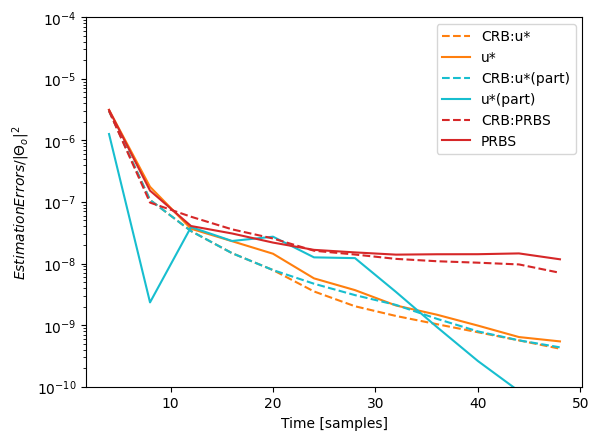

In [47]:
theta_norm = (true_theta**2).sum()
print('norm',theta_norm)
#plt.title('trace')
plt.yscale('log')
plt.plot(nsS300[0],theta_crbsS300.mean(axis=0)/theta_norm,c='C1',label='CRB:u*',linestyle='dashed')
plt.plot(nsS300[0],theta_msesS300.mean(axis=0)/theta_norm,c='C1',label='u*',linestyle='solid')


#plt.plot(nsS300[0],theta_crbsS3001.mean(axis=0)/theta_norm,c='C9',label='CRB:u*(part)',linestyle='dashed')
#plt.plot(nsS300[0],theta_msesS3001.mean(axis=0)/theta_norm,c='C9',label='u*(part)',linestyle='solid')

plt.plot(nsS301[0],theta_crbsS301.mean(axis=0)/theta_norm,c='C3',label='CRB:PRBS',linestyle='dashed')
plt.plot(nsS301[0],theta_msesS301.mean(axis=0)/theta_norm,c='C3',label='PRBS',linestyle='solid')

#plt.plot(nsS301[0],theta_crbsS302[0]/theta_norm,c='C2',label='CRB:ra-PRBS',linestyle='dashed')
#plt.plot(nsS301[0],theta_msesS302[0]/theta_norm,c='C2',label='ra-PRBS',linestyle='solid')


#plt.plot(nsS304[0],theta_msesS3041.mean(axis=0)/theta_norm,c='C5',label='u*(Constr.)',linestyle='solid')
#plt.plot(nsS304[0],theta_crbsS3041.mean(axis=0)/theta_norm,c='C5',label='CRB:u*(Constr.)',linestyle='dashed')
plt.ylim(1e-10,1e-4)

plt.xlabel('Time [samples]')
plt.ylabel('$Estimation Errors/|\Theta_o|^2$')
plt.legend()
#plt.savefig('plots/cruisecontrol_err2.pdf')

In [393]:
def compute_power(us,a):
    powers=[]
    p = 0
    for i in range(1,1+us.shape[1]):
        p = np.mean(us[:,:i]**2)/(a**2)
        powers.append(p)
    return powers

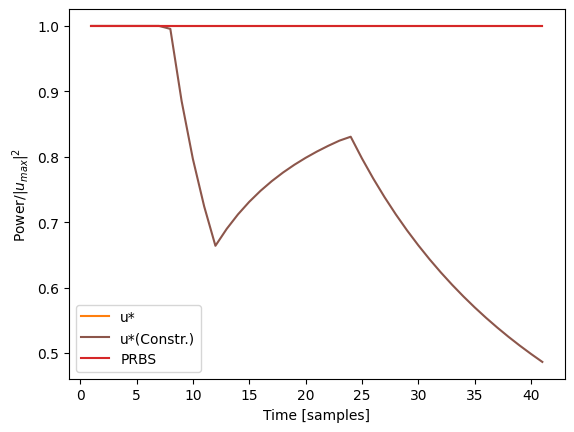

In [537]:
plt.plot(range(1,usS300[0].shape[1]+1),np.array([compute_power(usS300[i],1) for i in range(10)]).mean(axis=0),c='C1',label='u*')
plt.plot(range(1,usS304[0].shape[1]+1),np.array([compute_power(usS304[i],1) for i in range(10)]).mean(axis=0),c='C5',label='u*(Constr.)')
plt.plot(range(1,usS301[0].shape[1]+1),np.array([compute_power(usS301[i],1) for i in range(10)]).mean(axis=0),c='C3',label='PRBS')

plt.xlabel('Time [samples]')
plt.ylabel('Power/$|u_{max}|^2$')
plt.legend()
plt.savefig('plots/cruisecontrol_power.pdf')

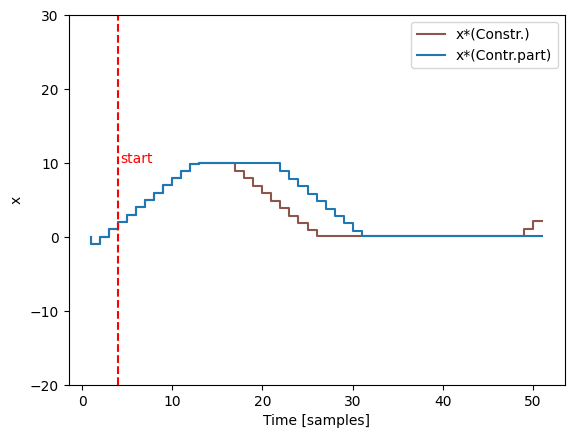

In [55]:
T=51
plt.step(range(1,1+T),xsS3041[0][0,:T],c='C5',label='x*(Constr.)')
plt.step(range(1,1+T),xsS3042[0][0,:T],c='C10',label='x*(Contr.part)')
plt.ylim(-20,30)
plt.plot([4,4.],[-20,30],c='red',linestyle='dashed')
plt.text(x=4.2,y=10,s='start',c='red')

plt.xlabel('Time [samples]')
plt.ylabel('x')
plt.legend()
#plt.savefig('plots/cruisecontrol_output_star.pdf')

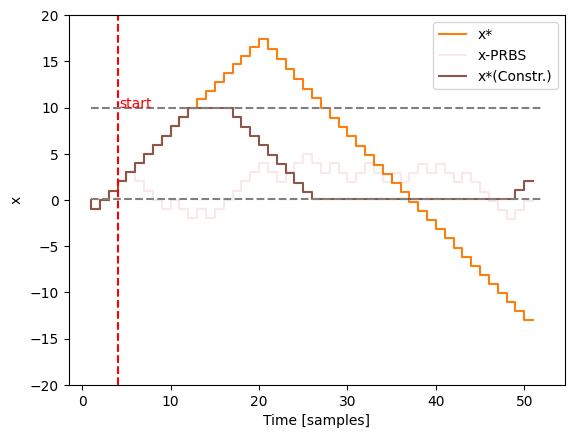

In [709]:
plt.step(range(1,1+T),xsS300[1][0,:T],c='C1',label='x*')
plt.step(range(1,1+T),xsS301[1][0,:T],c='C3',alpha=0.1,label='x-PRBS')
plt.step(range(1,1+T),xsS3041[0][0,:T],c='C5',label='x*(Constr.)')
plt.ylim(-20,20)
plt.plot([4,4.],[-20,20],c='red',linestyle='dashed')
plt.plot([1,T+1],[10.,10.],c='gray',linestyle='dashed')
plt.plot([1,T+1],[0.1,.1],c='gray',linestyle='dashed')
plt.text(x=4.2,y=10,s='start',c='red')

plt.xlabel('Time [samples]')
plt.ylabel('x')
plt.legend()
plt.savefig('plots/cruisecontrol_output_prbs_star.pdf')

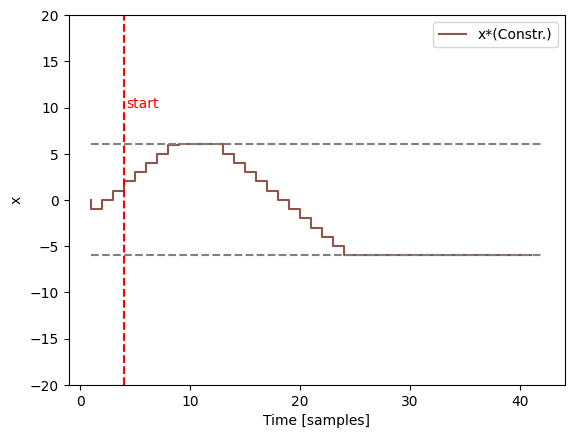

In [412]:
plt.step(range(1,1+T),xsS304[1][0,:T],c='C5',label='x*(Constr.)')
plt.plot([1,T+1],[6.,6.],c='gray',linestyle='dashed')
plt.plot([1,T+1],[-6.,-6.],c='gray',linestyle='dashed')
plt.ylim(-20,20)
plt.plot([4,4.],[-20,20],c='red',linestyle='dashed')
plt.text(x=4.2,y=10,s='start',c='red')

plt.xlabel('Time [samples]')
plt.ylabel('x')
plt.legend()
plt.savefig('plots/cruisecontrol_output_c.pdf')

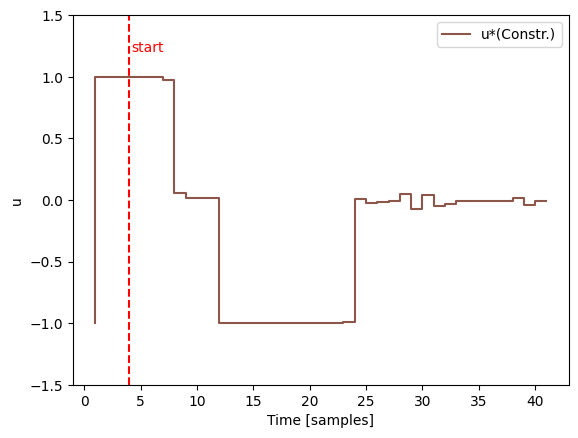

In [548]:
plt.xlabel('Time [samples]')
plt.ylabel('u')
plt.ylim(-1.5,1.5)
plt.step(range(1,1+T),usS304[0][0,:T],c='C5',label='u*(Constr.)')
plt.plot([4,4.],[-1.5,1.5],c='red',linestyle='dashed')
plt.text(x=4.2,y=1.2,s='start',c='red')
plt.legend()
plt.savefig('plots/cruisecontrol_u_c.pdf')

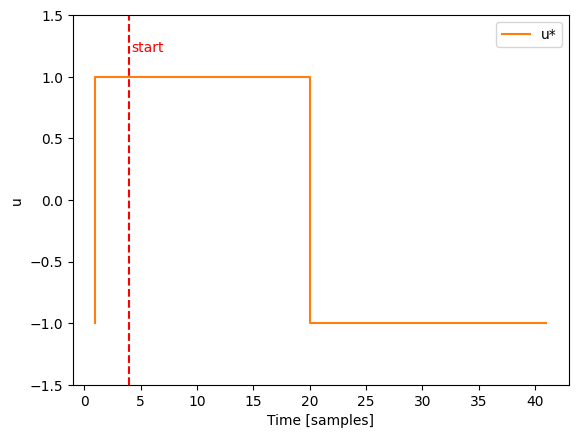

In [413]:
plt.xlabel('Time [samples]')
plt.ylim(-1.5,1.5)
plt.ylabel('u')
plt.step(range(1,1+T),usS300[0][0,:T],c='C1',label='u*')
plt.plot([4,4.],[-1.5,1.5],c='red',linestyle='dashed')
plt.text(x=4.2,y=1.2,s='start',c='red')
plt.legend()
#plt.savefig('plots/cruisecontrol_u_star.pdf')

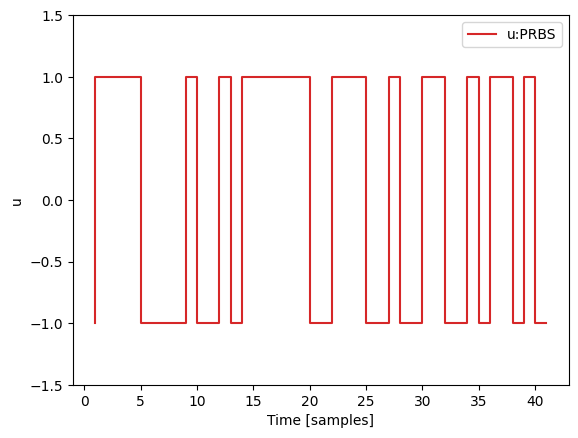

In [550]:
plt.xlabel('Time [samples]')
plt.ylabel('u')
plt.ylim(-1.5,1.5)
plt.step(range(1,1+T),usS301[0][0,:T],c='C3',label='u:PRBS')
plt.legend()
plt.savefig('plots/cruisecontrol_u_prbs.pdf')

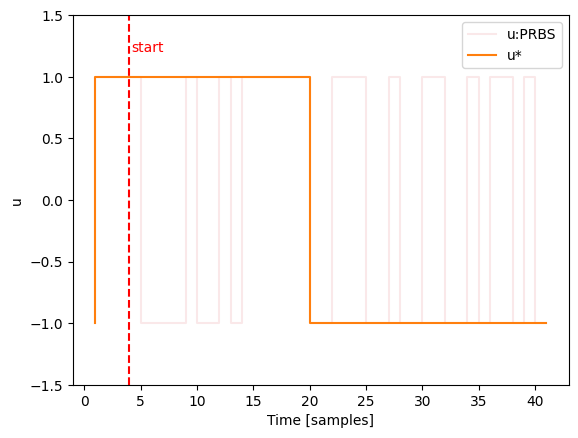

In [414]:
plt.xlabel('Time [samples]')
plt.ylabel('u')
plt.ylim(-1.5,1.5)
plt.step(range(1,1+T),usS301[0][0,:T],c='C3',alpha=0.1,label='u:PRBS')
plt.step(range(1,1+T),usS300[0][0,:T],c='C1',label='u*')
plt.plot([4,4.],[-1.5,1.5],c='red',linestyle='dashed')
plt.text(x=4.2,y=1.2,s='start',c='red')
plt.legend()
plt.savefig('plots/cruisecontrol_u_prbs_star.pdf')

In [841]:
class StateSpaceTwoTankModel(StateSpaceLinearModel):
    #state x velocity
    def __init__(self,u_range,gamma2,v_norm,dt):
        self.u_range = u_range
        self.gamma2 = gamma2
        self.invGamma = torch.diag(torch.tensor(1/gamma2.flatten()))
        self.invGamma_np = np.diag(1/gamma2.flatten())
        self.v_norm = v_norm
        self.dt = dt 
        self.H = torch.eye(2)
        self.H2 = np.eye(2)
        self.H3 = np.array([[0.,0.,0.,1.,0.],[0.,0.,0.,0.,1.]])
        self.A1 = 0.1
        self.A2 = 0.1
        self.CI = torch.eye(5)
        self.CI2 = np.eye(5)
        
        self.eps =torch.zeros((2,1)) #torch.ones((2,1))*1e-24#torch.ones((2,1))*1e-6###torch.zeros((2,1))#
        
        self.x12 = torch.tensor(0.)
        self.xw13 = torch.tensor(0.)
        self.xw21 = torch.tensor(0.)
        
    def transition(self,theta,x,u):
    
        x_ = torch.maximum(x,torch.zeros((2,1)))
        
        q12 = theta[1,:]*torch.sqrt(x_[0,:]+1.0e-64)
        x1_ = x_[0,:] + (theta[0]*u[0,:]- q12)*self.dt/self.A1
        x2_ = x_[1,:] + (q12-theta[2,:]*torch.sqrt(x_[1,:]+1.0e-64))*self.dt/self.A2
        
        return torch.maximum(torch.vstack([x1_,x2_]),torch.zeros((2,1)))
    
    def transition_np(self,theta,x,u):
        x_ = np.maximum(x,np.zeros((2,1)))
        
        q12 = theta[1,:]*np.sqrt(x_[0,:]+1.0e-64)
        x1_ = x_[0,:] + (theta[0]*u[0,:]- q12)*self.dt/self.A1
        x2_ = x_[1,:] + (q12-theta[2,:]*np.sqrt(x_[1,:]+1.0e-64))*self.dt/self.A2
        
        return np.maximum(np.vstack([x1_,x2_]),np.zeros((2,1)))
    
    def dxx(self,theta,x,u):
        if x[0,0]>0:
            sqrtx1 = torch.sqrt(x[0,0])
            x11 = 1-0.5*self.dt*theta[1,0]/sqrtx1/self.A1
            x21 = 0.5*self.dt*theta[1,0]/sqrtx1/self.A2
        else:
            x11 = torch.tensor(0.)
            x21 = torch.tensor(0.)
        
        if x[1,0]>0:
            x22 = 1-0.5*self.dt*theta[2,0]/torch.sqrt(x[1,0])/self.A2   
        else:
            x22 = torch.tensor(0.)
        
        ret= torch.vstack([torch.hstack([x11,self.x12]),torch.hstack([x21,x22])])
        
        return ret
    
    def dxx_np(self,theta,x,u):
        dXX = np.zeros((x.shape[0],x.shape[0]))
        
        if x[0,0]>0:
            sqrtx1 = np.sqrt(x[0,0])
            dXX[0,0] = 1-0.5*self.dt*theta[1,0]/sqrtx1/self.A1
            dXX[1,0] = 0.5*self.dt*theta[1,0]/sqrtx1/self.A2

        if x[1,0]>0:
            dXX[1,1] = 1-0.5*self.dt*theta[2,0]/np.sqrt(x[1,0])/self.A2   
        return dXX
    
    def dxtheta(self,theta,x,u):
        xw11 = u[0,0]*self.dt/self.A1
            
        
        if x[1,0]>0:
            xw23 = -torch.sqrt(x[1,0])*self.dt/self.A2
        else:
            xw23 = torch.tensor(0.)
        
        if x[0,0]>0:
            xw12 = -torch.sqrt(x[0,0])*self.dt/self.A1
            xw22 = torch.sqrt(x[0,0])*self.dt/self.A2
        else:
            xw12 = torch.tensor(0.)
            xw22 = torch.tensor(0.)
            
        
        ret= torch.vstack([torch.hstack([xw11,xw12,self.xw13]),torch.hstack([self.xw21,xw22,xw23])])
        return ret
    
    def fim(self, theta, x0, uk,x_=None,dx_theta=None,dx_x0=None):
        N = uk.shape[1]
        M1 = theta.shape[0]
        M2 = x0.shape[0]
        M3 = self.H.shape[0]
        
        if N==0:
            return torch.zeros((M1+M2,M1+M2))
        
        if dx_theta is None:
            dx_theta = torch.zeros((M2,M1))
            
        if dx_x0 is None:
            dx_x0 = torch.eye(M2)
            
        if x_ is None:
            x_ = x0.clone()
    
        I = []
        yk = []
        for i in range(N):
            d_mu = self.H@torch.hstack([dx_theta,dx_x0])
            
            x_pred = self.transition(theta,x_,uk[:,[i]])
            
            if x_pred[0,0]==0:
                d_mu[0,:] = 0
            if x_pred[1,0]==0:
                d_mu[1,:] = 0
                    
            I.append((d_mu.T@self.invGamma@d_mu).unsqueeze(0))
            
            xx = self.dxx(theta,x_,uk[:,[i]])
            xw = self.dxtheta(theta,x_,uk[:,[i]])
            dx_theta = xx@dx_theta + xw
            dx_x0 = xx@dx_x0
            x_ = x_pred.clone()
            yk.append(self.predict(x_))
            
        return torch.concatenate(I).sum(axis=0),x_,dx_theta,dx_x0,torch.hstack(yk)
    
    def dxtheta_np(self,theta,x,u):
        dXW = np.zeros((x.shape[0],theta.shape[0]))
        
        dXW[0,0] = u[0,0]*self.dt/self.A1
            
        
        if x[1,0]>0:
            dXW[1,2] = -np.sqrt(x[1,0])*self.dt/self.A2
        
        if x[0,0]>0:
            dXW[0,1] = -np.sqrt(x[0,0])*self.dt/self.A1
            dXW[1,1] = np.sqrt(x[0,0])*self.dt/self.A2
        return dXW
    
    def control_criterion(self, uk, theta, x0,fim_prev,C_prev):
        I_,_,_,_,yk = self.fim(theta,x0,uk)
        I = I_@C_prev+self.CI
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        
        I2 = A-B@torch.linalg.inv(D)@C
        return torch.trace(torch.linalg.inv(I2))
    
    def control_criterion_np(self, uk, theta, x0, fim_prev,C_prev):
        I_ = self.fim_np(theta,x0,uk)[0]
        I = I_@C_prev+self.CI2
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        
        I2 = A-B@scipy.linalg.pinv(D)@C
        return np.trace(scipy.linalg.pinv(I2))

class StateSpaceTwoTankModel2(StateSpaceTwoTankModel):
    def control_criterion(self, uk, theta, x0,fim_prev,C_prev):
        I_,_,_,_,yk = self.fim(theta,x0,uk)
        I = I_ + fim_prev
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        
        I2 = (A-B@torch.linalg.inv(D)@C)@C_prev[:M,:M]
        return torch.trace(torch.linalg.inv(I2))
    
    def control_criterion_np(self, uk, theta, x0, fim_prev,C_prev):
        I_ = self.fim_np(theta,x0,uk)[0]
        I = I_ + fim_prev
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        I2 = (A-B@scipy.linalg.pinv(D)@C)@C_prev[:M,:M]
        return np.trace(scipy.linalg.pinv(I2))
    
class BarrierSSTwoTankModel2(StateSpaceTwoTankModel):
    def __init__(self,u_range,gamma2,v_norm,dt,y_range,K):
        self.y_range_np = np.tile(np.expand_dims(y_range,2),(1,1,K))
        self.y_range = torch.tensor(self.y_range_np)
        self.yfac = 5
        super().__init__(u_range,gamma2,v_norm,dt)
        
    def barrier_term(self,yk):
        y_dim,K = yk.shape
        sc = 3./K
        
        l = torch.nn.functional.relu(self.y_range[:,0,:]-yk)
        u = torch.nn.functional.relu(yk-self.y_range[:,1,:])
        b = torch.exp(((self.yfac*(l+u))**2).sum(axis=0)).sum()
        
        return b*sc    
    
    def barrier_term_np(self,yk):
        y_dim,K = yk.shape
        sc = 3./K
        l =np.maximum(np.zeros((y_dim,K)),self.y_range_np[:,0,:]-yk)
        u =np.maximum(np.zeros((y_dim,K)),yk-self.y_range_np[:,1,:])
        b=np.exp(((self.yfac*(l+u))**2).sum(axis=0)).sum()
        return b*sc   
    
    def control_criterion(self, uk, theta, x0,fim_prev,C_prev):
        I_,_,_,_,yk = self.fim(theta,x0,uk)
        I = I_+fim_prev
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        I2 =  (A-B@torch.linalg.inv(D)@C)@C_prev[:M,:M]
        return torch.trace(torch.linalg.inv(I2)) + self.barrier_term(yk)
    
    def control_criterion_np(self, uk, theta, x0,fim_prev,C_prev):
        I_,yk = self.fim_np(theta,x0,uk)
        I = I_+fim_prev
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        I2 =  (A-B@np.linalg.inv(D)@C)@C_prev[:M,:M]
        return np.trace(np.linalg.inv(I2)) + self.barrier_term_np(yk)
    
class BarrierSSTwoTankModel(StateSpaceTwoTankModel):
    def __init__(self,u_range,gamma2,v_norm,dt,y_range):
        self.y_range = y_range
        self.yfac = 5
        super().__init__(u_range,gamma2,v_norm,dt)
        
    def barrier_term(self,yk):
        y_dim,K = yk.shape
        sc = 3./K
        b = 0
        for i in range(y_dim):
            l =torch.maximum(torch.zeros((y_dim,K)),torch.tensor(self.y_range[i,0])-yk[i,:])
            u =torch.maximum(torch.zeros((y_dim,K)),yk[i,:]-torch.tensor(self.y_range[i,1]))
            b+=torch.exp(((self.yfac*(l+u))**2).sum())
        return b*sc
    
    def control_criterion(self, uk, theta, x0,fim_prev,C_prev):
        I_,_,_,_,yk = self.fim(theta,x0,uk)
        I = I_@C_prev+self.CI
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        
        I2 = A-B@torch.linalg.inv(D)@C
        return torch.trace(torch.linalg.inv(I2)) + self.barrier_term(yk)

In [842]:
def evaluatorS400(xs,theta,C_prev,ys,us,u_test,y_test):
    amplitude = 0.5
    dt = 0.2
    block_size = 6
    gamma2 = (lambda_true**2)
    v_norm = q_alpha_d(5)
    model = StateSpaceTwoTankModel([0,amplitude],np.ones((2,1))*gamma2,v_norm,dt) 
    T_min = 0
    N = xs.shape[1]
    
    print('true x',xs,'true u',us,'theta',theta)
    
    if N<=T_min:#full mle
        C = np.linalg.inv(model.fim(torch.tensor(theta),torch.tensor(xs[:,[0]]),torch.tensor(us))[0].numpy()+np.eye(C_prev.shape[0])*1e-3)
        print(C)
        x_prop,C_prev = propogate_x(theta,xs[:,[0]],model.transition_np,us,C)
    else:
        FM = model.fim(torch.tensor(theta),torch.tensor(xs[:,[-block_size]]),torch.tensor(us[:,-block_size:]))[0].numpy()+scipy.linalg.pinv(C_prev)
        C = scipy.linalg.pinv(FM)
        #J_ = torch.tensor(C)
        #for i in range(block_size):
        #    j = -block_size+i 
        #    jac_prev = model.transition_jac(torch.tensor(theta),torch.tensor(xs[:,[j]]),torch.tensor(us[:,[j]]))
            
        #    J_ = jac_prev@J_@jac_prev.T
        #C_prev =J_.detach().numpy()
        
        x_prop,C_prev = propogate_x(theta,xs[:,[-block_size]],model.transition_np,us[:,-block_size:],C)
        
    print('C_prev',C_prev)
    print('supposed C',C,FM)
    
    #I = scipy.linalg.pinv(C)
    M = theta.shape[0]
    #Ia = I[:M,:M]
    #Ib = I[:M,M:]
    #Ic = I[M:,:M]
    #Id = I[M:,M:]
    
    
    #C_theta = scipy.linalg.pinv(Ia-Ib@scipy.linalg.pinv(Id)@Ic)  #
    #tr_crb = np.abs(np.trace(C[:M,:M]))
    C_theta = C[:M,:M]
    tr_crb = np.abs(np.trace(C_theta@np.diag(1/(theta.flatten()**2))))
    
    
                     
    mse = 0
    x_ = xs[:,[0]]
    Hn = model.H.numpy()
    for i in range(u_test.shape[0]):
        mse += ((y_test[:,[i]]-Hn@x_)**2)
        x_ = model.transition_np(theta,x_,u_test[:,[i]])
                
    mse/= u_test.shape[0]
    return tr_crb,mse,C_prev      


def estimatorS400(x_init0,theta0,invC0,gamma0,invS0,ys,us,t):
    print(us,ys)
    amplitude = 0.5
    dt = 0.2
    block_size = 6
    v_norm = q_alpha_d(5)
    model = StateSpaceTwoTankModel([0,amplitude],gamma0,v_norm,dt) 
    T_min = 0
    Gamma = np.eye(2)*gamma0
    
    N = ys.shape[1]
    
    if t==1:
        lr = 1
        n_iter = 1000
        Gamma = Gamma
        x_init,theta,invC = recursive_mle(model,ys,us,T_min,block_size,theta0,x_init0,invC0,Gamma,lr=lr,n_iter=n_iter,nonneg_x=False)
        print('first try',theta)
        lr = 1e-1
        n_iter = 1000
        x_init,theta,invC = recursive_mle(model,ys,us,T_min,block_size,theta,x_init0,invC0,Gamma,lr=lr,n_iter=n_iter)
        print('second try',theta)
        
        
        x_init,theta,invC = recursive_mle_opt(model,ys,us,block_size,theta,x_init0,invC0,0.1,600)
        gamma1,invS1 = recursive_mle_sigma(model,ys,us,block_size,theta,x_init,invC,gamma0,invS0,n_iter=100)
        #lr = 5e-4
        #n_iter = 60000
        #x_init,theta,invC = recursive_mle(model,ys,us,T_min,block_size,theta,x_init0,invC0,Gamma,lr=lr,n_iter=n_iter)
        
    #elif t<9:
    #    lr = 1/min(1e8,np.sqrt(np.diag(invC0)[:3].max()))
    #    n_iter = 60000
    #    x_init,theta,invC = recursive_mle(model,ys,us,T_min,block_size,theta0,x_init0,invC0,Gamma,lr=lr,n_iter=n_iter,nonneg_x=False)
    #else:
    #    lr = 1/min(1e8,np.sqrt(np.diag(invC0)[:3].max()))
    #    n_iter = 60000
    #    x_init,theta,invC = recursive_mle(model,ys,us,T_min,block_size,theta0,x_init0,invC0,Gamma,lr=lr,n_iter=n_iter,nonneg_x=False)
    #print('lr',lr)
    else:
        x_init,theta,invC = recursive_mle_opt(model,ys,us,block_size,theta0,x_init0,invC0,0.1,600)
        gamma1,invS1 = recursive_mle_sigma(model,ys,us,block_size,theta,x_init,invC,gamma0,invS0,n_iter=100)
    try:
        torch.cholesky(torch.tensor(invC))
    except:
        invC += np.eye(invC.shape[0])*1e-6
        print('Singular!',t,invC)

            
    print('estimation theta',theta,invC,np.linalg.pinv(invC))
    return x_init,theta,invC,gamma1,invS1

In [845]:
T = 43
amplitude = 0.5
dt = 0.2
simulator = simulate_nonlinear16
simulator2 = lambda u,Q,seed,dt:simulate_nonlinear16(u,Q,x0=np.array([1.,1.]),seed=seed,dt=dt)
simulator3 = lambda u,Q,seed,dt:simulate_nonlinear16(u,Q,x0=np.array([.01,2.]),seed=seed,dt=dt)
evaluator = evaluatorS400 
estimator = estimatorS400
gamma2 = (lambda_true**2)
QS400 = np.eye(2)*gamma2
v_norm = q_alpha_d(5)
model = StateSpaceTwoTankModel([0,amplitude],np.ones((2,1))*(lambda_true**2),v_norm,dt)  


T_min = 0
block_size = 6
repeat = 1
true_theta = np.array([[1.],[.2],[.15]])#[2.],
_rngS400 = list(range(block_size,T,block_size))
theta0 = np.ones((3,1))*0.1
invC0 = np.eye(5)*1e-4
gamma0 = np.ones((2,1))*(lambda_true**2)
invS0 = np.eye(2)*1e18

x_init0 = np.ones((2,1))*0.1

US400_T = lambda seed:np.abs(np.roll(scaled_PRBS_RA(seed,T,scale=amplitude/2.,dt=dt),3))
US402 = lambda seed:amplitude/2.+np.roll(scaled_PRBS_RA(seed,T,scale=amplitude/2.,dt=dt),3)

def US401(seed):
    return amplitude/2.+np.roll(scaled_PRBS(T,scale=amplitude/2.,dt=dt,seed=seed),3)

def US400(seed):
    K = 4
    model = StateSpaceTwoTankModel([0,amplitude],gamma0,v_norm,dt)
    us = US401(seed)[:block_size]
    return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS400,T_min,block_size,weight='full',seed=seed,dt=dt,minmax=False,n_iter=30000)


def US405(seed):
    K = 4
    model = StateSpaceTwoTankModel([0,amplitude],gamma0,v_norm,dt) 
    us = US401(seed)[:block_size]
    return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator2,QS400,T_min,block_size,seed=seed,dt=dt,minmax=False,n_iter=30000)

def US4051(seed):
    K = 5
    model = StateSpaceTwoTankModel([0,amplitude],gamma0,v_norm,dt) 
    us = US401(seed)[:block_size]
    return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator2,QS400,block_size,dt=dt,seed=seed,n_iter=500)
    #return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,simulator2,QS400,T_min,block_size,seed=seed,dt=dt,minmax=False,lr_desc=1e-3,n_iter=20000)
def US4052(seed):
    K = 5
    model = StateSpaceTwoTankModel([0,amplitude],gamma0,v_norm,dt) 
    us = US401(seed)[:block_size]
    return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator2,QS400,T_min,block_size,weight='full',seed=seed,dt=dt,minmax=False,lr_desc=1e-3,n_iter=20000)


def US40520(seed):
    K = 5
    model = StateSpaceTwoTankModel([0,amplitude],gamma0,v_norm,dt) 
    us = US401(seed)[:block_size]
    #return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator2,QS400,T_min,block_size,weight='full',seed=seed,dt=dt,minmax=False,lr_desc=1e-3,n_iter=20000)
    return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator2,QS400,block_size,dt=dt,seed=seed,n_iter=400)

def US4054(seed):
    K = 5
    model = StateSpaceTwoTankModel2([0,amplitude],gamma0,v_norm,dt) 
    us = US401(seed)[:block_size]
    return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator2,QS400,T_min,block_size,weight='full',seed=seed,dt=dt,minmax=False,lr_desc=1e-3,n_iter=30000)

def US40540(seed):
    K = 5
    model = StateSpaceTwoTankModel2([0,amplitude],gamma0,v_norm,dt)
    us = US401(seed)[:block_size]
    #return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator2,QS400,T_min,block_size,weight='full',seed=seed,dt=dt,minmax=False,n_iter=30000)
    return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator2,QS400,block_size,weight='full',dt=dt,seed=seed,n_iter=400)


def US4041(seed):
    K = 5
    model = BarrierSSTwoTankModel([0,amplitude],gamma0,v_norm,dt,np.array([[0.,3],[0.,3]]),K)
    us = US401(seed)[:block_size]
    return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator2,QS400,T_min,block_size,seed=seed,dt=dt,minmax=False,lr_desc=1e-3,n_iter=20000)

#Try to reduce k?
def US4042(seed):
    K = 4
    model = BarrierSSTwoTankModel2([0,amplitude],gamma0,v_norm,dt,np.array([[0.,3],[0.,3]]),K)
    us = US401(seed)[:block_size]
    return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator2,QS400,T_min,block_size,weight='full',seed=seed,dt=dt,minmax=False,lr_desc=1e-3,n_iter=40000)

def US40420(seed):
    K = 5
    model = BarrierSSTwoTankModel2([0,amplitude],gamma0,v_norm,dt,np.array([[0.,3],[0.,3]]),K)
    us = US401(seed)[:block_size]`
    return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator2,QS400,block_size,weight='full',dt=dt,seed=seed,n_iter=200)




SyntaxError: invalid syntax (646267981.py, line 96)

In [684]:
presdS407,theta_crbsS407,theta_msesS407,powerS407,usS407,ysS407,xsS407,nsS407 = monte_carlo_ss(US401,US400_T,model,estimator,evaluator,simulator2,3,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS400,Q=QS400,a=amplitude,dt=dt)

  0%|          | 0/3 [00:00<?, ?it/s]


  0%|                                                                                                             | 0/7 [00:00<?, ?it/s]

true x [[1.         0.6        0.29016133 1.07469483 1.66002487 2.14465706]
 [1.         1.1        1.09519601 0.99670768 1.11187189 1.31090369]] true u [[0.  0.  0.5 0.5 0.5 0. ]] theta [[1.  ]
 [0.2 ]
 [0.15]]
C_prev [[ 6.38000377e-05  2.36243786e-05  1.81716627e-05 -5.19859582e-05
   4.64287345e-05]
 [ 2.36243786e-05  1.04277209e-05  8.05930652e-06 -3.21909209e-05
   1.79909941e-05]
 [ 1.81716627e-05  8.05930652e-06  7.72844852e-06 -2.43408609e-05
   4.17190019e-06]
 [-5.19859582e-05 -3.21909209e-05 -2.43408609e-05  1.44139509e-04
  -4.61556640e-05]
 [ 4.64287345e-05  1.79909941e-05  4.17190019e-06 -4.61556640e-05
   1.05202474e-04]]
supposed C [[ 6.38000377e-05  2.36243786e-05  1.81716627e-05  3.56022441e-05
  -4.26419123e-06]
 [ 2.36243786e-05  1.04277209e-05  8.05930652e-06  1.86855839e-05
  -2.49008229e-06]
 [ 1.81716627e-05  8.05930652e-06  7.72844852e-06  1.77579369e-05
   3.80238069e-06]
 [ 3.56022441e-05  1.86855839e-05  1.77579369e-05  8.11028497e-05
  -7.86241821e-06]
 [-4


 14%|██████████████▍                                                                                      | 1/7 [00:17<01:43, 17.30s/it]

estimation theta [[1.00366126]
 [0.19989609]
 [0.148865  ]] [[  3583735.9697851  -17611037.75408421   3915205.50923173
   -1820171.91104549    468983.68937388]
 [-17611037.75408483  95451423.45224307 -26754340.82377628
    9323858.26057299  -3359038.50958733]
 [  3915205.50923223 -26754340.82377805  10903822.91826765
   -2256084.72137603   1413405.59128399]
 [ -1820171.91104552   9323858.26057282  -2256084.72137581
     958176.83630927   -277453.1906981 ]
 [   468983.68937395  -3359038.50958759   1413405.59128399
    -277453.19069813    197666.3950043 ]] [[ 6.39964602e-05  2.36569574e-05  1.82471798e-05 -5.22412250e-05
   4.63719402e-05]
 [ 2.36569574e-05  1.04179698e-05  8.07453870e-06 -3.22327033e-05
   1.79290465e-05]
 [ 1.82471798e-05  8.07453870e-06  7.75807765e-06 -2.44449898e-05
   4.13528052e-06]
 [-5.22412250e-05 -3.22327033e-05 -2.44449898e-05  1.44546161e-04
  -4.61137076e-05]
 [ 4.63719402e-05  1.79290465e-05  4.13528052e-06 -4.61137076e-05
   1.05417262e-04]]
[1.34048530e-

...

estimation theta [[0.99882858]
 [0.19975949]
 [0.14975065]] [[ 2.43907693e+10 -1.74631432e+11  2.41618409e+10 -7.75475946e+09
   5.73637583e+08]
 [-1.74631432e+11  1.25904223e+12 -1.81667857e+11  5.58886407e+10
  -4.32095070e+09]
 [ 2.41618409e+10 -1.81667857e+11  3.25825085e+10 -8.04526853e+09
   7.82002689e+08]
 [-7.75475946e+09  5.58886407e+10 -8.04526853e+09  2.48117016e+09
  -1.91368883e+08]
 [ 5.73637583e+08 -4.32095070e+09  7.82002689e+08 -1.91368883e+08
   1.88717197e+07]] [[ 2.95731821e-06  6.07603680e-07  5.85700046e-07 -2.84278042e-06
  -3.87044997e-06]
 [ 6.07603680e-07  1.34160572e-07  1.22827509e-07 -7.91748522e-07
  -8.69584881e-07]
 [ 5.85700046e-07  1.22827509e-07  1.23182335e-07 -6.17108225e-07
  -1.04241558e-06]
 [-2.84278042e-06 -7.91748522e-07 -6.17108225e-07  7.36064515e-06
   5.34122445e-06]
 [-3.87044997e-06 -8.69584881e-07 -1.04241558e-06  5.34122445e-06
   1.59560502e-05]]
[1.37223070e-06 1.44606839e-06 2.76341164e-06]
true x [[1.         0.6        0.29016133


 86%|██████████████████████████████████████████████████████████████████████████████████████▌              | 6/7 [02:10<00:24, 24.00s/it]

estimation theta [[0.99900105]
 [0.19985578]
 [0.14980963]] [[ 1.64807143e+11 -1.09272361e+12  1.11586503e+11 -5.79596704e+10
   2.48236004e+09]
 [-1.09272361e+12  7.26227094e+12 -7.59241193e+11  3.85227595e+11
  -1.69029727e+10]
 [ 1.11586503e+11 -7.59241193e+11  9.74838480e+10 -4.02997285e+10
   2.18429467e+09]
 [-5.79596704e+10  3.85227595e+11 -4.02997285e+10  2.04348682e+10
  -8.97272570e+08]
 [ 2.48236004e+09 -1.69029727e+10  2.18429467e+09 -8.97272570e+08
   4.90882440e+07]] [[ 2.15033109e-06  4.22211915e-07  3.85896898e-07 -1.23760789e-06
  -3.15031882e-06]
 [ 4.22211915e-07  9.01962382e-08  7.70014914e-08 -3.80822959e-07
  -6.80272299e-07]
 [ 3.85896898e-07  7.70014914e-08  7.33972171e-08 -2.45001385e-07
  -7.44273972e-07]
 [-1.23760789e-06 -3.80822959e-07 -2.45001385e-07  3.31603174e-06
   2.96787572e-06]
 [-3.15031882e-06 -6.80272299e-07 -7.44273972e-07  2.96787572e-06
   1.24532577e-05]]
[9.97892583e-07 5.19995939e-07 1.61068597e-06]
true x [[1.         0.6        0.29016133


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [02:36<00:00, 22.33s/it]

estimation theta [[0.99900105]
 [0.19985578]
 [0.14980963]] [[ 1.72033483e+12 -8.64819734e+12  5.71199118e+11 -6.06116781e+11
   1.28787117e+10]
 [-8.64819734e+12  4.34946938e+13 -2.90349156e+12  3.04857259e+12
  -6.54804830e+10]
 [ 5.71199118e+11 -2.90349156e+12  2.41518721e+11 -2.03832570e+11
   5.47404047e+09]
 [-6.06116781e+11  3.04857259e+12 -2.03832570e+11  2.13679567e+11
  -4.59719806e+09]
 [ 1.28787117e+10 -6.54804830e+10  5.47404047e+09 -4.59719806e+09
   1.24278792e+08]] [[ 1.60882358e-06  3.04351359e-07  2.66445561e-07  4.22100951e-07
  -2.48274990e-06]
 [ 3.04351359e-07  6.39011584e-08  5.10130632e-08 -1.09484722e-08
  -5.22652034e-07]
 [ 2.66445561e-07  5.10130632e-08  4.69230791e-08  6.12642800e-08
  -5.33722269e-07]
 [ 4.22100951e-07 -1.09484721e-08  6.12642800e-08  1.41425371e-06
   1.06322025e-07]
 [-2.48274990e-06 -5.22652034e-07 -5.33722269e-07  1.06322025e-07
   9.35407654e-06]]
[9.97891987e-07 5.19997573e-07 1.61068595e-06]


In [819]:
import pickle
with open('plotsdata/S407.pk','wb') as f:
    pickle.dump((presdS407,theta_crbsS407,theta_msesS407,powerS407,usS407,ysS407,xsS407,nsS407),f)


In [66]:

with open('plotsdata/S407.pk','rb') as f:
    (presdS407,theta_crbsS407,theta_msesS407,powerS407,usS407,ysS407,xsS407,nsS407) = pickle.load(f)

In [475]:
#presdS4053,theta_crbsS4053,theta_msesS4053,powerS4053,usS4053,ysS4053,xsS4053,nsS4053 = monte_carlo_ss(US4053,US400_T,model,estimator,evaluator,simulator2,10,x_init0,theta0,invC0,true_theta,T_min,block_size,_rngS400,Q=QS400,a=amplitude,dt=dt)

In [476]:
#presdS4051,theta_crbsS4051,theta_msesS4051,powerS4051,usS4051,ysS4051,xsS4051,nsS4051 = monte_carlo_ss(US4051,US400_T,model,estimator,evaluator,simulator2,1,x_init0,theta0,invC0,true_theta,T_min,block_size,_rngS400,Q=QS400,a=amplitude,dt=dt)

In [477]:
#import pickle
#with open('plotsdata/S4051.pk','wb') as f:
#    pickle.dump((presdS4051,theta_crbsS4051,theta_msesS4051,powerS4051,usS4051,ysS4051,xsS4051,nsS4051),f)


In [634]:
#presdS4052,theta_crbsS4052,theta_msesS4052,powerS4052,usS4052,ysS4052,xsS4052,nsS4052 = monte_carlo_ss(US4052,US400_T,model,estimator,evaluator,simulator2,10,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS400,Q=QS400,a=amplitude,dt=dt)

In [686]:
presdS40520,theta_crbsS40520,theta_msesS40520,powerS40520,usS40520,ysS40520,xsS40520,nsS40520 = monte_carlo_ss(US40520,US400_T,model,estimator,evaluator,simulator2,3,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS400,Q=QS400,a=amplitude,dt=dt)

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/37 [00:00<?, ?it/s]

[[0.  0.  0.5 0.5 0.5 0. ]] [[1.0035404  0.59468402 0.29034849 1.08512818 1.68231851 2.1423748 ]
 [0.99995035 1.07723434 1.1044697  0.99134569 1.13130881 1.30935188]]
N= 6
F1 [[  115217.28989827  -285210.88001121   -39865.62140148    25462.40219426
      3136.79539876]
 [ -285210.88001121  1729385.05980178 -1109390.58430725   -26784.64795861
    128242.27102742]
 [  -39865.62140148 -1109390.58430725  1668173.08506679  -114447.66944828
   -185341.42025191]
 [   25462.40219426   -26784.64795861  -114447.66944828    35506.78520351
     13604.3344156 ]
 [    3136.79539876   128242.27102742  -185341.42025191    13604.3344156
     38471.07414553]] [[ 9.29731075e-05  3.47698979e-05  2.83672341e-05  5.31422316e-05
  -5.61329603e-06]
 [ 3.47698979e-05  1.46563288e-05  1.20465008e-05  2.60496098e-05
  -2.86706261e-06]
 [ 2.83672341e-05  1.20465008e-05  1.13396827e-05  2.38701372e-05
   3.72026872e-06]
 [ 5.31422316e-05  2.60496098e-05  2.38701372e-05  8.96629729e-05
  -7.87701867e-06]
 [-5.61329


  0%|                                                                                                             | 0/7 [00:00<?, ?it/s]

true x [[1.         0.6        0.29016133 1.07469483 1.66002487 2.14465706]
 [1.         1.1        1.09519601 0.99670768 1.11187189 1.31090369]] true u [[0.  0.  0.5 0.5 0.5 0. ]] theta [[1.  ]
 [0.2 ]
 [0.15]]
C_prev [[ 6.38000377e-05  2.36243786e-05  1.81716627e-05 -5.19859582e-05
   4.64287345e-05]
 [ 2.36243786e-05  1.04277209e-05  8.05930652e-06 -3.21909209e-05
   1.79909941e-05]
 [ 1.81716627e-05  8.05930652e-06  7.72844852e-06 -2.43408609e-05
   4.17190019e-06]
 [-5.19859582e-05 -3.21909209e-05 -2.43408609e-05  1.44139509e-04
  -4.61556640e-05]
 [ 4.64287345e-05  1.79909941e-05  4.17190019e-06 -4.61556640e-05
   1.05202474e-04]]
supposed C [[ 6.38000377e-05  2.36243786e-05  1.81716627e-05  3.56022441e-05
  -4.26419123e-06]
 [ 2.36243786e-05  1.04277209e-05  8.05930652e-06  1.86855839e-05
  -2.49008229e-06]
 [ 1.81716627e-05  8.05930652e-06  7.72844852e-06  1.77579369e-05
   3.80238069e-06]
 [ 3.56022441e-05  1.86855839e-05  1.77579369e-05  8.11028497e-05
  -7.86241821e-06]
 [-4

...

Singular! 5 [[ 9.40253650e+06 -2.06808148e+07 -2.65802687e+07  1.50028588e+06
  -1.32770683e+04]
 [-2.06808148e+07  1.47132806e+08 -2.61804608e+07 -3.29986855e+06
   3.71082285e+04]
 [-2.65802687e+07 -2.61804608e+07  1.79851188e+08 -4.24119618e+06
   9.19474396e+04]
 [ 1.50028588e+06 -3.29986855e+06 -4.24119618e+06  2.39388353e+05
  -2.11851324e+03]
 [-1.32770683e+04  3.71082285e+04  9.19474396e+04 -2.11851324e+03
   2.34980513e+03]]
estimation theta [[0.9989179 ]
 [0.19977507]
 [0.14977957]] [[ 9.40253650e+06 -2.06808148e+07 -2.65802687e+07  1.50028588e+06
  -1.32770683e+04]
 [-2.06808148e+07  1.47132806e+08 -2.61804608e+07 -3.29986855e+06
   3.71082285e+04]
 [-2.65802687e+07 -2.61804608e+07  1.79851188e+08 -4.24119618e+06
   9.19474396e+04]
 [ 1.50028588e+06 -3.29986855e+06 -4.24119618e+06  2.39388353e+05
  -2.11851324e+03]
 [-1.32770683e+04  3.71082285e+04  9.19474396e+04 -2.11851324e+03
   2.34980513e+03]] [[ 2.48316894e+04 -2.71626913e-06 -6.74425155e-06 -1.55624251e+05
  -3.27793


 86%|██████████████████████████████████████████████████████████████████████████████████████▌              | 6/7 [02:07<00:22, 22.45s/it]

estimation theta [[0.99877299]
 [0.19974628]
 [0.14974996]] [[ 1.50745485e+07 -2.98388443e+07 -2.77867402e+07 -1.67577916e+06
  -4.92861389e+04]
 [-2.98388443e+07  1.70286620e+08 -4.36970016e+07  3.93584412e+06
  -1.17415479e+06]
 [-2.77867402e+07 -4.36970016e+07  1.92314756e+08  3.56952920e+05
   1.78540094e+06]
 [-1.67577916e+06  3.93584412e+06  3.56952920e+05  4.59341087e+05
  -5.70791353e+04]
 [-4.92861389e+04 -1.17415479e+06  1.78540094e+06 -5.70791353e+04
   1.78180163e+05]] [[ 6.88427637e-07  1.21000785e-07  1.22384852e-07  1.40596951e-06
   2.11859077e-07]
 [ 1.21000785e-07  2.92800587e-08  2.33426174e-08  1.78593231e-07
   4.97305570e-08]
 [ 1.22384852e-07  2.33426174e-08  2.79738350e-08  2.22068166e-07
  -2.14913339e-08]
 [ 1.40596951e-06  1.78593231e-07  2.22068166e-07  5.75045739e-06
   1.18274294e-06]
 [ 2.11859077e-07  4.97305570e-08 -2.14913339e-08  1.18274294e-06
   6.59284209e-06]]
[1.50555808e-06 1.60932205e-06 2.77875314e-06]
true x [[1.00000000e+00 6.00000000e-01 2.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [02:20<00:00, 20.11s/it]

estimation theta [[0.99872862]
 [0.19973038]
 [0.14974766]] [[ 9.75547348e+07 -3.64232857e+08  1.50440071e+07 -1.52362752e+07
   2.65633418e+06]
 [-3.64232857e+08  1.83192174e+09 -4.83582931e+08  6.71960657e+07
  -2.54742757e+07]
 [ 1.50440071e+07 -4.83582931e+08  4.42053048e+08 -1.31837569e+07
   1.41560566e+07]
 [-1.52362752e+07  6.71960657e+07 -1.31837569e+07  2.81289934e+06
  -7.90813199e+05]
 [ 2.65633418e+06 -2.54742757e+07  1.41560566e+07 -7.90813199e+05
   7.77853682e+05]] [[5.53502656e-07 1.03762583e-07 1.02927975e-07 1.25892132e-06
  9.14704140e-07]
 [1.03762583e-07 2.67105790e-08 2.10662594e-08 8.57216470e-08
  2.24179961e-07]
 [1.02927975e-07 2.10662594e-08 2.50158317e-08 1.94169237e-07
  8.05584254e-08]
 [1.25892132e-06 8.57216470e-08 1.94169237e-07 6.47454211e-06
  1.55693006e-06]
 [9.14704140e-07 2.24179961e-07 8.05584254e-08 1.55693006e-06
  5.62048312e-06]]
[1.61641752e-06 1.81737938e-06 2.83007698e-06]


In [818]:
import pickle
with open('plotsdata/S4052.pk','wb') as f:
    pickle.dump((presdS4052,theta_crbsS4052,theta_msesS4052,powerS4052,usS4052,ysS4052,xsS4052,nsS4052),f)


In [693]:
presdS4054,theta_crbsS4054,theta_msesS4054,powerS4054,usS4054,ysS4054,xsS4054,nsS4054 = monte_carlo_ss(US4054,US400_T,model,estimator,evaluator,simulator2,3,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS400,Q=QS400,a=amplitude,dt=dt)

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/37 [00:00<?, ?it/s]

[[0.  0.  0.5 0.5 0.5 0. ]] [[1.0035404  0.59468402 0.29034849 1.08512818 1.68231851 2.1423748 ]
 [0.99995035 1.07723434 1.1044697  0.99134569 1.13130881 1.30935188]]
N= 6
F1 [[  115217.28989827  -285210.88001121   -39865.62140148    25462.40219426
      3136.79539876]
 [ -285210.88001121  1729385.05980178 -1109390.58430725   -26784.64795861
    128242.27102742]
 [  -39865.62140148 -1109390.58430725  1668173.08506679  -114447.66944828
   -185341.42025191]
 [   25462.40219426   -26784.64795861  -114447.66944828    35506.78520351
     13604.3344156 ]
 [    3136.79539876   128242.27102742  -185341.42025191    13604.3344156
     38471.07414553]] [[ 9.29731075e-05  3.47698979e-05  2.83672341e-05  5.31422316e-05
  -5.61329603e-06]
 [ 3.47698979e-05  1.46563288e-05  1.20465008e-05  2.60496098e-05
  -2.86706261e-06]
 [ 2.83672341e-05  1.20465008e-05  1.13396827e-05  2.38701372e-05
   3.72026872e-06]
 [ 5.31422316e-05  2.60496098e-05  2.38701372e-05  8.96629729e-05
  -7.87701867e-06]
 [-5.61329


  0%|                                                                                                             | 0/7 [00:00<?, ?it/s]

true x [[1.         0.6        0.29016133 1.07469483 1.66002487 2.14465706]
 [1.         1.1        1.09519601 0.99670768 1.11187189 1.31090369]] true u [[0.  0.  0.5 0.5 0.5 0. ]] theta [[1.  ]
 [0.2 ]
 [0.15]]
C_prev [[ 6.38000377e-05  2.36243786e-05  1.81716627e-05 -5.19859582e-05
   4.64287345e-05]
 [ 2.36243786e-05  1.04277209e-05  8.05930652e-06 -3.21909209e-05
   1.79909941e-05]
 [ 1.81716627e-05  8.05930652e-06  7.72844852e-06 -2.43408609e-05
   4.17190019e-06]
 [-5.19859582e-05 -3.21909209e-05 -2.43408609e-05  1.44139509e-04
  -4.61556640e-05]
 [ 4.64287345e-05  1.79909941e-05  4.17190019e-06 -4.61556640e-05
   1.05202474e-04]]
supposed C [[ 6.38000377e-05  2.36243786e-05  1.81716627e-05  3.56022441e-05
  -4.26419123e-06]
 [ 2.36243786e-05  1.04277209e-05  8.05930652e-06  1.86855839e-05
  -2.49008229e-06]
 [ 1.81716627e-05  8.05930652e-06  7.72844852e-06  1.77579369e-05
   3.80238069e-06]
 [ 3.56022441e-05  1.86855839e-05  1.77579369e-05  8.11028497e-05
  -7.86241821e-06]
 [-4

...

estimation theta [[0.99846778]
 [0.19966346]
 [0.14968095]] [[ 9.92898804e+09 -3.17694110e+10  3.88554648e+09 -7.51965823e+09
   9.58965065e+07]
 [-3.17694110e+10  1.01895143e+11 -1.35327157e+10  2.41841330e+10
  -3.33534596e+08]
 [ 3.88554648e+09 -1.35327157e+10  8.08236835e+09 -3.71291378e+09
   2.08691245e+08]
 [-7.51965823e+09  2.41841330e+10 -3.71291378e+09  5.78750057e+09
  -9.27720511e+07]
 [ 9.58965065e+07 -3.33534596e+08  2.08691245e+08 -9.27720511e+07
   5.49448736e+06]] [[ 2.06386653e-06  3.96709697e-07  3.86585586e-07  1.15870823e-06
  -7.05843274e-06]
 [ 3.96709697e-07  8.63647639e-08  7.65462649e-08  1.78385626e-07
  -1.57662977e-06]
 [ 3.86585586e-07  7.65462649e-08  7.96921469e-08  2.07528924e-07
  -1.62336328e-06]
 [ 1.15870823e-06  1.78385626e-07  2.07528924e-07  8.45211902e-07
  -3.00587124e-06]
 [-7.05843274e-06 -1.57662977e-06 -1.62336328e-06 -3.00587124e-06
   3.85730858e-05]]
[2.34768283e-06 2.83155224e-06 4.52403507e-06]
true x [[1.         0.6        0.29016133


 86%|██████████████████████████████████████████████████████████████████████████████████████▌              | 6/7 [02:18<00:25, 25.94s/it]

estimation theta [[0.99851967]
 [0.19971663]
 [0.14973922]] [[ 9.21370795e+11 -2.84394129e+12  7.94517023e+10 -1.86822425e+11
   2.08684227e+09]
 [-2.84394129e+12  8.78239941e+12 -2.53677748e+11  5.76903589e+11
  -6.67062848e+09]
 [ 7.94517023e+10 -2.53677748e+11  2.40448951e+10 -1.66215730e+10
   6.47574611e+08]
 [-1.86822425e+11  5.76903589e+11 -1.66215730e+10  3.78965933e+10
  -4.37051679e+08]
 [ 2.08684227e+09 -6.67062848e+09  6.47574611e+08 -4.37051679e+08
   1.76149751e+07]] [[ 1.11878299e-06  2.06312269e-07  1.81263823e-07  2.45115522e-06
  -2.60658219e-07]
 [ 2.06312269e-07  4.68330205e-08  3.40837908e-08  3.18393318e-07
  -5.97757021e-08]
 [ 1.81263823e-07  3.40837908e-08  3.38240852e-08  3.87228203e-07
  -2.02871933e-07]
 [ 2.45115522e-06  3.18393318e-07  3.87228203e-07  7.40206494e-06
  -3.95403541e-07]
 [-2.60658219e-07 -5.97757021e-08 -2.02871933e-07 -3.95403541e-07
   5.94800844e-06]]
[2.19137565e-06 2.00741931e-06 3.02246831e-06]
true x [[1.         0.6        0.29016133


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [02:41<00:00, 23.12s/it]

estimation theta [[0.99851967]
 [0.19971663]
 [0.14973922]] [[ 7.24534014e+12 -2.70127113e+13  4.17045561e+11 -9.90145516e+11
   9.79514988e+09]
 [-2.70127113e+13  1.00750114e+14 -1.60235918e+12  3.69252864e+12
  -3.76614587e+10]
 [ 4.17045560e+11 -1.60235918e+12  8.19548508e+10 -5.81912425e+10
   1.95600670e+09]
 [-9.90145516e+11  3.69252864e+12 -5.81912427e+10  1.35337815e+11
  -1.36738539e+09]
 [ 9.79514985e+09 -3.76614586e+10  1.95600670e+09 -1.36738538e+09
   4.68706467e+07]] [[8.35255460e-07 1.69977792e-07 1.40616200e-07 1.54653270e-06
  1.27626005e-06]
 [1.69977792e-07 4.17289296e-08 2.93054921e-08 1.20760396e-07
  3.07626958e-07]
 [1.40616200e-07 2.93054921e-08 2.69300711e-08 2.41660381e-07
  8.74383743e-08]
 [1.54653269e-06 1.20760396e-07 2.41660381e-07 8.13441731e-06
  1.06009145e-06]
 [1.27626005e-06 3.07626958e-07 8.74383744e-08 1.06009145e-06
  7.76701542e-06]]
[2.19137506e-06 2.00742403e-06 3.02246863e-06]


In [685]:
presdS40540,theta_crbsS40540,theta_msesS40540,powerS40540,usS40540,ysS40540,xsS40540,nsS40540 = monte_carlo_ss(US40540,US400_T,model,estimator,evaluator,simulator2,3,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS400,Q=QS400,a=amplitude,dt=dt)

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/37 [00:00<?, ?it/s]

[[0.  0.  0.5 0.5 0.5 0. ]] [[1.0035404  0.59468402 0.29034849 1.08512818 1.68231851 2.1423748 ]
 [0.99995035 1.07723434 1.1044697  0.99134569 1.13130881 1.30935188]]
N= 6
F1 [[  115217.28989827  -285210.88001121   -39865.62140148    25462.40219426
      3136.79539876]
 [ -285210.88001121  1729385.05980178 -1109390.58430725   -26784.64795861
    128242.27102742]
 [  -39865.62140148 -1109390.58430725  1668173.08506679  -114447.66944828
   -185341.42025191]
 [   25462.40219426   -26784.64795861  -114447.66944828    35506.78520351
     13604.3344156 ]
 [    3136.79539876   128242.27102742  -185341.42025191    13604.3344156
     38471.07414553]] [[ 9.29731075e-05  3.47698979e-05  2.83672341e-05  5.31422316e-05
  -5.61329603e-06]
 [ 3.47698979e-05  1.46563288e-05  1.20465008e-05  2.60496098e-05
  -2.86706261e-06]
 [ 2.83672341e-05  1.20465008e-05  1.13396827e-05  2.38701372e-05
   3.72026872e-06]
 [ 5.31422316e-05  2.60496098e-05  2.38701372e-05  8.96629729e-05
  -7.87701867e-06]
 [-5.61329


  0%|                                                                                                             | 0/7 [00:00<?, ?it/s]

true x [[1.         0.6        0.29016133 1.07469483 1.66002487 2.14465706]
 [1.         1.1        1.09519601 0.99670768 1.11187189 1.31090369]] true u [[0.  0.  0.5 0.5 0.5 0. ]] theta [[1.  ]
 [0.2 ]
 [0.15]]
C_prev [[ 6.38000377e-05  2.36243786e-05  1.81716627e-05 -5.19859582e-05
   4.64287345e-05]
 [ 2.36243786e-05  1.04277209e-05  8.05930652e-06 -3.21909209e-05
   1.79909941e-05]
 [ 1.81716627e-05  8.05930652e-06  7.72844852e-06 -2.43408609e-05
   4.17190019e-06]
 [-5.19859582e-05 -3.21909209e-05 -2.43408609e-05  1.44139509e-04
  -4.61556640e-05]
 [ 4.64287345e-05  1.79909941e-05  4.17190019e-06 -4.61556640e-05
   1.05202474e-04]]
supposed C [[ 6.38000377e-05  2.36243786e-05  1.81716627e-05  3.56022441e-05
  -4.26419123e-06]
 [ 2.36243786e-05  1.04277209e-05  8.05930652e-06  1.86855839e-05
  -2.49008229e-06]
 [ 1.81716627e-05  8.05930652e-06  7.72844852e-06  1.77579369e-05
   3.80238069e-06]
 [ 3.56022441e-05  1.86855839e-05  1.77579369e-05  8.11028497e-05
  -7.86241821e-06]
 [-4

...

estimation theta [[0.99947296]
 [0.19985261]
 [0.14983991]] [[ 1.54955382e+10 -1.19473861e+11  1.99865786e+10 -3.23819820e+09
   3.70536955e+08]
 [-1.19473861e+11  9.37080407e+11 -1.67727768e+11  2.53483208e+10
  -3.11832739e+09]
 [ 1.99865786e+10 -1.67727768e+11  3.74958435e+10 -4.50122989e+09
   7.03444220e+08]
 [-3.23819820e+09  2.53483208e+10 -4.50122989e+09  6.86023312e+08
  -8.36846294e+07]
 [ 3.70536955e+08 -3.11832739e+09  7.03444220e+08 -8.36846294e+07
   1.32781340e+07]] [[ 1.92571232e-06  4.35182871e-07  4.83481370e-07 -4.45721206e-06
  -5.24224469e-06]
 [ 4.35182871e-07  1.03254870e-07  1.11493480e-07 -1.18261506e-06
  -1.25507061e-06]
 [ 4.83481370e-07  1.11493480e-07  1.27401300e-07 -1.19669329e-06
  -1.59955353e-06]
 [-4.45721205e-06 -1.18261506e-06 -1.19669329e-06  1.65861808e-05
   1.45800767e-05]
 [-5.24224469e-06 -1.25507061e-06 -1.59955353e-06  1.45800767e-05
   2.82456352e-05]]
[2.77767312e-07 5.43061578e-07 1.13910611e-06]
true x [[1.         0.6        0.29016133


 86%|██████████████████████████████████████████████████████████████████████████████████████▌              | 6/7 [02:11<00:24, 24.16s/it]

Singular! 6 [[ 5.02689993e+08 -1.03824877e+09 -2.90292646e+09  0.00000000e+00
  -5.10693023e+07]
 [-1.03824877e+09  2.36498079e+09  5.80720374e+09  0.00000000e+00
   1.05827005e+08]
 [-2.90292646e+09  5.80720374e+09  1.71725193e+10  0.00000000e+00
   3.01497001e+08]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e-06
   0.00000000e+00]
 [-5.10693023e+07  1.05827005e+08  3.01497001e+08  0.00000000e+00
   5.41018773e+06]]
estimation theta [[1.00023151]
 [0.20003439]
 [0.15003488]] [[ 5.02689993e+08 -1.03824877e+09 -2.90292646e+09  0.00000000e+00
  -5.10693023e+07]
 [-1.03824877e+09  2.36498079e+09  5.80720374e+09  0.00000000e+00
   1.05827005e+08]
 [-2.90292646e+09  5.80720374e+09  1.71725193e+10  0.00000000e+00
   3.01497001e+08]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e-06
   0.00000000e+00]
 [-5.10693023e+07  1.05827005e+08  3.01497001e+08  0.00000000e+00
   5.41018773e+06]] [[ 6.58357944e-07  1.28237043e-07  1.32346820e-07  0.00000000e+00
  -3.66923


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [02:37<00:00, 22.51s/it]

estimation theta [[0.99997779]
 [0.19997821]
 [0.14997272]] [[ 2.29007138e+07 -4.39907108e+07 -7.14186496e+07 -6.37191237e+03
  -5.51115608e+03]
 [-4.39907108e+07  3.04615529e+08 -6.05464126e+07  1.37297884e+04
   6.97530164e+03]
 [-7.14186496e+07 -6.05464126e+07  4.63652522e+08  2.38527080e+04
   4.68580692e+04]
 [-6.37191237e+03  1.37297884e+04  2.38527080e+04  6.68514881e+03
   1.27910884e+03]
 [-5.51115608e+03  6.97530164e+03  4.68580692e+04  1.27910884e+03
   2.51271533e+03]] [[ 4.32541683e-07  7.77519775e-08  7.68505690e-08  1.24501156e-07
  -7.63659358e-07]
 [ 7.77519775e-08  1.73476643e-08  1.42563731e-08  1.66927566e-08
  -1.51978966e-07]
 [ 7.68505690e-08  1.42563731e-08  1.58730132e-08  2.13749385e-08
  -1.77905805e-07]
 [ 1.24501156e-07  1.66927566e-08  2.13749385e-08  1.65772622e-04
  -8.45591631e-05]
 [-7.63659358e-07 -1.51978966e-07 -1.77905805e-07 -8.45591631e-05
   4.43085667e-04]]
[4.93365859e-10 1.18648276e-08 3.30715890e-08]


In [ ]:
#presdS408,theta_crbsS408,theta_msesS408,powerS408,usS408,ysS408,xsS408,nsS408 = monte_carlo_ss(US401,US400_T,model,estimator,evaluator,simulator3,repeat,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS400,Q=QS400,a=amplitude,dt=dt)

In [ ]:
#presdS406,theta_crbsS406,theta_msesS406,powerS406,usS406,ysS406,xsS406,nsS406 = monte_carlo_ss(US406,US400_T,model,estimator,evaluator,simulator3,repeat,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS400,Q=QS400,a=amplitude,dt=dt)

In [ ]:
#presdS404,theta_crbsS404,theta_msesS404,powerS404,usS404,ysS404,xsS404,nsS404 = monte_carlo_ss(US404,US400_T,model,estimator,evaluator,simulator2,repeat,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS400,Q=QS400,a=amplitude,dt=dt)

In [705]:
#presdS4041,theta_crbsS4041,theta_msesS4041,powerS4041,usS4041,ysS4041,xsS4041,nsS4041 = monte_carlo_ss(US4041,US400_T,model,estimator,evaluator,simulator2,10,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS400,Q=QS400,a=amplitude,dt=dt)

In [817]:
import pickle
with open('plotsdata/S4041.pk','wb') as f:
    pickle.dump((presdS4041,theta_crbsS4041,theta_msesS4041,powerS4041,usS4041,ysS4041,xsS4041,nsS4041),f)

In [61]:
with open('plotsdata/S4041.pk','rb') as f:
    (presdS4041,theta_crbsS4041,theta_msesS4041,powerS4041,usS4041,ysS4041,xsS4041,nsS4041) = pickle.load(f)

In [ ]:
presdS4042,theta_crbsS4042,theta_msesS4042,powerS4042,usS4042,ysS4042,xsS4042,nsS4042 = monte_carlo_ss(US4042,US400_T,model,estimator,evaluator,simulator2,1,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS400,Q=QS400,a=amplitude,dt=dt)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/37 [00:00<?, ?it/s]

[[0.  0.  0.5 0.5 0.5 0. ]] [[1.0035404  0.59468402 0.29034849 1.08512818 1.68231851 2.1423748 ]
 [0.99995035 1.07723434 1.1044697  0.99134569 1.13130881 1.30935188]]
N= 6
F1 [[  115217.28989827  -285210.88001121   -39865.62140148    25462.40219426
      3136.79539876]
 [ -285210.88001121  1729385.05980178 -1109390.58430725   -26784.64795861
    128242.27102742]
 [  -39865.62140148 -1109390.58430725  1668173.08506679  -114447.66944828
   -185341.42025191]
 [   25462.40219426   -26784.64795861  -114447.66944828    35506.78520351
     13604.3344156 ]
 [    3136.79539876   128242.27102742  -185341.42025191    13604.3344156
     38471.07414553]] [[ 9.29731075e-05  3.47698979e-05  2.83672341e-05  5.31422316e-05
  -5.61329603e-06]
 [ 3.47698979e-05  1.46563288e-05  1.20465008e-05  2.60496098e-05
  -2.86706261e-06]
 [ 2.83672341e-05  1.20465008e-05  1.13396827e-05  2.38701372e-05
   3.72026872e-06]
 [ 5.31422316e-05  2.60496098e-05  2.38701372e-05  8.96629729e-05
  -7.87701867e-06]
 [-5.61329

In [701]:
#presdS40420,theta_crbsS40420,theta_msesS40420,powerS40420,usS40420,ysS40420,xsS40420,nsS40420 = monte_carlo_ss(US40420,US400_T,model,estimator,evaluator,simulator2,1,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS400,Q=QS400,a=amplitude,dt=dt)

In [64]:
import pickle
with open('plotsdata/S4042.pk','wb') as f:
    pickle.dump((presdS4042,theta_crbsS4042,theta_msesS4042,powerS4042,usS4042,ysS4042,xsS4042,nsS4042),f)

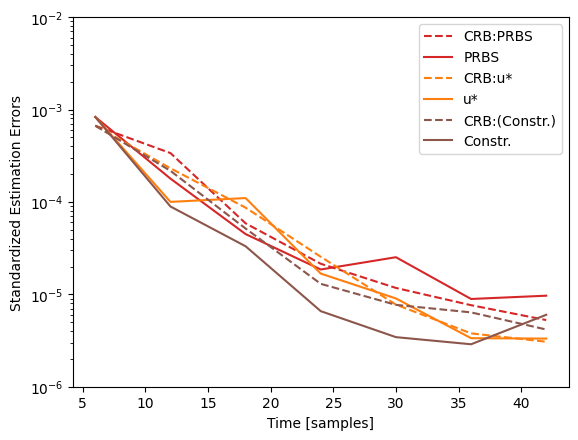

In [707]:
norm_theta = (true_theta**2).sum()



plt.yscale('log')
plt.plot(_rngS400,theta_crbsS407.mean(axis=0),c='C3',label='CRB:PRBS',linestyle='dashed')
plt.plot(_rngS400,theta_msesS407.mean(axis=0),c='C3', label='PRBS',linestyle='solid')


plt.plot(_rngS400,theta_crbsS4054.mean(axis=0),c='C1',label='CRB:u*',linestyle='dashed')
plt.plot(_rngS400,theta_msesS4054.mean(axis=0),c='C1',label='u*',linestyle='solid')


#plt.plot(_rngS400,theta_crbsS4041.mean(axis=0)/norm_theta,c='C5',label='CRB:u*(Constr.)',linestyle='dashed')
#plt.plot(_rngS400,theta_msesS4041.mean(axis=0)/norm_theta,c='C5',label='u*(Constr.)',linestyle='solid')


plt.plot(_rngS400,theta_crbsS4042.mean(axis=0),c='C5',label='CRB:(Constr.)',linestyle='dashed')
plt.plot(_rngS400,theta_msesS4042.mean(axis=0),c='C5',label='Constr.',linestyle='solid')


#plt.plot(_rngS400,theta_crbsS40420.mean(axis=0),c='C8',label='CRB:u*(Constr.scipy)',linestyle='dashed')
#plt.plot(_rngS400,theta_msesS40420.mean(axis=0),c='C8',label='u*(Constr.scipy)',linestyle='solid')

plt.ylim(1e-6,1e-2)

plt.xlabel('Time [samples]')
plt.ylabel('Standardized Estimation Errors')
plt.legend()

#plt.show()
plt.savefig('plots/watertank_err.pdf')

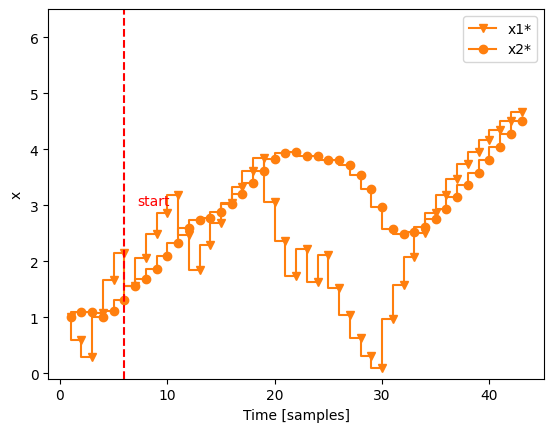

In [694]:
plt.xlabel('Time [samples]')
plt.ylabel('x')
plt.ylim(-0.1,6.5)
plt.step(range(1,1+T),xsS4054[0,0][:T],c='C1',marker='v',label='x1*')
plt.step(range(1,1+T),xsS4054[0,1][:T],c='C1',marker='o',label='x2*')
plt.plot([block_size,block_size],[-0.1,6.5],linestyle='dashed',c='red')
plt.text(x=7.2,y=3.,s='start',c='red')
plt.legend()
plt.savefig('plots/watertank_output_star.pdf')

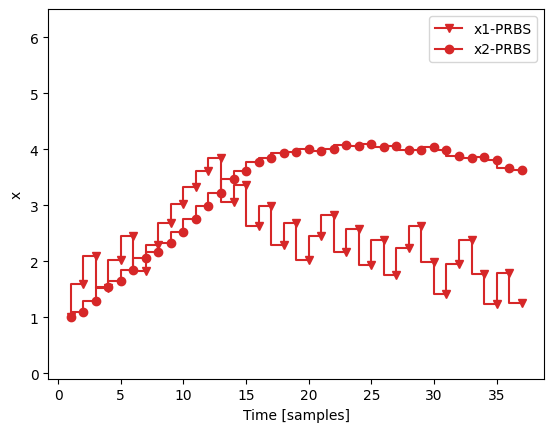

In [376]:
plt.xlabel('Time [samples]')
plt.ylabel('x')
plt.ylim(-0.1,6.5)
plt.step(range(1,1+T),xsS407[0,0][:T],c='C3',marker='v',label='x1-PRBS')
plt.step(range(1,1+T),xsS407[0,1][:T],c='C3',marker='o',label='x2-PRBS')
plt.legend()
plt.savefig('plots/watertank_output_prbs.pdf')


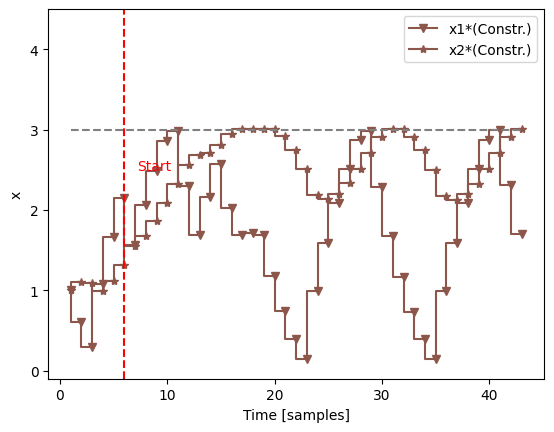

In [708]:
plt.xlabel('Time [samples]')
plt.ylabel('x')
plt.ylim(-0.1,4.5)
plt.step(range(1,T+1),xsS4042[0,0][:T],c='C5',marker='v',label='x1*(Constr.)')
plt.step(range(1,T+1),xsS4042[0,1][:T],c='C5',marker='*',label='x2*(Constr.)')
plt.plot([1,T],[3,3],c='gray',linestyle='dashed')
plt.plot([block_size,block_size],[-0.1,4.5],linestyle='dashed',c='red')
plt.text(x=7.2,y=2.5,s='Start',c='red')
plt.legend()
plt.savefig('plots/watertank_output_c.pdf')



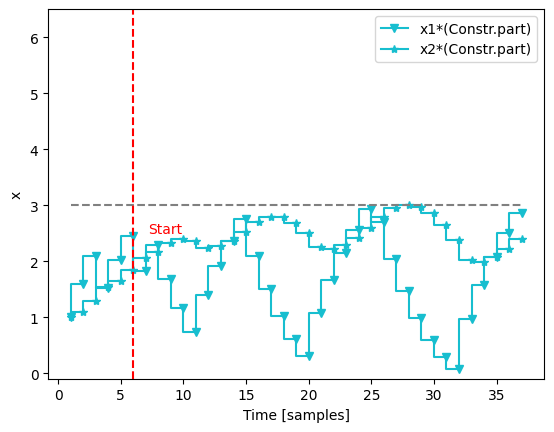

In [68]:
plt.xlabel('Time [samples]')
plt.ylabel('x')
plt.ylim(-0.1,6.5)
plt.step(range(1,T+1),xsS4042[0,0][:T],c='C9',marker='v',label='x1*(Constr.part)')
plt.step(range(1,T+1),xsS4042[0,1][:T],c='C9',marker='*',label='x2*(Constr.part)')
plt.plot([1,T],[3,3],c='gray',linestyle='dashed')
plt.plot([block_size,block_size],[-0.1,6.5],linestyle='dashed',c='red')
plt.text(x=7.2,y=2.5,s='Start',c='red')
plt.legend()



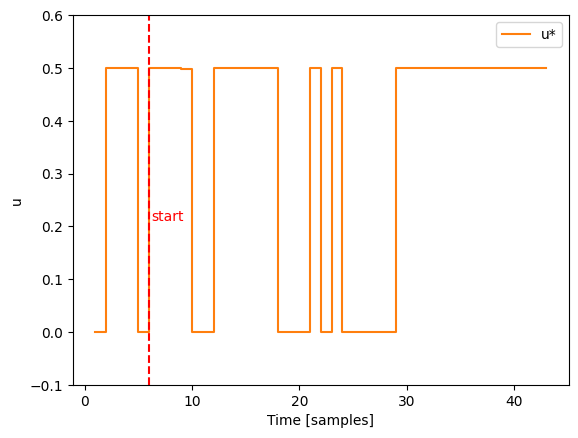

In [695]:
plt.xlabel('Time [samples]')
plt.ylim(-0.1,0.6)
plt.ylabel('u')
plt.step(range(1,T+1),usS4054[0][0,:T],c='C1',label='u*')
plt.plot([block_size,block_size],[-0.1,0.6],linestyle='dashed',c='red')
plt.text(x=6.2,y=.21,s='start',c='red')
plt.legend()

plt.savefig('plots/watertank_u_star.pdf')


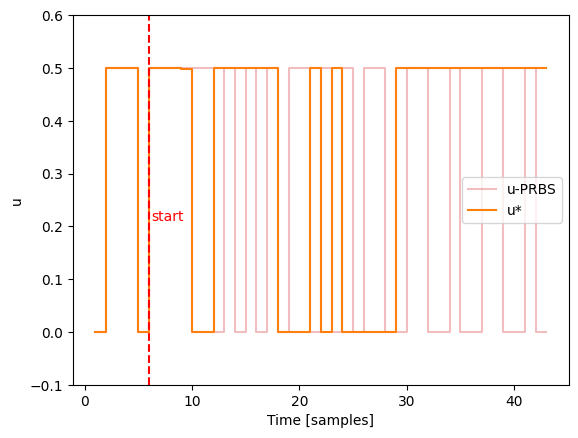

In [697]:
plt.xlabel('Time [samples]')
plt.ylim(-0.1,0.6)
plt.ylabel('u')
plt.step(range(1,T+1),usS407[0][0,:T],c='C3',alpha=0.3,label='u-PRBS')
plt.step(range(1,T+1),usS4054[0][0,:T],c='C1',label='u*')
plt.plot([block_size,block_size],[-0.1,0.6],linestyle='dashed',c='red')
plt.text(x=6.2,y=.21,s='start',c='red')
plt.legend()
plt.savefig('plots/watertank_u_prbs_star.pdf')

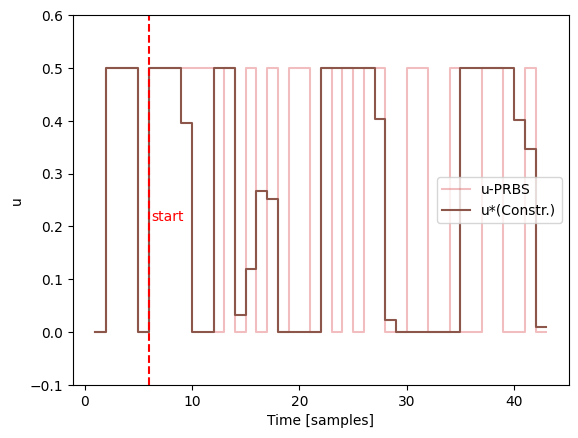

In [710]:
plt.xlabel('Time [samples]')
plt.ylim(-0.1,0.6)
plt.ylabel('u')
plt.step(range(1,T+1),usS407[0][0,:T],c='C3',alpha=0.3,label='u-PRBS')
plt.step(range(1,1+T),usS4042[1][0,:T],c='C5',label='u*(Constr.)')
plt.plot([block_size,block_size],[-0.1,0.6],linestyle='dashed',c='red')
plt.text(x=6.2,y=.21,s='start',c='red')
plt.legend()
plt.savefig('plots/watertank_u_c.pdf')


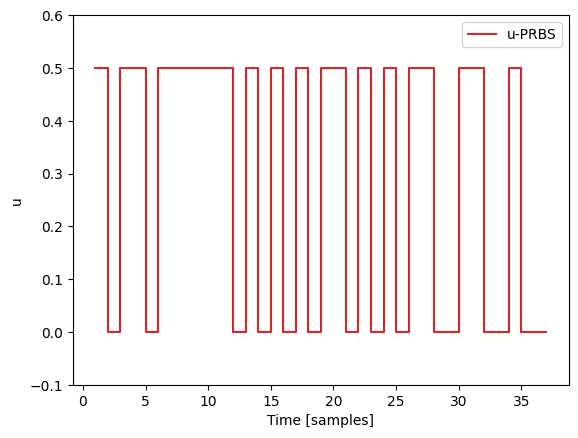

In [384]:
plt.xlabel('Time [samples]')
plt.ylim(-0.1,0.6)
plt.ylabel('u')
plt.step(range(1,1+T),usS407[0][0,:T],c='C3',label='u-PRBS')
plt.legend()
plt.savefig('plots/watertank_u_prbs.pdf')

In [573]:
class StateSpacePendulumModel(StateSpaceLinearModel):
    def __init__(self,u_range,gamma2,v_norm,dt):
        self.gamma2 = gamma2
        self.invGamma = torch.ones((1,1))/gamma2
        self.invGamma_np = np.ones((1,1))/gamma2
        self.v_norm = v_norm
        self.u_range = u_range
        self.dt = dt 
        self.H = torch.tensor([[1.,0.]])
        self.H2 = np.array([[1.,0.]])
        self.H3 = np.array([[0,0.,1.,0.]])
        self.CI = torch.eye(4)
        self.CI2 = np.eye(4)
        self.xx1 = torch.tensor([1.,self.dt])
        
    def transition(self,theta,x,u):
        dx1 = x[1,:]*self.dt
        dx2 = (theta[0,:]*torch.sin(x[0,:]) + theta[1,:]*u[0,:])*self.dt 
        dx = torch.vstack([dx1,dx2])
        return x+dx
    
    def transition_np(self,theta,x,u):
        dx1 = x[1,:]*self.dt
        dx2 = (theta[0,:]*np.sin(x[0,:]) + theta[1,:]*u[0,:])*self.dt
        dx = np.vstack([dx1,dx2])
        return x+dx
    
    def dxx(self,theta,x,u): 
        x21 = theta[0,0]*torch.cos(x[0,0])*self.dt
        x22 = torch.tensor(1)
        return torch.vstack([self.xx1,torch.hstack([x21,x22])])
    
    def dxx_np(self,theta,x,u):
        return np.array([[1.,self.dt],[theta[0,0]*np.cos(x[0,0])*self.dt,1.]])
        
    def dxtheta(self,theta,x,u): 
        xw21 = torch.sin(x[0,0])*self.dt
        xw22 = u[0,0]*self.dt
        return torch.vstack([torch.zeros(2),torch.hstack([xw21,xw22])])
    
    def dxtheta_np(self,theta,x,u):
        return np.array([[0.,0.],[np.sin(x[0,0])*self.dt,u[0,0]*self.dt]])
    
    def control_criterion_np(self, uk, theta, x0,fim_prev,C_prev):
        I_ = self.fim_np(theta,x0,uk)[0]
        I =  I_@C_prev + self.CI2
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        I2 = A-B@np.linalg.inv(D)@C
        return np.trace(np.linalg.inv(I2))
    
    def control_criterion(self, uk, theta, x0,fim_prev,C_prev):
        I_ = self.fim(theta,x0,uk)[0]
        I =  I_@C_prev + self.CI
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        I2 = A-B@torch.linalg.inv(D)@C
        return torch.trace(torch.linalg.inv(I2))
    
    
class StateSpacePendulumModel2(StateSpacePendulumModel):
    def control_criterion_np(self, uk, theta, x0,fim_prev,C_prev):
        I_ = self.fim_np(theta,x0,uk)[0]
        I =  I_ + fim_prev #I_@C_prev + self.CI2
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        I2 = A-B@np.linalg.inv(D)@C
        return np.trace(np.linalg.inv(I2))
    
    def control_criterion(self, uk, theta, x0,fim_prev,C_prev):
        I_ = self.fim(theta,x0,uk)[0]
        I =  I_ + fim_prev #I_@C_prev + self.CI
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        I2 = A-B@torch.linalg.inv(D)@C
        return torch.trace(torch.linalg.inv(I2))
    
class StateSpacePendulumModel3(StateSpacePendulumModel):
    def control_criterion_np(self, uk, theta, x0,fim_prev,C_prev):
        I_ = self.fim_np(theta,x0,uk)[0]
        I =  I_ + fim_prev #I_@C_prev + self.CI
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        I2 = A-B@np.linalg.inv(D)@C
        
        J_inv= np.linalg.inv(I2@C_prev[:M,:M])
        return np.trace(J_inv)
    
    def control_criterion(self, uk, theta, x0,fim_prev,C_prev):
        I_ = self.fim(theta,x0,uk)[0]
        I =  I_ + fim_prev #I_@C_prev + self.CI
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        I2 = A-B@torch.linalg.inv(D)@C
        J_inv= torch.linalg.inv(I2@C_prev[:M,:M])
        return torch.trace(J_inv)
    
class BarrierPendulumModel(StateSpacePendulumModel):
    def __init__(self,u_range,gamma2,v_norm,dt,y_range):
        self.y_range = y_range
        super().__init__(u_range,gamma2,v_norm,dt)
        
    def barrier_term(self,yk):
        y_dim,K = yk.shape
        b = 0
        for i in range(y_dim):
            l =1+torch.maximum(torch.zeros((y_dim,K)),torch.tensor(self.y_range[i,0])-yk[i,:])#%(2*np.pi)
            u =1+torch.maximum(torch.zeros((y_dim,K)),yk[i,:]-torch.tensor(self.y_range[i,1]))#%(2*np.pi)
            b+=(torch.exp(l).sum()+torch.exp(u).sum())
        return b
    
    def barrier_term_np(self,yk):
        y_dim,K = yk.shape
        b = 0
        for i in range(y_dim):
            l =1+10*np.maximum(np.zeros((y_dim,K)),self.y_range[i,0])-yk[i,:]%(2*np.pi)
            u =1+10*np.maximum(np.zeros((y_dim,K)),yk[i,:]%(2*np.pi)-self.y_range[i,1])
            b+=(np.exp(l).sum()+np.exp(u).sum())
        return b
    
    def control_criterion(self, uk, theta, x0,fim_prev,C_prev):
        I_,_,_,_,yk = self.fim(theta,x0,uk)
        I = I_@C_prev+self.CI
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        I2 = A-B@torch.linalg.inv(D)@C
        return torch.trace(torch.linalg.inv(I2))+self.barrier_term(yk)
    
    def control_criterion_np(self, uk, theta, x0,C_prev):
        I_,yk = self.fim_np(theta,x0,uk)
        I =  I_@C_prev + self.CI2
        M = theta.shape[0]
        A = I[:M,:M]
        B = I[:M,M:]
        C = I[M:,:M]
        D = I[M:,M:]
        I2 = A-B@np.linalg.inv(D)@C
        return np.trace(np.linalg.inv(I2))+self.barrier_term_np(yk)
    

In [574]:
def evaluatorS600(xs,theta,C_prev,ys,us,u_test,y_test):
    amplitude = 35
    dt = 0.5
    gamma2 = (lambda_true**2)*(1e-2)
    v_norm = q_alpha_d(4)
    model = StateSpacePendulumModel([-amplitude,amplitude],gamma2,v_norm,dt) 
    T_min = 0
    block_size = 7
    N = xs.shape[1]
    
    print('true x',xs,'true u',us,'true y',ys, 'theta',theta)

    
            
    if N<=T_min:#full mle
        C = np.linalg.pinv(model.fim(torch.tensor(theta),torch.tensor(xs[:,[0]]),torch.tensor(us))[0].numpy()+np.eye(C_prev.shape[0])*1e-3)
        x_prop,C_prev = propogate_x(theta,xs[:,[0]],model.transition_np,us,C)
    else:
        #if N<4:
        C = np.linalg.pinv(model.fim(torch.tensor(theta),torch.tensor(xs[:,[-block_size]]),torch.tensor(us[:,-block_size:]))[0].numpy()+np.linalg.pinv(C_prev))
        print('supposed C',C)
        #J_ = torch.tensor(C)
        #x_ = torch.tensor(xs[:,[-block_size]])
        #for i in range(block_size):
        #    j = -block_size+i
        #    u_curr = torch.tensor(us[:,[j]])
        #    wx_ = torch.vstack([torch.tensor(theta),x_])     
        #    jac_prev = torch.autograd.functional.jacobian(lambda wx_prev:torch.vstack([wx_prev[:theta.shape[0]],model.transition(wx_prev[:theta.shape[0]],wx_prev[theta.shape[0]:],u_curr)]),wx_).squeeze(1).squeeze(-1)
        #    J_ = jac_prev@J_@jac_prev.T
        #    x_ = model.transition(torch.tensor(theta),x_,u_curr).clone().detach()
        #C_prev =J_.detach().numpy()
        x_prop,C_prev = propogate_x(theta,xs[:,[-block_size]],model.transition_np,us[:,-block_size:],C)
        
    #I = np.linalg.pinv(C)
    M = theta.shape[0]
    #Ia = I[:M,:M]
    #Ib = I[:M,M:]
    #Ic = I[M:,:M]
    #Id = I[M:,M:]
    C_theta = C[:M,:M]#np.linalg.pinv(Ia-Ib@np.linalg.pinv(Id)@Ic)  #np.linalg.inv(Ia)#
    tr_crb = np.abs(np.trace(C_theta@np.diag(1/(theta.flatten()**2))))
    
    
                     
    mse = 0
    x_ = xs[:,[0]]
    Hn = model.H.numpy()
    for i in range(u_test.shape[0]):
        mse += ((y_test[:,[i]]-Hn@x_)**2)
        x_ = model.transition_np(theta,x_,u_test[:,[i]])
                
    mse/= u_test.shape[0]
    return tr_crb,mse,C_prev      

def estimatorS600(x_init0,theta0,invC0,gamma0,invS0,ys,us,t):
    print('estimator',us,ys)
    amplitude = 35
    dt = 0.5
    v_norm = q_alpha_d(4)
    model = StateSpacePendulumModel([-amplitude,amplitude],gamma0,v_norm,dt)
    
    T_min = 0
    block_size = 7
    Gamma = np.eye(1)*gamma0
    
    N = ys.shape[1]
    print('t=',t)
    

    
    if t==1:
        lr = 5e-2
        n_iter = 10000
        x_init,theta,invC = recursive_mle(model,ys,us,T_min,block_size,theta0,x_init0,invC0,Gamma,lr=lr,n_iter=n_iter)
        print('second try',theta)
        
        x_init,theta,invC = recursive_mle_opt(model,ys,us,block_size,theta,x_init0,invC0,0.1,600)
        gamma1,invS1 = recursive_mle_sigma(model,ys,us,block_size,theta,x_init,invC,gamma0,invS0,n_iter=200)
        #lr = 2e-4
        #n_iter = 80000
        #x_init,theta,invC = recursive_mle(model,ys,us,T_min,block_size,theta,x_init0,invC0,Gamma,lr=lr,n_iter=n_iter)
#     elif t<6:
    
#         lr = 1./np.sqrt(np.diag(invC0).max())
#         n_iter = 80000
#         #C0 = np.linalg.pinv(invC0)
#         #C0 += np.eye(4)*1e-8
#         #invC0 = np.linalg.inv(C0)
#         x_init,theta,invC = recursive_mle(model,ys,us,T_min,block_size,theta0,x_init0,invC0,Gamma,lr=lr,n_iter=n_iter)
    else:
        x_init,theta,invC = recursive_mle_opt(model,ys,us,block_size,theta0,x_init0,invC0,0.1,600)
        gamma1,invS1 = recursive_mle_sigma(model,ys,us,block_size,theta,x_init,invC,gamma0,invS0,n_iter=200)
        # lr = 1./np.sqrt(np.diag(invC0).max())
        # n_iter = 90000
        # #C0 = np.linalg.pinv(invC0)
        # #C0 += np.eye(4)*1e-8
        # #invC0 = np.linalg.inv(C0)
        # x_init,theta,invC = recursive_mle(model,ys,us,T_min,block_size,theta0,x_init0,invC0,Gamma,lr=lr,n_iter=n_iter)
    
    
    print(gamma1,invS1)
    print('estimation theta',theta,np.linalg.inv(invC))
    return x_init,theta,invC,gamma1,invS1

In [604]:
T = 64
amplitude = 35
dt = 0.5
simulator = simulate_nonlinear13
evaluator = evaluatorS600 
estimator = estimatorS600
gamma2 = (lambda_true**2)*(1e-2)
QS600 = np.eye(1)*gamma2
v_norm = q_alpha_d(4)
model = StateSpacePendulumModel2([-amplitude,amplitude],gamma2,v_norm,dt)
#dx1 = x2
#dx2 = theta1*sin(x1)+theta2*u
#y = x1     
repeat = 1
true_theta = np.array([[-1],[0.1]])
theta0 = np.ones((2,1))
invC0 = np.eye(4)*1e-4
gamma0 = np.ones((1,1))*(lambda_true**2)*(1e-2)
invS0 = np.eye(1)*1e20
x_init0 = np.ones((2,1))

US600_T = lambda seed:np.roll(scaled_PRBS_RA(seed,100,scale=amplitude,dt=dt),9)
US602 = lambda seed:np.roll(scaled_PRBS_RA(seed,100,scale=amplitude,dt=dt),9)
US601 = lambda seed:np.roll(scaled_PRBS(100,scale=amplitude,seed=seed,dt=dt),9)

T_min = 0
block_size = 7
_rngS600 = list(range(block_size,T,1))

def US600(seed):
    K = 6
    model = StateSpacePendulumModel([-amplitude,amplitude],gamma0,v_norm,dt) 
    simulator = simulate_nonlinear13
    estimator = estimatorS600
    us = US601(seed)[:block_size]
    return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS600,T_min,block_size,weight='full',dt=dt,seed=seed,minmax=False,n_iter=40000)
    #return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS600,block_size,dt=dt,seed=seed,n_iter=200)

def US6000(seed):
    K = 6
    model = StateSpacePendulumModel([-amplitude,amplitude],gamma0,v_norm,dt) 
    simulator = simulate_nonlinear13
    estimator = estimatorS600
    us = US601(seed)[:block_size]
    #return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS600,T_min,block_size,weight='full',dt=dt,seed=seed,minmax=False,n_iter=40000)
    return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS600,block_size,weight='full',dt=dt,seed=seed,n_iter=200)

def US6001(seed):
    K = 6
    model = StateSpacePendulumModel2([-amplitude,amplitude],gamma0,v_norm,dt) 
    simulator = simulate_nonlinear13
    estimator = estimatorS600
    us = US601(seed)[:block_size]
    #return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,simulator,QS600,T_min,block_size,dt=dt,seed=seed,minmax=False,lr_desc=1e-3,n_iter=40000)
    return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS600,block_size,dt=dt,seed=seed,n_iter=200)

#full
def US6002(seed):
    K = 6
    model = StateSpacePendulumModel3([-amplitude,amplitude],gamma0,v_norm,dt) 
    simulator = simulate_nonlinear13
    estimator = estimatorS600
    us = US601(seed)[:block_size]
    return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS600,T_min,block_size,weight='full',dt=dt,seed=seed,minmax=False,lr_desc=1e-3,n_iter=30000)
    #return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS600,block_size,weight='full',dt=dt,seed=seed,n_iter=200)

def US60020(seed):
    K = 6
    model = StateSpacePendulumModel3([-amplitude,amplitude],gamma0,v_norm,dt) 
    simulator = simulate_nonlinear13
    estimator = estimatorS600
    us = US601(seed)[:block_size]
    #return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS600,T_min,block_size,weight='full',dt=dt,seed=seed,minmax=False,lr_desc=1e-3,n_iter=30000)
    return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS600,block_size,weight='full',dt=dt,seed=seed,n_iter=200)


#diag
def US6006(seed):
    K = 6
    model = StateSpacePendulumModel3([-amplitude,amplitude],gamma0,v_norm,dt) 
    simulator = simulate_nonlinear13
    estimator = estimatorS600
    us = US601(seed)[:block_size]
    return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS600,T_min,block_size,weight='diag',dt=dt,seed=seed,minmax=False,lr_desc=1e-3,n_iter=30000)
    #return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS600,block_size,diag=True,dt=dt,seed=seed,n_iter=200)
    
def US60060(seed):
    K = 6
    model = StateSpacePendulumModel3([-amplitude,amplitude],gamma0,v_norm,dt) 
    simulator = simulate_nonlinear13
    estimator = estimatorS600
    us = US601(seed)[:block_size]
    #return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS600,T_min,block_size,weight='diag',dt=dt,seed=seed,minmax=False,lr_desc=1e-3,n_iter=40000)
    return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS600,block_size,weight='diag',dt=dt,seed=seed,n_iter=200)

#divide
def US60070(seed):
    K = 6
    model = StateSpacePendulumModel2([-amplitude,amplitude],gamma0,v_norm,dt) 
    simulator = simulate_nonlinear13
    estimator = estimatorS600
    us = US601(seed)[:block_size]
    #return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS600,T_min,block_size,weight='diag',dt=dt,seed=seed,minmax=False,lr_desc=1e-3,n_iter=40000)
    return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS600,block_size,weight='full',dt=dt,seed=seed,n_iter=200)


def US604(seed):
    K = 6
    model = BarrierPendulumModel([-amplitude,amplitude],gamma0,v_norm,dt,np.array([[np.pi*3/4,np.pi*5/4]])) 
    simulator = simulate_nonlinear13
    estimator = estimatorS600
    us = US601(seed)[:block_size]
    return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS600,T_min,block_size,dt=dt,seed=seed,minmax=False,lr_desc=1e-3,n_iter=30000)
    #return generate_uk_ss_opt(model,estimator,T,K,us,theta0,x_init0,invC0,simulator,QS600,block_size,dt=dt,seed=seed,n_iter=200)

def US605(seed):
    K = 6
    model = BarrierPendulumModel([-amplitude,amplitude],gamma0,v_norm,dt,np.array([[np.pi*3/4,np.pi]])) 
    simulator = simulate_nonlinear13
    estimator = estimatorS600
    us = US601(seed)[:block_size]
    return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS600,T_min,block_size,dt=dt,seed=seed,minmax=False,lr_desc=1e-3,n_iter=30000)

def US606(seed):
    K = 6
    model = BarrierPendulumModel([-amplitude,amplitude],gamma0,v_norm,dt,np.array([[np.pi,np.pi*5/4]])) 
    simulator = simulate_nonlinear13
    estimator = estimatorS600
    us = US601(seed)[:block_size]
    return generate_uk_ss(model,estimator,T,K,us,theta0,x_init0,invC0,gamma0,invS0,simulator,QS600,T_min,block_size,dt=dt,seed=seed,minmax=False,lr_desc=1e-3,n_iter=30000)
def US6041(seed):
    return usS604[0,0,:]

In [605]:


uk = np.array([35,35,-35,-35,35,-35]).reshape(-1,1)
C_prev = np.random.randn(4,4)
C_prev = C_prev.T@C_prev
fim_prev = np.linalg.inv(C_prev)
print(C_prev)

[[ 0.15534836  0.01529969  0.00298967  0.15929159]
 [ 0.01529969  0.36138284 -0.91148128  0.83650287]
 [ 0.00298967 -0.91148128  2.34802655 -2.15064871]
 [ 0.15929159  0.83650287 -2.15064871  2.39917693]]


In [606]:

model_decomposed = StateSpacePendulumModel4([-amplitude,amplitude],gamma0,v_norm,dt) 
model_decomposed.control_criterion_np(uk,true_theta,np.array([[np.pi],[0]]),fim_prev,C_prev)

0.027366352654268154

In [474]:
model_partdecom= StateSpacePendulumModel5([-amplitude,amplitude],gamma0,v_norm,dt) 
model_partdecom.control_criterion_np(uk,true_theta,np.array([[np.pi],[0]]),fim_prev,C_prev)

14.5672987429095

In [475]:
model_full= StateSpacePendulumModel6([-amplitude,amplitude],gamma0,v_norm,dt) 
model_full.control_criterion_np(uk,true_theta,np.array([[np.pi],[0]]),fim_prev,C_prev)

1.9999999999999998

In [476]:
model0 = StateSpacePendulumModel([-amplitude,amplitude],gamma0,v_norm,dt) 
model0.control_criterion_np(uk,true_theta,np.array([[np.pi],[0]]),fim_prev,C_prev)

2.0

In [477]:
model_diag = StateSpacePendulumModel7([-amplitude,amplitude],gamma0,v_norm,dt) 
model_diag.control_criterion_np(uk,true_theta,np.array([[np.pi],[0]]),fim_prev,np.diag(np.diag(C_prev))[:2,:2])

1.8584268524192855

In [455]:
model_eq8= StateSpacePendulumModel3([-amplitude,amplitude],gamma0,v_norm,dt) 
model_eq8.control_criterion_np(uk,true_theta,np.array([[np.pi],[0]]),fim_prev,np.diag(np.diag(C_prev))[:2,:2])

1.3328259030357112

In [618]:
#presdS601,theta_crbsS601,theta_msesS601,powerS601,usS601,ysS601,xsS601,nsS601 = monte_carlo_ss(US601,US600_T,model,estimator,evaluator,simulator,100,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS600,QS600,a=amplitude,dt=dt)

In [617]:
with open('plotsdata/S601.pk','wb') as f:
    pickle.dump((presdS601,theta_crbsS601,theta_msesS601,powerS601,usS601,ysS601,xsS601,nsS601),f)

In [107]:
with open('plotsdata/S601.pk','rb') as f:
    (presdS601,theta_crbsS601,theta_msesS601,powerS601,usS601,ysS601,xsS601,nsS601) = pickle.load(f)

In [527]:
#presdS602,theta_crbsS602,theta_msesS602,powerS602,usS602,ysS602,xsS602,nsS602 = monte_carlo_ss(US602,US600_T,model,estimator,evaluator,simulator,repeat,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS600,QS600,a=amplitude,dt=dt)

In [528]:
#with open('plotsdata/S602-2.pk','wb') as f:
#    pickle.dump((presdS602,theta_crbsS602,theta_msesS602,powerS602,usS602,ysS602,xsS602,nsS602),f)

In [607]:
#presdS600,theta_crbsS600,theta_msesS600,powerS600,usS600,ysS600,xsS600,nsS600 = monte_carlo_ss(US600,US600_T,model,estimator,evaluator,simulator,1,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS600,QS600,a=amplitude,dt=dt)

In [507]:
#presdS6000,theta_crbsS6000,theta_msesS6000,powerS6000,usS6000,ysS6000,xsS6000,nsS6000 = monte_carlo_ss(US6000,US600_T,model,estimator,evaluator,simulator,100,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS600,QS600,a=amplitude,dt=dt)

In [506]:
with open('plotsdata/S6000.pk','wb') as f:
    pickle.dump((presdS6000,theta_crbsS6000,theta_msesS6000,powerS6000,usS6000,ysS6000,xsS6000,nsS6000),f)

In [610]:
#presdS6001,theta_crbsS6001,theta_msesS6001,powerS6001,usS6001,ysS6001,xsS6001,nsS6001 = monte_carlo_ss(US6001,US600_T,model,estimator,evaluator,simulator,1,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS600,QS600,a=amplitude,dt=dt)

In [611]:
#presdS6002,theta_crbsS6002,theta_msesS6002,powerS6002,usS6002,ysS6002,xsS6002,nsS6002 = monte_carlo_ss(US6002,US600_T,model,estimator,evaluator,simulator,1,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS600,QS600,a=amplitude,dt=dt)

In [620]:
#presdS60020,theta_crbsS60020,theta_msesS60020,powerS60020,usS60020,ysS60020,xsS60020,nsS60020 = monte_carlo_ss(US60020,US600_T,model,estimator,evaluator,simulator,100,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS600,QS600,a=amplitude,dt=dt)

In [619]:
with open('plotsdata/S60020.pk','wb') as f:
    pickle.dump((presdS60020,theta_crbsS60020,theta_msesS60020,powerS60020,usS60020,ysS60020,xsS60020,nsS60020),f)

In [120]:
#presdS6003,theta_crbsS6003,theta_msesS6003,powerS6003,usS6003,ysS6003,xsS6003,nsS6003 = monte_carlo_ss(US6003,US600_T,model,estimator,evaluator,simulator,2,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS600,QS600,a=amplitude,dt=dt)

In [603]:
presdS60070,theta_crbsS60070,theta_msesS60070,powerS60070,usS60070,ysS60070,xsS60070,nsS60070 = monte_carlo_ss(US60070,US600_T,model,estimator,evaluator,simulator,100,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS600,QS600,a=amplitude,dt=dt)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/54 [00:00<?, ?it/s]

estimator [[ 35.  35.  35.  35. -35.  35.  35.]] [[ 3.14194669  3.14158769  4.01606106  5.76431609  8.58349724 12.39977185
  15.15387631]]
t= 1
N= 7
F1 [[ 6.24830219e+05 -1.19247448e+08 -3.30152386e+06 -3.83910589e+06]
 [-1.19247448e+08  2.41614574e+10  7.16786614e+08  8.19490988e+08]
 [-3.30152386e+06  7.16786614e+08  2.53248862e+07  2.65070647e+07]
 [-3.83910589e+06  8.19490988e+08  2.65070647e+07  2.94498816e+07]] [[ 1.03818252e-04  1.00002447e-06  3.29537931e-06 -1.72595808e-05]
 [ 1.00002447e-06  1.05740088e-08  4.51031296e-08 -2.04471335e-07]
 [ 3.29537931e-06  4.51031296e-08  9.76094429e-07 -1.70403728e-06]
 [-1.72595808e-05 -2.04471335e-07 -1.70403728e-06  5.00749328e-06]]
F2 [[ 6.24912877e+05 -1.19212800e+08 -3.29636620e+06 -3.83703665e+06]
 [-1.19212800e+08  2.41609568e+10  7.16741115e+08  8.19449103e+08]
 [-3.29636620e+06  7.16741115e+08  2.53205525e+07  2.65031918e+07]
 [-3.83703665e+06  8.19449103e+08  2.65031918e+07  2.94463662e+07]] [[ 9.98715688e-05  9.59833506e-07  2.9


  0%|                                                          | 0/54 [00:00<?, ?it/s]

true x [[ 3.14159265  3.14159265  4.01659265  5.76659265  8.58347853 12.39884448
  15.15283298]
 [ 0.          1.75        3.5         5.63377175  7.6307319   5.50797699
   7.34134881]] true u [[ 35.  35.  35.  35. -35.  35.  35.]] true y [[ 3.14194669  3.14158769  4.01606106  5.76431609  8.58349724 12.39977185
  15.15387631]] theta [[-1. ]
 [ 0.1]]
supposed C [[ 1.01192677e-04  1.02769531e-06  2.77176854e-06 -1.64648923e-05]
 [ 1.02769531e-06  1.13845701e-08  4.02263075e-08 -2.04899070e-07]
 [ 2.77176854e-06  4.02263075e-08  9.61749340e-07 -1.66187480e-06]
 [-1.64648923e-05 -2.04899070e-07 -1.66187480e-06  4.93898977e-06]]
estimator [[ 35.  35.  35.  35. -35.  35.  35.]] [[ 3.14194669  3.14158769  4.01606106  5.76431609  8.58349724 12.39977185
  15.15387631]]
t= 1
N= 7
F1 [[ 6.24830219e+05 -1.19247448e+08 -3.30152386e+06 -3.83910589e+06]
 [-1.19247448e+08  2.41614574e+10  7.16786614e+08  8.19490988e+08]
 [-3.30152386e+06  7.16786614e+08  2.53248862e+07  2.65070647e+07]
 [-3.83910589e+

...

estimator [[ 35.  35.  35.  35. -35.  35.  35.]] [[ 3.14189737  3.14055267  4.0173431   5.76753322  8.58152749 12.3975423
  15.15296082]]
t= 1
N= 7
F1 [[ 6.24714168e+05 -1.19244682e+08 -3.27479938e+06 -3.83265036e+06]
 [-1.19244682e+08  2.41581869e+10  7.10735038e+08  8.17891329e+08]
 [-3.27479938e+06  7.10735038e+08  2.49620802e+07  2.62546541e+07]
 [-3.83265036e+06  8.17891329e+08  2.62546541e+07  2.93453453e+07]] [[ 1.03665441e-04  9.97351988e-07  3.37833505e-06 -1.72807362e-05]
 [ 9.97351988e-07  1.05364468e-08  4.59318678e-08 -2.04498950e-07]
 [ 3.37833505e-06  4.59318678e-08  9.80810744e-07 -1.71646119e-06]
 [-1.72807362e-05 -2.04498950e-07 -1.71646119e-06  5.01244718e-06]]
F2 [[ 6.24845017e+05 -1.19211171e+08 -3.26797988e+06 -3.83004003e+06]
 [-1.19211171e+08  2.41579720e+10  7.10702863e+08  8.17863099e+08]
 [-3.26797988e+06  7.10702863e+08  2.49585686e+07  2.62515687e+07]
 [-3.83004003e+06  8.17863099e+08  2.62515687e+07  2.93425897e+07]] [[ 1.00145693e-04  9.61220766e-07  2.92


  0%|                                                          | 0/54 [00:00<?, ?it/s]

true x [[ 3.14159265  3.14159265  4.01659265  5.76659265  8.58347853 12.39884448
  15.15283298]
 [ 0.          1.75        3.5         5.63377175  7.6307319   5.50797699
   7.34134881]] true u [[ 35.  35.  35.  35. -35.  35.  35.]] true y [[ 3.14189737  3.14055267  4.0173431   5.76753322  8.58152749 12.3975423
  15.15296082]] theta [[-1. ]
 [ 0.1]]
supposed C [[ 1.01192677e-04  1.02769531e-06  2.77176854e-06 -1.64648923e-05]
 [ 1.02769531e-06  1.13845701e-08  4.02263075e-08 -2.04899070e-07]
 [ 2.77176854e-06  4.02263075e-08  9.61749340e-07 -1.66187480e-06]
 [-1.64648923e-05 -2.04899070e-07 -1.66187480e-06  4.93898977e-06]]
estimator [[ 35.  35.  35.  35. -35.  35.  35.]] [[ 3.14189737  3.14055267  4.0173431   5.76753322  8.58152749 12.3975423
  15.15296082]]
t= 1
N= 7
F1 [[ 6.24714168e+05 -1.19244682e+08 -3.27479938e+06 -3.83265036e+06]
 [-1.19244682e+08  2.41581869e+10  7.10735038e+08  8.17891329e+08]
 [-3.27479938e+06  7.10735038e+08  2.49620802e+07  2.62546541e+07]
 [-3.83265036e+06

  0%|                                                          | 0/54 [00:08<?, ?it/s]


KeyboardInterrupt: 

In [577]:
with open('plotsdata/S60070.pk','wb') as f:
    pickle.dump((presdS60070,theta_crbsS60070,theta_msesS60070,powerS60070,usS60070,ysS60070,xsS60070,nsS60070),f)

In [119]:
#presdS6005,theta_crbsS6005,theta_msesS6005,powerS6005,usS6005,ysS6005,xsS6005,nsS6005 = monte_carlo_ss(US6005,US600_T,model,estimator,evaluator,simulator,1,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS600,QS600,a=amplitude,dt=dt)

In [570]:
#presdS6006,theta_crbsS6006,theta_msesS6006,powerS6006,usS6006,ysS6006,xsS6006,nsS6006 = monte_carlo_ss(US6006,US600_T,model,estimator,evaluator,simulator,1,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS600,QS600,a=amplitude,dt=dt)

In [499]:
#presdS60060,theta_crbsS60060,theta_msesS60060,powerS60060,usS60060,ysS60060,xsS60060,nsS60060 = monte_carlo_ss(US60060,US600_T,model,estimator,evaluator,simulator,100,x_init0,theta0,invC0,gamma0,invS0,true_theta,T_min,block_size,_rngS600,QS600,a=amplitude,dt=dt)

In [ ]:
with open('plotsdata/S6006.pk','wb') as f:
    pickle.dump((presdS6006,theta_crbsS6006,theta_msesS6006,powerS6006,usS6006,ysS6006,xsS6006,nsS6006),f)

In [498]:
with open('plotsdata/S60060.pk','wb') as f:
    pickle.dump((presdS60060,theta_crbsS60060,theta_msesS60060,powerS60060,usS60060,ysS60060,xsS60060,nsS60060),f)

In [617]:
with open('plotsdata/S600.pk','wb') as f:
    pickle.dump((presdS600,theta_crbsS600,theta_msesS600,powerS600,usS600,ysS600,xsS600,nsS600),f)

In [244]:
with open('plotsdata/S600.pk','rb') as f:
    (presdS600,theta_crbsS600,theta_msesS600,powerS600,usS600,ysS600,xsS600,nsS600) = pickle.load(f)

In [616]:
with open('plotsdata/S6001.pk','wb') as f:
    pickle.dump((presdS6001,theta_crbsS6001,theta_msesS6001,powerS6001,usS6001,ysS6001,xsS6001,nsS6001),f)

In [116]:
with open('plotsdata/S6001.pk','rb') as f:
    (presdS6001,theta_crbsS6001,theta_msesS6001,powerS6001,usS6001,ysS6001,xsS6001,nsS6001) = pickle.load(f)

In [464]:
presdS6041,theta_crbsS6041,theta_msesS6041,powerS6041,usS6041,ysS6041,xsS6041,nsS6041 = monte_carlo_ss(US6041,US600_T,model,estimator,evaluator,simulator,repeat,x_init0,theta0,invC0,true_theta,T_min,block_size,_rngS600,QS600,a=amplitude,dt=dt)

  0%|          | 0/1 [00:00<?, ?it/s]


  0%|                                                                      | 0/54 [00:00<?, ?it/s]

true x [[ 3.14159265  3.14159265  4.01659265  5.76659265  8.58347853 12.39884448
  15.15283298]
 [ 0.          1.75        3.5         5.63377175  7.6307319   5.50797699
   7.34134881]] true u [[ 35.  35.  35.  35. -35.  35.  35.]] true y [[ 3.14194669  3.14158769  4.01606106  5.76431609  8.58349724 12.39977185
  15.15387631]] theta [[-1. ]
 [ 0.1]]
supposed C [[ 1.01192677e-04  1.02769531e-06  2.77176854e-06 -1.64648923e-05]
 [ 1.02769531e-06  1.13845701e-08  4.02263075e-08 -2.04899070e-07]
 [ 2.77176854e-06  4.02263075e-08  9.61749340e-07 -1.66187480e-06]
 [-1.64648923e-05 -2.04899070e-07 -1.66187480e-06  4.93898977e-06]]
estimator [[ 35.  35.  35.  35. -35.  35.  35.]] [[ 3.14194669  3.14158769  4.01606106  5.76431609  8.58349724 12.39977185
  15.15387631]]
t= 1
N= 7
F1 [[ 6.24830219e+05 -1.19247448e+08 -3.30152386e+06 -3.83910589e+06]
 [-1.19247448e+08  2.41614574e+10  7.16786614e+08  8.19490988e+08]
 [-3.30152386e+06  7.16786614e+08  2.53248862e+07  2.65070647e+07]
 [-3.83910589e+


  2%|█▏                                                            | 1/54 [00:18<16:23, 18.55s/it]

                    message: ['requested number of basinhopping iterations completed successfully']
                    success: False
                        fun: 0.7090920309422248
                          x: [-1.011e+00  9.995e-02  3.142e+00 -4.941e-04]
                        nit: 400
      minimization_failures: 36
                       nfev: 141325
                       njev: 28265
 lowest_optimization_result:  message: ABNORMAL_TERMINATION_IN_LNSRCH
                              success: False
                               status: 2
                                  fun: 0.7090920309422248
                                    x: [-1.011e+00  9.995e-02  3.142e+00
                                        -4.941e-04]
                                  nit: 45
                                  jac: [-2.303e-01  8.306e+01 -2.295e+00
                                        -3.282e+00]
                                 nfev: 445
                                 njev: 89
               

...

                    message: ['requested number of basinhopping iterations completed successfully']
                    success: True
                        fun: 265.7645397470755
                          x: [-9.990e-01  9.996e-02  3.935e+00 -1.969e-01]
                        nit: 1200
      minimization_failures: 9
                       nfev: 224295
                       njev: 44859
 lowest_optimization_result:  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
                              success: True
                               status: 0
                                  fun: 265.7645397470755
                                    x: [-9.990e-01  9.996e-02  3.935e+00
                                        -1.969e-01]
                                  nit: 31
                                  jac: [-1.376e+07 -4.749e+08  2.466e+07
                                        -3.323e+07]
                                 nfev: 300
                                 njev: 60
  


 80%|████████████████████████████████████████████████▌            | 43/54 [01:57<00:27,  2.48s/it]

                    message: ['requested number of basinhopping iterations completed successfully']
                    success: True
                        fun: 218.31659356342965
                          x: [-9.995e-01  9.992e-02  4.010e+00  6.987e-02]
                        nit: 400
      minimization_failures: 1
                       nfev: 82610
                       njev: 16522
 lowest_optimization_result:  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
                              success: True
                               status: 0
                                  fun: 218.31659356342965
                                    x: [-9.995e-01  9.992e-02  4.010e+00
                                         6.987e-02]
                                  nit: 37
                                  jac: [-3.753e+07 -3.515e+08  3.511e+07
                                        -4.227e+07]
                                 nfev: 320
                                 njev: 64
  


100%|█████████████████████████████████████████████████████████████| 54/54 [02:04<00:00,  2.30s/it]

                    message: ['requested number of basinhopping iterations completed successfully']
                    success: True
                        fun: 483.11457690041
                          x: [-9.976e-01  9.983e-02  4.309e+00  2.999e-01]
                        nit: 400
      minimization_failures: 1
                       nfev: 89410
                       njev: 17882
 lowest_optimization_result:  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
                              success: True
                               status: 0
                                  fun: 483.11457690041
                                    x: [-9.976e-01  9.983e-02  4.309e+00
                                         2.999e-01]
                                  nit: 50
                                  jac: [ 4.690e+07  4.044e+08 -3.124e+07
                                         4.315e+07]
                                 nfev: 400
                                 njev: 80
        

In [605]:
presdS604,theta_crbsS604,theta_msesS604,powerS604,usS604,ysS604,xsS604,nsS604 = monte_carlo_ss(US604,US600_T,model,estimator,evaluator,simulator,10,x_init0,theta0,invC0,true_theta,T_min,block_size,_rngS600,QS600,a=amplitude,dt=dt)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/54 [00:00<?, ?it/s]

estimator [[ 35.  35.  35.  35. -35.  35.  35.]] [[ 3.14194669  3.14158769  4.01606106  5.76431609  8.58349724 12.39977185
  15.15387631]]
t= 1
N= 7
F1 [[ 6.24830219e+05 -1.19247448e+08 -3.30152386e+06 -3.83910589e+06]
 [-1.19247448e+08  2.41614574e+10  7.16786614e+08  8.19490988e+08]
 [-3.30152386e+06  7.16786614e+08  2.53248862e+07  2.65070647e+07]
 [-3.83910589e+06  8.19490988e+08  2.65070647e+07  2.94498816e+07]] [[ 1.03818252e-04  1.00002447e-06  3.29537931e-06 -1.72595808e-05]
 [ 1.00002447e-06  1.05740088e-08  4.51031296e-08 -2.04471335e-07]
 [ 3.29537931e-06  4.51031296e-08  9.76094429e-07 -1.70403728e-06]
 [-1.72595808e-05 -2.04471335e-07 -1.70403728e-06  5.00749328e-06]]
F2 [[ 6.24912877e+05 -1.19212800e+08 -3.29636620e+06 -3.83703665e+06]
 [-1.19212800e+08  2.41609568e+10  7.16741115e+08  8.19449103e+08]
 [-3.29636620e+06  7.16741115e+08  2.53205525e+07  2.65031918e+07]
 [-3.83703665e+06  8.19449103e+08  2.65031918e+07  2.94463662e+07]] [[ 9.98715688e-05  9.59833506e-07  2.9


  0%|                                                                      | 0/54 [00:00<?, ?it/s]

true x [[ 3.14159265  3.14159265  4.01659265  5.76659265  8.58347853 12.39884448
  15.15283298]
 [ 0.          1.75        3.5         5.63377175  7.6307319   5.50797699
   7.34134881]] true u [[ 35.  35.  35.  35. -35.  35.  35.]] true y [[ 3.14194669  3.14158769  4.01606106  5.76431609  8.58349724 12.39977185
  15.15387631]] theta [[-1. ]
 [ 0.1]]
supposed C [[ 1.01192677e-04  1.02769531e-06  2.77176854e-06 -1.64648923e-05]
 [ 1.02769531e-06  1.13845701e-08  4.02263075e-08 -2.04899070e-07]
 [ 2.77176854e-06  4.02263075e-08  9.61749340e-07 -1.66187480e-06]
 [-1.64648923e-05 -2.04899070e-07 -1.66187480e-06  4.93898977e-06]]
estimator [[ 35.  35.  35.  35. -35.  35.  35.]] [[ 3.14194669  3.14158769  4.01606106  5.76431609  8.58349724 12.39977185
  15.15387631]]
t= 1
N= 7
F1 [[ 6.24830219e+05 -1.19247448e+08 -3.30152386e+06 -3.83910589e+06]
 [-1.19247448e+08  2.41614574e+10  7.16786614e+08  8.19490988e+08]
 [-3.30152386e+06  7.16786614e+08  2.53248862e+07  2.65070647e+07]
 [-3.83910589e+

...

                    message: ['requested number of basinhopping iterations completed successfully']
                    success: False
                        fun: 2.4496905586369535
                          x: [-1.000e+00  1.000e-01  4.882e+00 -2.580e+00]
                        nit: 400
      minimization_failures: 95
                       nfev: 156585
                       njev: 31317
 lowest_optimization_result:  message: ABNORMAL_TERMINATION_IN_LNSRCH
                              success: False
                               status: 2
                                  fun: 2.4496905586369535
                                    x: [-1.000e+00  1.000e-01  4.882e+00
                                        -2.580e+00]
                                  nit: 46
                                  jac: [-2.329e+02  7.339e+04  4.039e+01
                                        -2.249e+02]
                                 nfev: 445
                                 njev: 89
               


 80%|████████████████████████████████████████████████▌            | 43/54 [01:25<00:17,  1.63s/it]

                    message: ['requested number of basinhopping iterations completed successfully']
                    success: True
                        fun: 2.0446522746825617
                          x: [-1.000e+00  1.000e-01  2.364e+00  5.437e-03]
                        nit: 400
      minimization_failures: 40
                       nfev: 99290
                       njev: 19858
 lowest_optimization_result:  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
                              success: True
                               status: 0
                                  fun: 2.0446522746825617
                                    x: [-1.000e+00  1.000e-01  2.364e+00
                                         5.437e-03]
                                  nit: 38
                                  jac: [ 2.943e+03 -7.346e+02  3.829e+03
                                        -3.509e+03]
                                 nfev: 280
                                 njev: 56
 


100%|█████████████████████████████████████████████████████████████| 54/54 [01:55<00:00,  2.14s/it]

                    message: ['requested number of basinhopping iterations completed successfully']
                    success: True
                        fun: 7.782494099959108
                          x: [-1.000e+00  1.000e-01  3.547e+00 -2.819e-01]
                        nit: 1200
      minimization_failures: 5
                       nfev: 287625
                       njev: 57525
 lowest_optimization_result:  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
                              success: True
                               status: 0
                                  fun: 7.782494099959108
                                    x: [-1.000e+00  1.000e-01  3.547e+00
                                        -2.819e-01]
                                  nit: 2
                                  jac: [ 3.349e+06  2.865e+06  1.145e+07
                                        -8.601e+06]
                                 nfev: 100
                                 njev: 20
   

In [606]:
with open('plotsdata/S604.pk','wb') as f:
    pickle.dump((presdS604,theta_crbsS604,theta_msesS604,powerS604,usS604,ysS604,xsS604,nsS604),f)

In [395]:
with open('plotsdata/S604.pk','rb') as f:
    (presdS604,theta_crbsS604,theta_msesS604,powerS604,usS604,ysS604,xsS604,nsS604) = pickle.load(f)

In [ ]:
presdS605,theta_crbsS605,theta_msesS605,powerS605,usS605,ysS605,xsS605,nsS605 = monte_carlo_ss(US605,US600_T,model,estimator,evaluator,simulator,repeat,x_init0,theta0,invC0,true_theta,T_min,block_size,_rngS600,QS600,a=amplitude,dt=dt)

In [ ]:
with open('plotsdata/S605.pk','wb') as f:
    pickle.dump((presdS605,theta_crbsS605,theta_msesS605,powerS605,usS605,ysS605,xsS605,nsS605),f)

In [1182]:
with open('plotsdata/S605.pk','rb') as f:
    (presdS605,theta_crbsS605,theta_msesS605,powerS605,usS605,ysS605,xsS605,nsS605) = pickle.load(f)

In [ ]:
presdS606,theta_crbsS606,theta_msesS606,powerS606,usS606,ysS606,xsS606,nsS606 = monte_carlo_ss(US606,US600_T,model,estimator,evaluator,simulator,repeat,x_init0,theta0,invC0,true_theta,T_min,block_size,_rngS600,QS600,a=amplitude,dt=dt)

In [ ]:
with open('plotsdata/S606.pk','wb') as f:
    pickle.dump((presdS606,theta_crbsS606,theta_msesS606,powerS606,usS606,ysS606,xsS606,nsS606),f)

In [ ]:
with open('plotsdata/S606.pk','rb') as f:
    (presdS606,theta_crbsS606,theta_msesS606,powerS606,usS606,ysS606,xsS606,nsS606) = pickle.load(f)

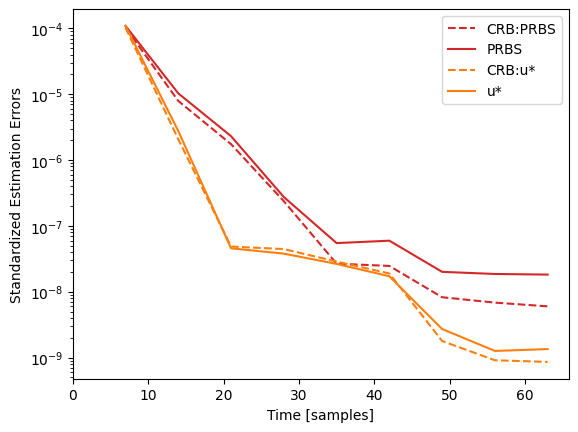

In [625]:
#plt.figure(figsize=(5,4))
#plt.subplot(1,2,1)
theta_norm = (true_theta**2).sum()
plt.yscale('log')
plt.plot(nsS601[0],theta_crbsS601.mean(axis=0),c='C3',label='CRB:PRBS',linestyle='dashed')
plt.plot(nsS601[0],theta_msesS601.mean(axis=0),c='C3',label='PRBS',linestyle='solid')
#plt.fill_between(nsS601[0],np.min(theta_msesS601,axis=0)/theta_norm,np.max(theta_msesS601,axis=0)/theta_norm,color='C3',alpha=0.1)

#plt.plot(nsS601[0],theta_crbsS602[0]/theta_norm,c='C2',label='CRB:ra-PRBS',linestyle='dashed')
#plt.plot(nsS601[0],theta_msesS602[0]/theta_norm,c='C2',label='ra-PRBS',linestyle='solid')


#plt.plot(nsS6002[0],theta_crbsS6002[0],c='C5',label='CRB:u*(eq8)',linestyle='dashed')
#plt.plot(nsS6002[0],theta_msesS6002[0],c='C5',label='u*(eq8)',linestyle='solid')

#plt.plot(nsS601[0],theta_crbsS6000.mean(axis=0),c='C1',label='CRB:u*(old)',linestyle='dashed')
#plt.plot(nsS601[0],theta_msesS6000.mean(axis=0),c='C1',label='u*(old)',linestyle='solid')

plt.plot(nsS601[0],theta_crbsS60020.mean(axis=0),c='C1',label='CRB:u*',linestyle='dashed')
plt.plot(nsS601[0],theta_msesS60020.mean(axis=0),c='C1',label='u*',linestyle='solid')


#plt.plot(nsS6001[0],theta_crbsS60070.mean(axis=0),c='C7',label='CRB:u*(A-optimal)',linestyle='dashed')
#plt.plot(nsS6001[0],theta_msesS60070.mean(axis=0),c='C7',label='u*(A-optimal)',linestyle='solid')


#plt.plot(nsS600[0],theta_crbsS6004.mean(axis=0)/theta_norm,c='C8',label='CRB:u*(part)',linestyle='dashed')
#plt.plot(nsS601[0],theta_msesS6004.mean(axis=0)/theta_norm,c='C8',label='u*(part)',linestyle='solid')


#plt.plot(nsS60060[0],theta_crbsS60060.mean(axis=0),c='C9',label='CRB:u*(diag)',linestyle='dashed')
#plt.plot(nsS60060[0],theta_msesS60060.mean(axis=0),c='C9',label='u*(diag)',linestyle='solid')
#plt.plot(nsS601[0],theta_crbsS604.mean(axis=0)/theta_norm,c='C5',label='$CRB:u*(Constr. 135^\circ - 225^\circ)$',linestyle='dashed')
#plt.plot(nsS601[0],theta_msesS604.mean(axis=0)/theta_norm,c='C5',label='$u*(Constr. 135^\circ - 225^\circ)$',linestyle='solid')



#plt.plot(nsS601[0],theta_crbsS604[0]/theta_norm,c='C5',label='$CRB:u*(Constr. 135^\circ - 225^\circ)$',linestyle='dashed')
#plt.plot(nsS601[0],theta_msesS604[0]/theta_norm,c='C5',label='$u*(Constr. 135^\circ - 225^\circ)$',linestyle='solid')
plt.xticks([i for i in range(0,61,10)])
plt.xlabel('Time [samples]')
plt.ylabel('Standardized Estimation Errors')
plt.legend()
#plt.savefig('plots/invertedpendulum_err3.pdf')


In [ ]:
#plt.figure(figsize=(5,4))
#plt.subplot(1,2,1)
theta_norm = (true_theta**2).sum()
plt.yscale('log')
plt.ylim(1e-9,1e-3)


plt.plot(nsS601[0],theta_crbsS600.mean(axis=0)/theta_norm,c='C1',label='CRB:u*',linestyle='dashed')
plt.plot(nsS601[0],theta_msesS600.mean(axis=0)/theta_norm,c='C1',label='u*',linestyle='solid')

plt.plot(nsS601[0],theta_crbsS604.mean(axis=0)/theta_norm,c='C5',label='$CRB:u*(Constr. 135^\circ - 225^\circ)$',linestyle='dashed')
plt.plot(nsS601[0],theta_msesS604.mean(axis=0)/theta_norm,c='C5',label='$u*(Constr. 135^\circ - 225^\circ)$',linestyle='solid')


#plt.plot(nsS601[0],theta_crbsS605[0]/theta_norm,c='C6',label='$CRB:u*(Constr. 135^\circ - 180^\circ)$',linestyle='dashed')
#plt.plot(nsS601[0],theta_msesS605[0]/theta_norm,c='C6',label='$u*(Constr. 135^\circ - 180^\circ)$',linestyle='solid')


#plt.plot(nsS601[0],theta_crbsS606[0]/theta_norm,c='C7',label='$CRB:u*(Constr. 180^\circ - 225^\circ)$',linestyle='dashed')
#plt.plot(nsS601[0],theta_msesS606[0]/theta_norm,c='C7',label='$u*(Constr. 180^\circ - 225^\circ)$',linestyle='solid')


plt.xlabel('Time [samples]')
plt.ylabel('Estimation Errors/$|\Theta_o|^2$')
plt.legend()
plt.savefig('plots/invertedpendulum_err2.pdf')


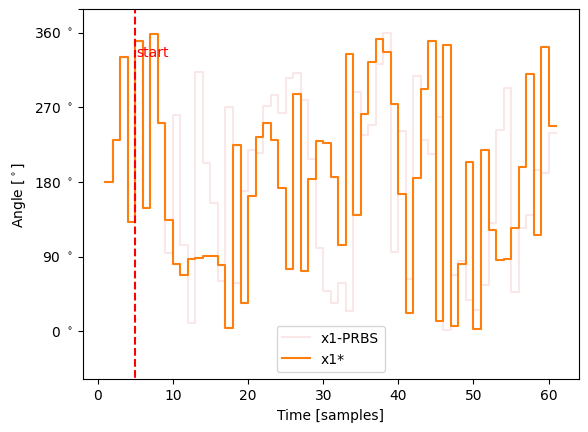

In [827]:
##### ax = plt.gca()
plt.xlabel('Time [samples]')
plt.ylabel('Angle [$^\circ$]')
plt.yticks([-np.pi-2,-np.pi,-np.pi*0.5,0,np.pi*0.5,np.pi,np.pi*1.5,np.pi*2,np.pi*2+0.5],labels=['','$-180 ^\circ$','$-90 ^\circ$','0 $^\circ$','90 $^\circ$','180 $^\circ$','270 $^\circ$','360 $^\circ$',''])
plt.step(range(1,1+T),xsS601[2,0][:T]%(2*np.pi),c='C3',alpha=0.1,label='x1-PRBS')



plt.step(range(1,1+T),xsS600[2,0][:T]%(2*np.pi),c='C1',label='x1*')
plt.plot([5,5],[-np.pi-2,2*np.pi+0.5],linestyle='dashed',c='red')
plt.text(x=5.1,y=2*np.pi-0.5,s='start',c='red')

plt.legend()
plt.ylim(-1,np.pi*2+0.5)
plt.savefig('plots/invertedpendulum_output_prbs_star.pdf')

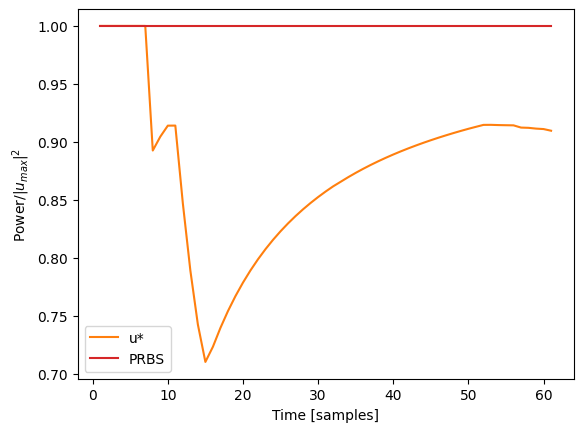

In [416]:
plt.plot(range(1,T+1),np.array([compute_power(usS600[i,:,:T],amplitude) for i in range(10)]).mean(axis=0),c='C1',label='u*')
plt.plot(range(1,T+1),np.array([compute_power(usS601[i,:,:T],amplitude) for i in range(10)]).mean(axis=0),c='C3',label='PRBS')

plt.xlabel('Time [samples]')
plt.ylabel('Power/$|u_{max}|^2$')
plt.legend()
plt.savefig('plots/invertedpendulum_power.pdf')

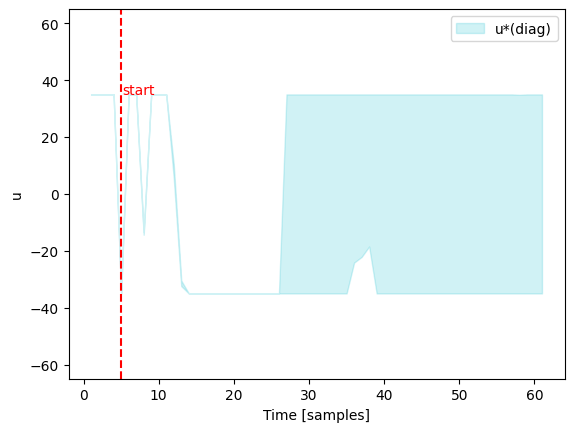

In [528]:
plt.xlabel('Time [samples]')
plt.ylabel('u')
T=61
plt.ylim(-65,65)
#plt.step(range(1,1+T),usS601[0][0,:T],c='C3',alpha=0.1,label='u:PRBS')
#plt.step(range(1,1+T),usS6001[0][0,:T],c='C7',label='u*(A-optimal)')
plt.fill_between(range(1,1+T),usS60060[:,0,:T].min(axis=0),usS60060[:,0,:T].max(axis=0),alpha=0.2,color='C9',label='u*(diag)')
#plt.step(range(1,1+T),usS6002[1][0,:T],c='C8',label='u*(eq8)')
#plt.step(range(1,1+T),usS600[2][0,:T],c='C1',label='u*')
plt.plot([5,5],[-65,65],linestyle='dashed',c='red')
plt.text(x=5.1,y=35,s='start',c='red')
plt.legend()
#plt.savefig('plots/invertedpendulum_u_prbs_star.pdf')

(-1.0, 6.783185307179586)

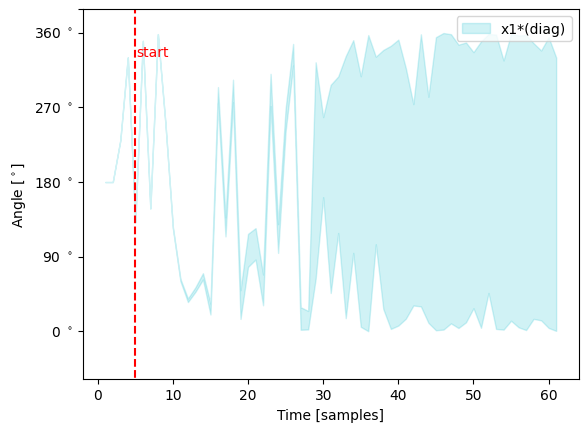

In [561]:
plt.xlabel('Time [samples]')
plt.ylabel('Angle [$^\circ$]')
plt.yticks([-np.pi-2,-np.pi,-np.pi*0.5,0,np.pi*0.5,np.pi,np.pi*1.5,np.pi*2,np.pi*2+0.5],labels=['','$-180 ^\circ$','$-90 ^\circ$','0 $^\circ$','90 $^\circ$','180 $^\circ$','270 $^\circ$','360 $^\circ$',''])
plt.fill_between(range(1,1+T),(xsS60060[:,0,:T]%(2*np.pi)).min(axis=0),(xsS60060[:,0,:T]%(2*np.pi)).max(axis=0),alpha=0.2,color='C9',label='x1*(diag)')
plt.plot([5,5],[-np.pi-2,2*np.pi+0.5],linestyle='dashed',c='red')
plt.text(x=5.1,y=2*np.pi-0.5,s='start',c='red')

plt.legend()
plt.ylim(-1,np.pi*2+0.5)

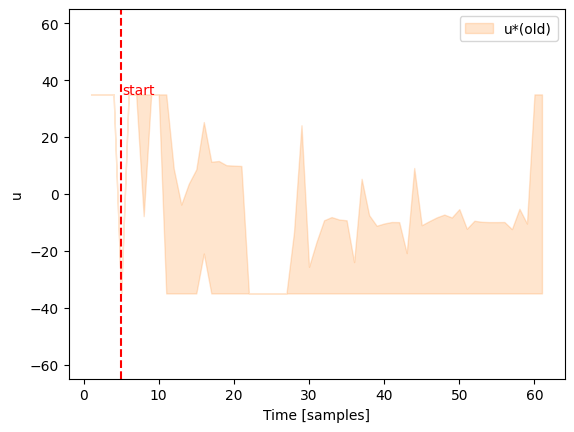

In [526]:
plt.xlabel('Time [samples]')
plt.ylabel('u')
T=61
plt.ylim(-65,65)
#plt.step(range(1,1+T),usS601[0][0,:T],c='C3',alpha=0.1,label='u:PRBS')
#plt.step(range(1,1+T),usS6001[0][0,:T],c='C7',label='u*(A-optimal)')
plt.fill_between(range(1,1+T),usS6000[:,0,:T].min(axis=0),usS6000[:,0,:T].max(axis=0),alpha=0.2,color='C1',label='u*(old)')
#plt.step(range(1,1+T),usS6002[1][0,:T],c='C8',label='u*(eq8)')
#plt.step(range(1,1+T),usS600[2][0,:T],c='C1',label='u*')
plt.plot([5,5],[-65,65],linestyle='dashed',c='red')
plt.text(x=5.1,y=35,s='start',c='red')
plt.legend()
#plt.savefig('plots/invertedpendulum_u_prbs_star.pdf')

(-1.0, 6.783185307179586)

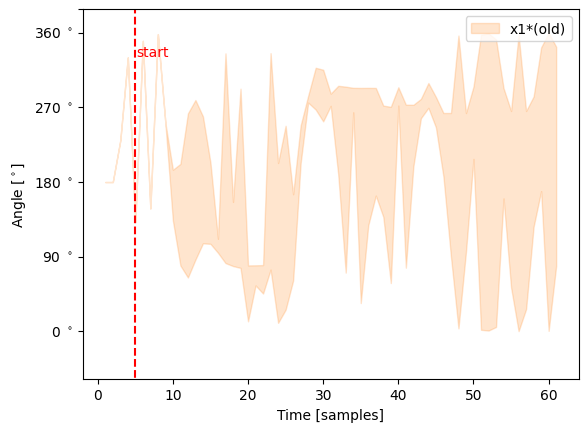

In [560]:
plt.xlabel('Time [samples]')
plt.ylabel('Angle [$^\circ$]')
plt.yticks([-np.pi-2,-np.pi,-np.pi*0.5,0,np.pi*0.5,np.pi,np.pi*1.5,np.pi*2,np.pi*2+0.5],labels=['','$-180 ^\circ$','$-90 ^\circ$','0 $^\circ$','90 $^\circ$','180 $^\circ$','270 $^\circ$','360 $^\circ$',''])
plt.fill_between(range(1,1+T),(xsS6000[:,0,:T]%(2*np.pi)).min(axis=0),(xsS6000[:,0,:T]%(2*np.pi)).max(axis=0),alpha=0.2,color='C1',label='x1*(old)')
plt.plot([5,5],[-np.pi-2,2*np.pi+0.5],linestyle='dashed',c='red')
plt.text(x=5.1,y=2*np.pi-0.5,s='start',c='red')

plt.legend()
plt.ylim(-1,np.pi*2+0.5)

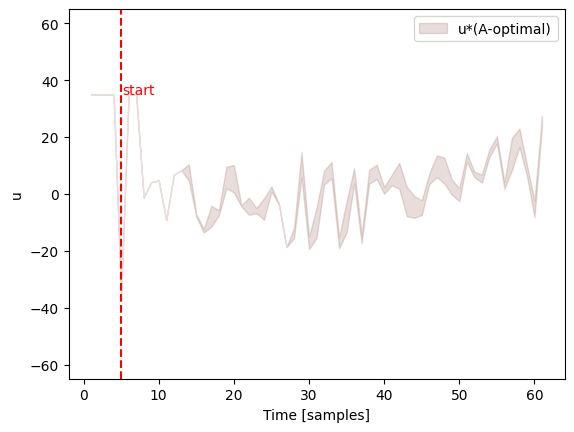

In [ ]:
plt.xlabel('Time [samples]')
plt.ylabel('u')
T=61
plt.ylim(-65,65)
#plt.step(range(1,1+T),usS601[0][0,:T],c='C3',alpha=0.1,label='u:PRBS')
#plt.step(range(1,1+T),usS6001[0][0,:T],c='C7',label='u*(A-optimal)')
plt.fill_between(range(1,1+T),usS60070[:,0,:T].min(axis=0),usS60070[:,0,:T].max(axis=0),alpha=0.2,color='C5',label='u*(A-optimal)')
#plt.step(range(1,1+T),usS6002[1][0,:T],c='C8',label='u*(eq8)')
#plt.step(range(1,1+T),usS600[2][0,:T],c='C1',label='u*')
plt.plot([5,5],[-65,65],linestyle='dashed',c='red')
plt.text(x=5.1,y=35,s='start',c='red')
plt.legend()
#plt.savefig('plots/invertedpendulum_u_prbs_star.pdf')

(-1.0, 6.783185307179586)

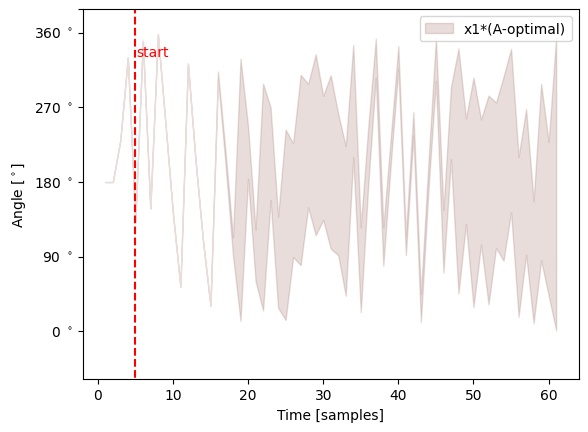

In [602]:
plt.xlabel('Time [samples]')
plt.ylabel('Angle [$^\circ$]')
plt.yticks([-np.pi-2,-np.pi,-np.pi*0.5,0,np.pi*0.5,np.pi,np.pi*1.5,np.pi*2,np.pi*2+0.5],labels=['','$-180 ^\circ$','$-90 ^\circ$','0 $^\circ$','90 $^\circ$','180 $^\circ$','270 $^\circ$','360 $^\circ$',''])
plt.fill_between(range(1,1+T),(xsS60070[:,0,:T]%(2*np.pi)).min(axis=0),(xsS60070[:,0,:T]%(2*np.pi)).max(axis=0),alpha=0.2,color='C5',label='x1*(A-optimal)')
plt.plot([5,5],[-np.pi-2,2*np.pi+0.5],linestyle='dashed',c='red')
plt.text(x=5.1,y=2*np.pi-0.5,s='start',c='red')

plt.legend()
plt.ylim(-1,np.pi*2+0.5)

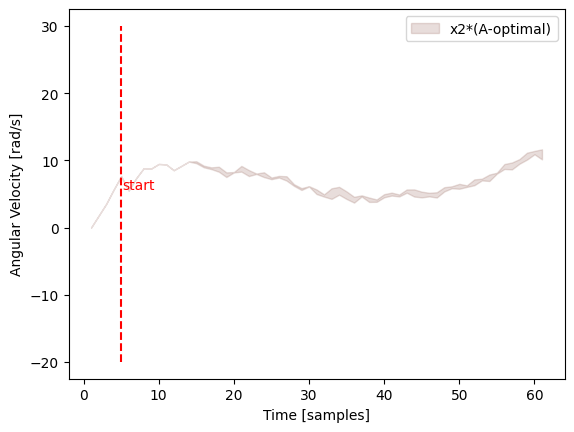

In [599]:
plt.xlabel('Time [samples]')
plt.ylabel('Angular Velocity [rad/s]')
#plt.yticks([-np.pi-2,-np.pi,-np.pi*0.5,0,np.pi*0.5,np.pi,np.pi*1.5,np.pi*2,np.pi*2+0.5],labels=['','$-180 ^\circ$','$-90 ^\circ$','0 $^\circ$','90 $^\circ$','180 $^\circ$','270 $^\circ$','360 $^\circ$',''])
plt.fill_between(range(1,1+T),(xsS60070[:,1,:T]).min(axis=0),(xsS60070[:,1,:T]).max(axis=0),alpha=0.2,color='C5',label='x2*(A-optimal)')
plt.plot([5,5],[-20,30],linestyle='dashed',c='red')
plt.text(x=5.1,y=2*np.pi-0.5,s='start',c='red')

plt.legend()
#plt.ylim(-1,np.pi*2+0.5)

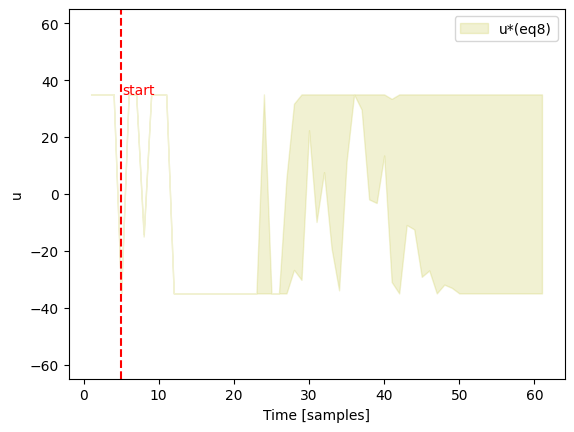

In [527]:
plt.xlabel('Time [samples]')
plt.ylabel('u')
T=61
plt.ylim(-65,65)
#plt.step(range(1,1+T),usS601[0][0,:T],c='C3',alpha=0.1,label='u:PRBS')
#plt.step(range(1,1+T),usS6001[0][0,:T],c='C7',label='u*(A-optimal)')
plt.fill_between(range(1,1+T),usS60020[:,0,:T].min(axis=0),usS60020[:,0,:T].max(axis=0),alpha=0.2,color='C8',label='u*(eq8)')
#plt.step(range(1,1+T),usS6002[1][0,:T],c='C8',label='u*(eq8)')
#plt.step(range(1,1+T),usS600[2][0,:T],c='C1',label='u*')
plt.plot([5,5],[-65,65],linestyle='dashed',c='red')
plt.text(x=5.1,y=35,s='start',c='red')
plt.legend()
#plt.savefig('plots/invertedpendulum_u_prbs_star.pdf')

(-1.0, 6.783185307179586)

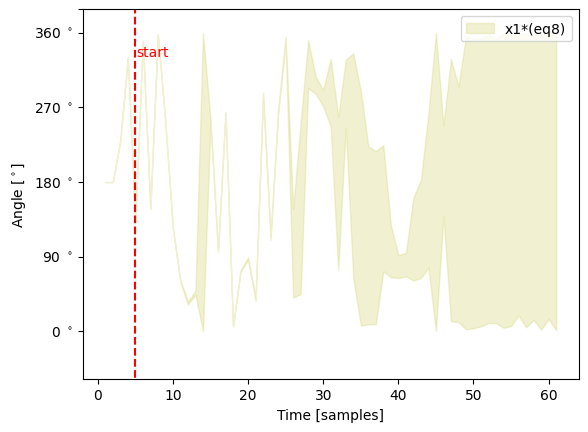

In [559]:
plt.xlabel('Time [samples]')
plt.ylabel('Angle [$^\circ$]')
plt.yticks([-np.pi-2,-np.pi,-np.pi*0.5,0,np.pi*0.5,np.pi,np.pi*1.5,np.pi*2,np.pi*2+0.5],labels=['','$-180 ^\circ$','$-90 ^\circ$','0 $^\circ$','90 $^\circ$','180 $^\circ$','270 $^\circ$','360 $^\circ$',''])
plt.fill_between(range(1,1+T),(xsS60020[:,0,:T]%(2*np.pi)).min(axis=0),(xsS60020[:,0,:T]%(2*np.pi)).max(axis=0),alpha=0.2,color='C8',label='x1*(eq8)')
plt.plot([5,5],[-np.pi-2,2*np.pi+0.5],linestyle='dashed',c='red')
plt.text(x=5.1,y=2*np.pi-0.5,s='start',c='red')

plt.legend()
plt.ylim(-1,np.pi*2+0.5)

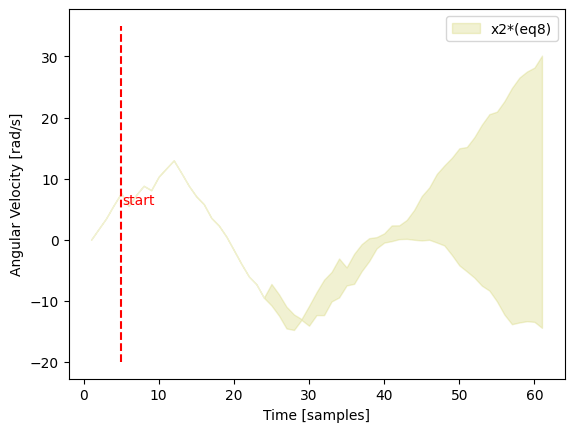

In [594]:
plt.xlabel('Time [samples]')
plt.ylabel('Angular Velocity [rad/s]')
#plt.yticks([-np.pi-2,-np.pi,-np.pi*0.5,0,np.pi*0.5,np.pi,np.pi*1.5,np.pi*2,np.pi*2+0.5],labels=['','$-180 ^\circ$','$-90 ^\circ$','0 $^\circ$','90 $^\circ$','180 $^\circ$','270 $^\circ$','360 $^\circ$',''])
plt.fill_between(range(1,1+T),(xsS60020[:,1,:T]).min(axis=0),(xsS60020[:,1,:T]).max(axis=0),alpha=0.2,color='C8',label='x2*(eq8)')
plt.plot([5,5],[-20,35],linestyle='dashed',c='red')
plt.text(x=5.1,y=2*np.pi-0.5,s='start',c='red')

plt.legend()
#plt.ylim(-1,np.pi*2+0.5)

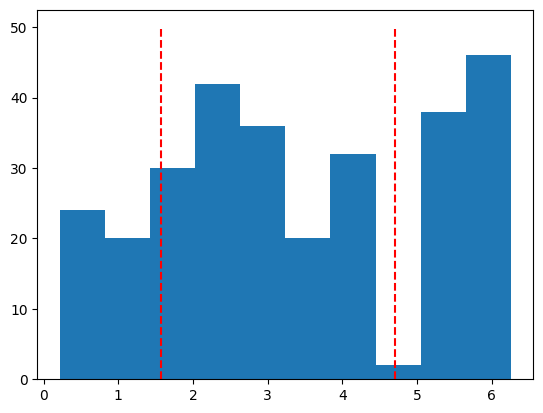

In [588]:
plt.hist(xsS60070[:,0,:29].flatten()%(2*np.pi),bins=10)
plt.plot([0.5*np.pi,0.5*np.pi],[0,50],c='red',linestyle='dashed')
plt.plot([1.5*np.pi,1.5*np.pi],[0,50],c='red',linestyle='dashed')

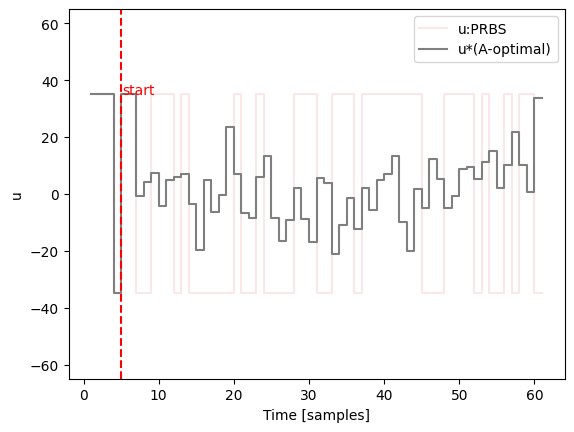

In [753]:
plt.xlabel('Time [samples]')
plt.ylabel('u')
plt.ylim(-65,65)
plt.step(range(1,1+T),usS601[2][0,:T],c='C3',alpha=0.1,label='u:PRBS')
plt.step(range(1,1+T),usS6001[2][0,:T],c='C7',label='u*(A-optimal)')
plt.plot([5,5],[-65,65],linestyle='dashed',c='red')
plt.text(x=5.1,y=35,s='start',c='red')
plt.legend()
plt.savefig('plots/invertedpendulum_u_prbs_star_aopti.pdf')

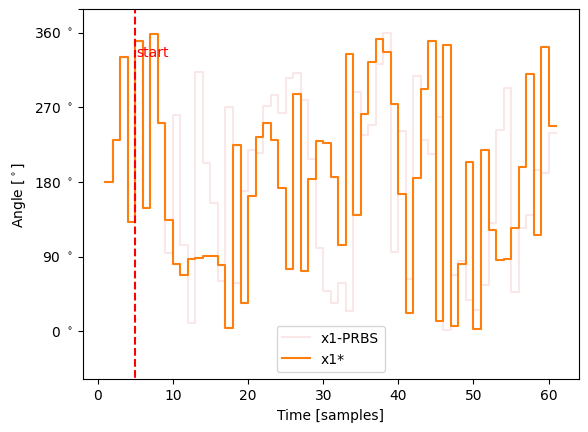

In [831]:
##### ax = plt.gca()
plt.xlabel('Time [samples]')
plt.ylabel('Angle [$^\circ$]')
plt.yticks([-np.pi-2,-np.pi,-np.pi*0.5,0,np.pi*0.5,np.pi,np.pi*1.5,np.pi*2,np.pi*2+0.5],labels=['','$-180 ^\circ$','$-90 ^\circ$','0 $^\circ$','90 $^\circ$','180 $^\circ$','270 $^\circ$','360 $^\circ$',''])
plt.step(range(1,1+T),xsS601[2,0][:T]%(2*np.pi),c='C3',alpha=0.1,label='x1-PRBS')
plt.step(range(1,1+T),xsS600[2,0][:T]%(2*np.pi),c='C1',label='x1*')
plt.plot([5,5],[-np.pi-2,2*np.pi+0.5],linestyle='dashed',c='red')
plt.text(x=5.1,y=2*np.pi-0.5,s='start',c='red')

plt.legend()
plt.ylim(-1,np.pi*2+0.5)
plt.savefig('plots/invertedpendulum_output_prbs_star_x1.pdf')

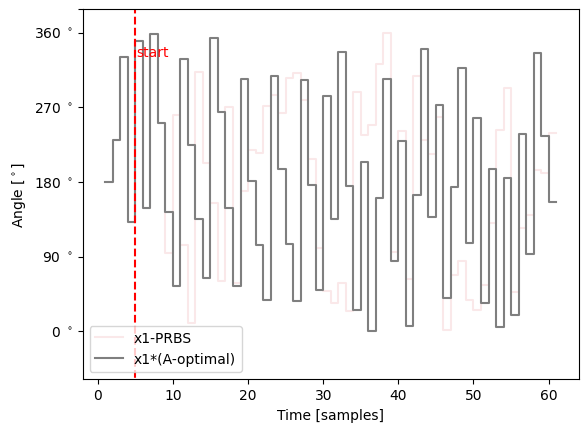

In [833]:
##### ax = plt.gca()
plt.xlabel('Time [samples]')
plt.ylabel('Angle [$^\circ$]')
plt.yticks([-np.pi-2,-np.pi,-np.pi*0.5,0,np.pi*0.5,np.pi,np.pi*1.5,np.pi*2,np.pi*2+0.5],labels=['','$-180 ^\circ$','$-90 ^\circ$','0 $^\circ$','90 $^\circ$','180 $^\circ$','270 $^\circ$','360 $^\circ$',''])
plt.step(range(1,1+T),xsS601[2,0][:T]%(2*np.pi),c='C3',alpha=0.1,label='x1-PRBS')
plt.step(range(1,1+T),xsS6001[2,0][:T]%(2*np.pi),c='C7',label='x1*(A-optimal)')
plt.plot([5,5],[-np.pi-2,2*np.pi+0.5],linestyle='dashed',c='red')
plt.text(x=5.1,y=2*np.pi-0.5,s='start',c='red')

plt.legend()
plt.ylim(-1,np.pi*2+0.5)
plt.savefig('plots/invertedpendulum_output_prbs_star_x1_a.pdf')

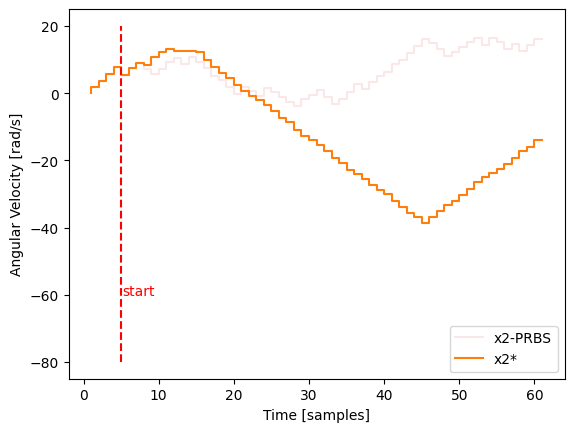

In [832]:
##### ax = plt.gca()
plt.xlabel('Time [samples]')
plt.ylabel('Angular Velocity [rad/s]')
plt.step(range(1,1+T),xsS601[2,1][:T],c='C3',alpha=0.1,label='x2-PRBS')
plt.step(range(1,1+T),xsS600[2,1][:T],c='C1',label='x2*')
plt.plot([5,5],[-80,20],linestyle='dashed',c='red')
plt.text(x=5.1,y=-60,s='start',c='red')

plt.legend()
plt.savefig('plots/invertedpendulum_output_prbs_star_x2.pdf')

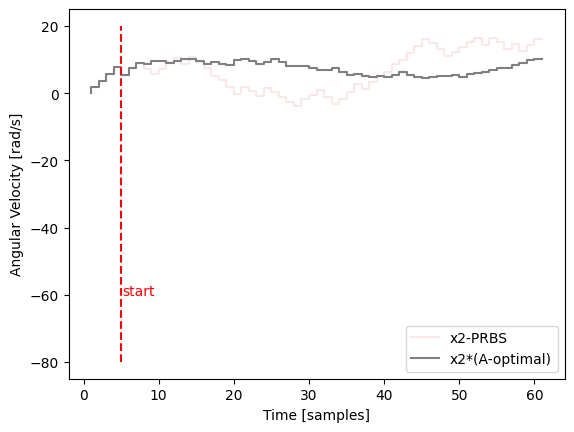

In [834]:
##### ax = plt.gca()
plt.xlabel('Time [samples]')
plt.ylabel('Angular Velocity [rad/s]')
plt.step(range(1,1+T),xsS601[2,1][:T],c='C3',alpha=0.1,label='x2-PRBS')
plt.step(range(1,1+T),xsS6001[2,1][:T],c='C7',label='x2*(A-optimal)')
plt.plot([5,5],[-80,20],linestyle='dashed',c='red')
plt.text(x=5.1,y=-60,s='start',c='red')

plt.legend()
plt.savefig('plots/invertedpendulum_output_prbs_star_x2_a.pdf')

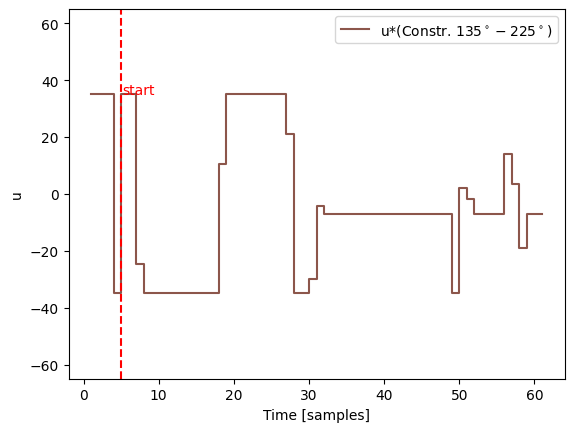

In [592]:
plt.xlabel('Time [samples]')
plt.ylim(-65,65)
plt.ylabel('u')
plt.step(range(1,1+T),usS604[5][0,:T],c='C5',label='u*(Constr. $135^\circ - 225^\circ$)')
plt.plot([5,5],[-65,65],linestyle='dashed',c='red')
plt.text(x=5.1,y=35,s='start',c='red')
plt.legend()

plt.savefig('plots/invertedpendulum_u_135_225.pdf')

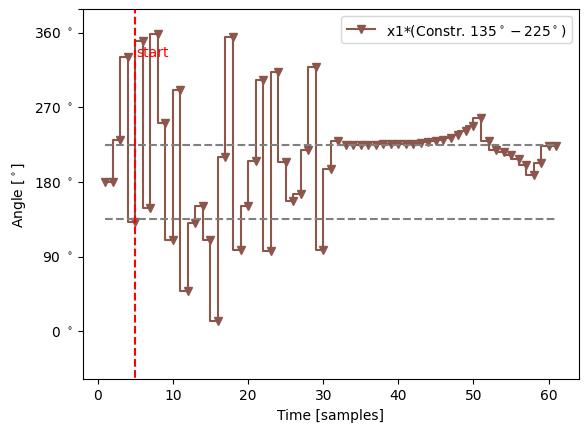

In [591]:
plt.xlabel('Time [samples]')
plt.ylabel('Angle [$^\circ$]')
plt.yticks([-np.pi-2,-np.pi,-np.pi*0.5,0,np.pi*0.5,np.pi,np.pi*1.5,np.pi*2,np.pi*2+0.5],labels=['','$-180 ^\circ$','$-90 ^\circ$','0 $^\circ$','90 $^\circ$','180 $^\circ$','270 $^\circ$','360 $^\circ$',''])
plt.ylim(-1,np.pi*2+0.5)
plt.step(range(1,1+T),xsS604[5,0][:T]%(np.pi*2),c='C5',marker='v',label='x1*(Constr. $135^\circ - 225^\circ$)')
plt.plot([1,T],[np.pi*3/4,np.pi*3/4],linestyle='dashed',c='gray')
plt.plot([1,T],[np.pi*5/4,np.pi*5/4],linestyle='dashed',c='gray')
plt.plot([5,5],[-np.pi-2,2*np.pi+0.5],linestyle='dashed',c='red')
plt.text(x=5.1,y=2*np.pi-0.5,s='start',c='red')
plt.legend()
plt.savefig('plots/invertedpendulum_output_135_225.pdf')

In [3314]:
xsS604[0,0][:T]%(np.pi*2)

array([3.14159265, 3.14159265, 4.14159265, 6.14159265, 3.06877509,
       1.03123753, 4.25869698, 1.98848725, 5.22621767, 2.95225578,
       1.89601114, 1.79271458, 2.4525184 , 3.1910428 , 3.65073962,
       3.85352458, 3.97934726, 4.08638162, 4.1627617 , 4.24987542,
       3.90991096, 3.86906275, 3.88102593, 3.8569073 , 3.82089422,
       3.77261066, 3.77531218, 3.78454194, 3.77291792, 3.73157263,
       3.66442289, 3.56439323, 3.50829133, 3.44935714, 3.32174097,
       3.0980308 , 2.75171623, 2.22771347, 1.5321251 , 0.53800843,
       5.42338897, 3.72594425, 2.05139388, 0.34658463, 4.63639523,
       2.47211984, 0.40887348, 4.30539221, 1.64641403, 5.33138425,
       2.42529197, 5.92171672, 2.81880371, 5.91395734, 2.47211737,
       5.23624302, 1.47402953, 4.10250064, 0.04493874, 2.30060814,
       4.36713161])

In [3315]:
np.pi*3/4

2.356194490192345

In [3316]:
np.pi*5/4

3.9269908169872414

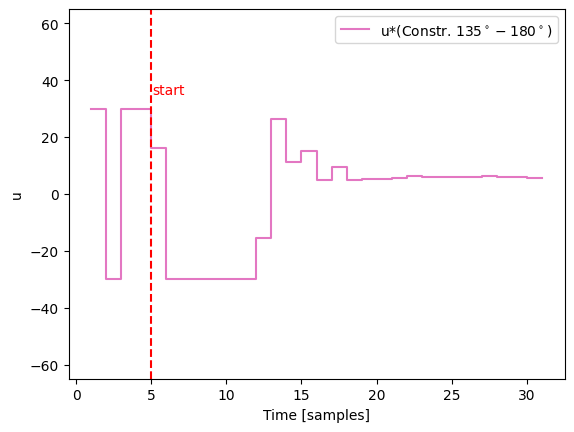

In [1244]:
plt.xlabel('Time [samples]')
plt.ylim(-65,65)
plt.ylabel('u')
plt.step(range(1,1+T),usS605[0][0,:T],c='C6',label='u*(Constr. $135^\circ - 180^\circ$)')
plt.plot([5,5],[-65,65],linestyle='dashed',c='red')
plt.text(x=5.1,y=35,s='start',c='red')
plt.legend()
plt.savefig('plots/invertedpendulum_u_135_180.pdf')

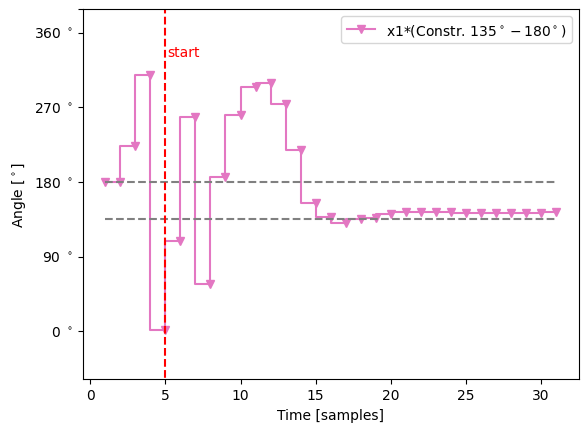

In [1248]:
plt.xlabel('Time [samples]')
plt.ylabel('Angle [$^\circ$]')
plt.yticks([-np.pi-2,-np.pi,-np.pi*0.5,0,np.pi*0.5,np.pi,np.pi*1.5,np.pi*2,np.pi*2+0.5],labels=['','$-180 ^\circ$','$-90 ^\circ$','0 $^\circ$','90 $^\circ$','180 $^\circ$','270 $^\circ$','360 $^\circ$',''])
plt.ylim(-1,np.pi*2+0.5)
plt.step(range(1,1+T),xsS605[0,0][:T]%(np.pi*2),c='C6',marker='v',label='x1*(Constr. $135^\circ - 180^\circ$)')
plt.plot([1,T],[np.pi,np.pi],linestyle='dashed',c='gray')
plt.plot([1,T],[np.pi*3/4,np.pi*3/4],linestyle='dashed',c='gray')
plt.plot([5,5],[-np.pi-2,2*np.pi+0.5],linestyle='dashed',c='red')
plt.text(x=5.1,y=2*np.pi-0.5,s='start',c='red')
plt.legend()
plt.savefig('plots/invertedpendulum_output_135_180.pdf')

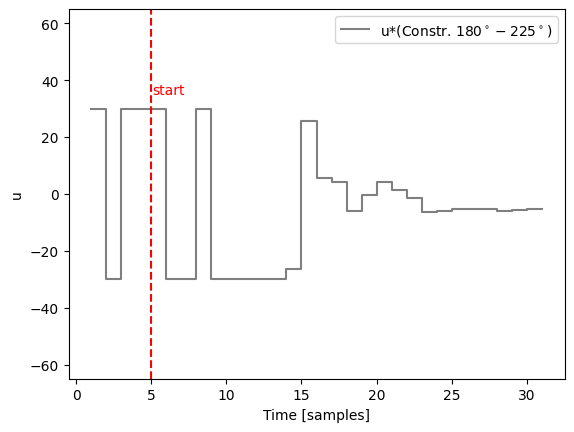

In [1246]:
plt.xlabel('Time [samples]')
plt.ylim(-65,65)
plt.ylabel('u')
plt.step(range(1,1+T),usS606[0][0,:T],c='C7',label='u*(Constr. $180^\circ - 225^\circ$)')
plt.plot([5,5],[-65,65],linestyle='dashed',c='red')
plt.text(x=5.1,y=35,s='start',c='red')
plt.legend()
plt.savefig('plots/invertedpendulum_u_180_225.pdf')

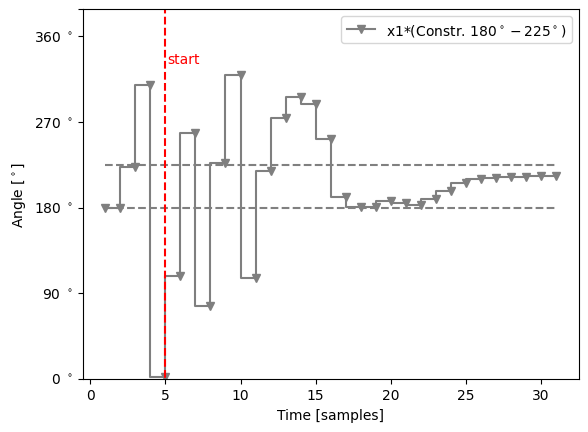

In [1247]:
plt.xlabel('Time [samples]')
plt.ylabel('Angle [$^\circ$]')
plt.yticks([-np.pi-2,-np.pi,-np.pi*0.5,0,np.pi*0.5,np.pi,np.pi*1.5,np.pi*2,np.pi*2+0.5],labels=['','$-180 ^\circ$','$-90 ^\circ$','0 $^\circ$','90 $^\circ$','180 $^\circ$','270 $^\circ$','360 $^\circ$',''])
plt.ylim(0,np.pi*2+0.5)
plt.step(range(1,1+T),xsS606[0,0][:T]%(np.pi*2),marker='v',c='C7',label='x1*(Constr. $180^\circ - 225^\circ$)')
plt.plot([1,T],[np.pi,np.pi],linestyle='dashed',c='gray')
plt.plot([1,T],[np.pi*5/4,np.pi*5/4],linestyle='dashed',c='gray')
plt.plot([5,5],[-np.pi-2,2*np.pi+0.5],linestyle='dashed',c='red')
plt.text(x=5.1,y=2*np.pi-0.5,s='start',c='red')
plt.legend()
plt.savefig('plots/invertedpendulum_output_180_225.pdf')

In [7755]:
xsS606[0,0][:20]

array([3.14159265, 3.14159265, 2.40845149, 1.70044475, 1.86131129,
       1.78014531, 2.1454721 , 3.10786481, 3.55261174, 3.47561837,
       3.03044773, 2.93016565, 3.1312134 , 3.60400862, 3.54878766,
       3.26093229, 3.07669438, 3.13034682, 3.45023443, 3.61280187])

In [7756]:
xsS606[0,1][:20]

array([ 0.        , -1.46628234, -1.41601347,  0.32173307, -0.16233194,
        0.73065357,  1.92478543,  0.88949386, -0.15398674, -0.89034128,
       -0.20056416,  0.4020955 ,  0.94559045, -0.11044193, -0.57571073,
       -0.36847583,  0.10730488,  0.63977523,  0.32513488,  0.09901828])

In [70]:
M1 = np.random.randn(4,4)
M1 = M1.T@M1
M2 = np.random.randn(4,4)
M2 = M2.T@M2

In [71]:
M1 = np.random.randn(4,4)
M1 = M1.T@M1
M2 = np.diag([1,2,3,4])

In [91]:
torch

array([[ 1.75930796,  1.2438036 ,  0.65994764,  1.07753704],
       [ 1.2438036 ,  3.78075616, -1.16382111,  0.57705291],
       [ 0.65994764, -1.16382111,  2.12357328, -0.00752527],
       [ 1.07753704,  0.57705291, -0.00752527,  0.95343364]])

In [72]:
C = M1
J = np.linalg.inv(C)
J_kt = J+M2

In [73]:
np.trace(np.linalg.inv(C@J_kt)[:2,:2])

0.9491882442397226

In [74]:
np.trace(np.linalg.inv(C)[:2,:2]@np.linalg.inv(J_kt)[:2,:2])+np.trace(np.linalg.inv(C)[:2,2:]@np.linalg.inv(J_kt)[2:,:2])

0.949188244239707

In [75]:
np.trace(np.linalg.inv(C[:2,:2])@np.linalg.inv(J_kt)[:2,:2])

0.25553167156042206

In [76]:
np.trace(J[:2,:2]@np.linalg.inv(J_kt)[:2,:2]) - \
np.trace(J[:2,2:]@np.linalg.inv(J[2:,2:])@J[2:,:2]@np.linalg.inv(J_kt)[:2,:2])
                                                                                               
                                                                                               
                                                                                               

0.255531671560874

In [77]:
e = np.array([[1,0,0,0],[0,1,0,0]])

np.trace(e@(C@J_kt)@e.T)

11.320820276590778

In [78]:
e2 = e.T@e
np.trace(J_kt@e2@C)

11.32082027659078